# Exploratory Analysis: **Geospatial Assessment of Surface Water Quality in Bogotá (2019–2025) Using Satellite Data and In-Situ Monitoring**


---



## Abstract

This project assesses the spatio-temporal evolution of surface water quality in Bogotá from 2019 to 2025 by integrating official in-situ monitoring from the Bogotá Water Quality Network (RCHB/OAB) with Sentinel-2 satellite observations. We focus on optically active parameters—particularly Total Suspended Solids (TSS/SST)—to build satellite–field matchups under irregular sampling, generate time-regular satellite composites, and map patterns across rivers, wetlands, and key urban basins (e.g., Bogotá and Tunjuelo). The workflow combines geospatial preprocessing, exploratory analysis, hotspot detection, and trend assessment, and evaluates how land-use pressures (urban, industrial, agricultural) relate to water-quality degradation. The project supports SDG 6 and SDG 11 by providing spatially explicit evidence to prioritize restoration, monitoring, and policy actions for urban water management in Bogotá.



## Keywords


Water Quality; Total Suspended Solids (TSS); Sentinel-2; Bogotá; geospatial data science




## SDG Goals

Indicate which [SDG goals](https://sdgs.un.org/goals) are related to the data science project.

<small>
- SDG 6: Clean Water and Sanitation (targets on improving water quality, reducing pollution, and strengthening monitoring).
</small><br>
<small>
- SDG 11: Sustainable Cities and Communities (urban environmental quality and resilience)
</small><br>
<small>
- SDG 3: Good Health and Well-being (secondary, through exposure reduction and environmental health co-benefits)
</small><br>

## Study area and temporal extent

**Study area:** Bogotá, focusing on major surface water systems within and near the urban area: the Bogotá River, the Tunjuelo River, and selected urban wetlands and connected channels.

**Temporal extent:** 2019–2025 for the satellite record (Sentinel-2), with official in-situ measurements from the RCHB/OAB network available for overlapping years (commonly 2019–2025 depending on station activity).


---
## **1.INTRODUCTION**
---

Urban surface waters provide essential ecosystem services, yet they are highly vulnerable to pollution from wastewater, stormwater runoff, and land-use intensification. In Bogotá, river corridors and wetlands are exposed to strong anthropogenic pressures linked to rapid urban expansion, industrial activity, and variable wastewater management. Improving monitoring and understanding the drivers of water-quality degradation directly supports SDG 6 (Clean Water and Sanitation), which calls for reducing pollution and improving water quality, and SDG 11 (Sustainable Cities and Communities), which promotes healthier and more resilient urban environments.

A key challenge is that field measurements from monitoring networks are often temporally irregular and spatially sparse, limiting the ability to characterize continuous dynamics across the city. Remote sensing, particularly Sentinel-2, provides frequent and spatially continuous observations that can complement field data for optically active parameters such as Total Suspended Solids (TSS/SST). This project integrates RCHB/OAB in-situ records with Sentinel-2 composites to produce a consistent spatio-temporal assessment of water quality and to relate observed patterns to land-use pressures.

**Exploratory questions:**

- How have TSS/SST-related indicators evolved spatially and temporally across Bogotá’s rivers and wetlands between 2019 and 2025?

- To what extent are degradation patterns associated with surrounding land-use pressures (urban, industrial, agricultural) at multiple spatial scales (buffers/basins)?

**Target users/stakeholders:** Secretaría Distrital de Ambiente, Observatorio Ambiental de Bogotá, watershed managers and restoration programs, urban planners, and public-health stakeholders who require spatially explicit evidence to prioritize interventions and evaluate policy effectiveness.

---
## **2. RESOURCES**
---





In [197]:
!pip install contextily

In [198]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import folium
import ee
import geemap
import geemap.colormaps as cm
import plotly
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import contextily as cx
from scipy.stats import theilslopes
import matplotlib as mpl


# other imports
from IPython.display import Markdown as md # to generate markdown on the fly

In [199]:
# check library's version
#!pip show numpy
#!pip show pandas
#!pip show geopandas
#!pip install contextily
summary_np = !pip show numpy | grep Summary
summary_pd = !pip show pandas | grep Summary
summary_gpd = !pip show geopandas | grep Summary
summary_sns = !pip show seaborn | grep Summary
summary_folium = !pip show folium | grep Summary
summary_ee = !pip show ee | grep Summary
summary_geemap = !pip show geemap | grep Summary
summary_plotly = !pip show plotly | grep Summary
summary_matplotlib = !pip show matplotlib | grep Summary
summary_sklearn = !pip show scikit-learn | grep Summary
summary_contextily = !pip show contextily | grep Summary



### Python libraries imported

List of python libraries, version, and its purpose for the analysis.





In [200]:
md(f'''
- Numpy version **{np.__version__}**. *{summary_np[0]}*.
- Pandas version **{pd.__version__}**. *{summary_pd[0]}*.
- Geopandas version **{gpd.__version__}**. *{summary_gpd[0]}*.
- Seaborn version **{sns.__version__}**. *{summary_sns[0]}*.
- Folium version **{folium.__version__}**. *{summary_folium[0]}*.
- plotly version **{plotly.__version__}**. *{summary_plotly[0]}*.
- matplotlib version **{matplotlib.__version__}**. *{summary_matplotlib[0]}*.
- sklearn version **{sklearn.__version__}**. *{summary_sklearn[0]}*.
- geemap version **{geemap.__version__}**. *{summary_geemap[0]}*.
- ee version **{ee.__version__}**. *{summary_ee[0]}*.
''')


- Numpy version **2.1.3**. *Summary: Fundamental package for array computing in Python*.
- Pandas version **2.2.3**. *Summary: Powerful data structures for data analysis, time series, and statistics*.
- Geopandas version **1.1.4**. *Summary: Geographic pandas extensions*.
- Seaborn version **0.13.2**. *Summary: Statistical data visualization*.
- Folium version **0.20.0**. *Summary: Make beautiful maps with Leaflet.js & Python*.
- plotly version **5.24.1**. *Summary: An open-source, interactive data visualization library for Python*.
- matplotlib version **3.10.0**. *Summary: Python plotting package*.
- sklearn version **1.6.1**. *[33mWARNING: Package(s) not found: sklearn[0m[33m*.
- geemap version **0.38.4**. *Summary: A Python package for interactive mapping using Google Earth Engine and ipyleaflet*.
- ee version **1.7.39**. *[33mWARNING: Package(s) not found: ee[0m[33m*.


### Data selected


| Dataset                                      | Format                               | Source                                                 | Short description                                                                                                                                                        |  |
| -------------------------------------------- | ------------------------------------ | ------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------ |
| **RCHB – Water Quality Monitoring (Bogotá)** | XLSX                         | Observatorio Ambiental de Bogotá | In-situ water quality measurements at monitoring stations.|
| **CLC 2022 – Land Cover**                    | Shapefile              | IDEAM Geoportal | Land cover classification (2022) |
| **Sentinel-2 Surface Reflectance (L2A)**     | GEE ImageCollection | Google Earth Engine    | Multispectral satellite imagery                                             |
| **Study Area Boundary (Bogotá)**             |Shapefile                  | Local administrative data | Polygon defining the spatial extent |
| **Water Bodies (Bogotá)**             |Shapefile                  | Local administrative data | Polygons bodies of water in the city of Bogotá with a buffer of 200 m.|



[1]: https://experience.arcgis.com/experience/568ddab184334f6b81a04d2fe9aac262/page/Centro-Descarga-Geoportal?utm_source=chatgpt.com "Centro Descarga Geoportal | Sistema de Información ..."
[2]: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED?utm_source=chatgpt.com "Harmonized Sentinel-2 MSI: MultiSpectral Instrument, ..."




Get the data from the GitHub repository (folder `data/`)

In [ ]:
import os
REPO_DIR = "/content/Bogota-Water-Quality"
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/FrenklinV/Bogota-Water-Quality.git {REPO_DIR}

In [ ]:
import os
os.chdir(REPO_DIR)
dir = os.path.abspath("data")          # input data (xlsx + shapefiles)
output_path = os.path.abspath("output") # generated files
os.makedirs(output_path, exist_ok=True)
os.listdir(dir)

---
## **3. DATA PREPARATION & EXPLORATION**
---

Data operations to prepare selected input data set for the subsequent analysis. Examples of data preprocessing tasks include reading data files, cleaning data frames, subsetting, sorting, creating new columns, handling missing values, grouping and aggregation, merging, spatial operations, exploratory plots, and saving intermediate results into local files.

Organise this section into subsections if necessary.

### Reading Data Observations-Stations

In [203]:
#Inspect available sheets
excel_path = dir+"/RCHB-Tradicional_Consolidado3.xlsx"
xls = pd.ExcelFile(excel_path)
xls.sheet_names

['CONSOLIDADO', 'PARAMETROS', 'ESTACIONID']

In [204]:
#Read Each dataset
df_values = pd.read_excel(
    excel_path,
    sheet_name="CONSOLIDADO"
)
df_stations = pd.read_excel(
    excel_path,
    sheet_name="ESTACIONID"
)
df_params = pd.read_excel(
    excel_path,
    sheet_name="PARAMETROS"
)

In [205]:
#DATA PARAMETROS EXPLANATION
print(df_params.shape)
print(df_params.info())
df_params.head()

(36, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Determinante  36 non-null     object
 1   Abreviatura   36 non-null     object
 2   Unidades      36 non-null     object
dtypes: object(3)
memory usage: 996.0+ bytes
None


,Determinante,Abreviatura,Unidades
0,Base,B,[m]
1,Altura,Hmáx,[m]
2,Caudal,Caudal,[L.s-1]
3,pH,pH,Unidades
4,Temperatura,T,[°C]


In [206]:
#DATA MEASURES STATIONS
print(df_values.shape)
print(df_values.info())
df_values.head()

(5395, 72)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5395 entries, 0 to 5394
Data columns (total 72 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   CODIGO                             4880 non-null   object        
 1   ESTACIONID                         5395 non-null   object        
 2   RIOID                              5395 non-null   object        
 3   CAMPANAID                          3000 non-null   object        
 4   FECHA                              5395 non-null   datetime64[ns]
 5   TIPO                               5395 non-null   object        
 6   OBSERVACIONES                      3803 non-null   object        
 7   HORA_INICIAL                       5395 non-null   object        
 8   HORA_FINAL                         5380 non-null   object        
 9   Base                               2891 non-null   object        
 10  Altura                   

,CODIGO,ESTACIONID,RIOID,CAMPANAID,FECHA,TIPO,OBSERVACIONES,HORA_INICIAL,HORA_FINAL,Base,...,Mercurio [Hg],Níquel [Ni],Nitrógeno Amoniacal [NH4+],Nitrógeno Total Kjeldahl [NTK],Plomo [Pb],Sulfuros Totales [S-2],Coliformes Fecales,Nitratos,Nitritos,Nitrógeno Total
0,NaN,SA-Arzobis,SA-T2,Históricos,2006-07-25,2,NUBLADO,11:00:00,13:00:00,NaN,...,0.00025,0.001,3.3,5.66,0.0201,0.1,3100,NaN,NaN,5.66
1,NaN,FU-Delirio,FU-T1,Históricos,2006-07-26,2,SECO,10:00:00,12:00:00,NaN,...,0.00025,0.004,0.3,0.30,0.0220,0.1,4.1,NaN,NaN,0.30
2,NaN,FU-KR7,FU-T2,Históricos,2006-07-26,2,SECO,14:00:00,16:00:00,NaN,...,0.00025,0.006,0.9,1.40,0.0260,0.1,25000,NaN,NaN,1.40
3,NaN,TO-Cedro,TO-T1,Históricos,2006-07-27,2,LLUVIA,14:00:00,16:00:00,NaN,...,0.00025,0.009,3.8,4.00,0.0280,0.1,4000,NaN,NaN,4.00
4,NaN,TO-MakroN,TO-T2,Históricos,2006-07-27,2,NUBLADO,10:00:00,12:00:00,NaN,...,0.00025,0.008,34.7,70.70,0.0230,0.1,5500000,NaN,NaN,70.70


In [207]:
#DATA STATIONS
print(df_stations.shape)
print(df_stations.info())
df_stations.head()

(30, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ESTACIONID         30 non-null     object 
 1   Estación           30 non-null     object 
 2   Río                30 non-null     object 
 3   Tramo              28 non-null     float64
 4   RIOID              30 non-null     object 
 5   Abscisado          30 non-null     float64
 6   Fotografia         30 non-null     object 
 7   Fotografia 2       30 non-null     object 
 8   Pais               30 non-null     object 
 9   Latitud            30 non-null     float64
 10  Longitud           30 non-null     float64
 11  Latitud, Longitud  30 non-null     object 
dtypes: float64(4), object(8)
memory usage: 2.9+ KB
None


,ESTACIONID,Estación,Río,Tramo,RIOID,Abscisado,Fotografia,Fotografia 2,Pais,Latitud,Longitud,"Latitud, Longitud"
0,BO-Cierre,Cierre,Bogotá,NaN,Río Bogotá,77.400,https://drive.google.com/uc?export=view&id=1vL...,https://drive.google.com/uc?export=view&id=16o...,Colombia,4.632012,-74.229653,"4,632012, -74,229653"
1,BO-PComun,Puente Común,Bogotá,NaN,Río Bogotá,0.000,https://drive.google.com/uc?export=view&id=1tp...,https://drive.google.com/uc?export=view&id=1Xk...,Colombia,4.861869,-74.030414,"4,861869, -74,030414"
2,FU-Alameda,Fucha con Alameda,Fucha,4.0,FU-T4,17.933,https://drive.google.com/uc?export=view&id=1Cm...,https://drive.google.com/uc?export=view&id=1Nw...,Colombia,4.662606,-74.152148,"4,662606, -74,152148"
3,FU-Americas,Fucha Avenida Las Américas,Fucha,3.0,FU-T3,12.304,https://drive.google.com/uc?export=view&id=197...,https://drive.google.com/uc?export=view&id=1wu...,Colombia,4.630054,-74.125983,"4,630054, -74,125983"
4,FU-Boyaca,Fucha Avenida Boyacá,Fucha,3.0,FU-T3,14.435,https://drive.google.com/uc?export=view&id=1Fo...,https://drive.google.com/uc?export=view&id=1_D...,Colombia,4.643252,-74.124876,"4,643252, -74,124876"


In [208]:
df_values.columns

Index(['CODIGO', 'ESTACIONID', 'RIOID', 'CAMPANAID', 'FECHA', 'TIPO',
       'OBSERVACIONES', 'HORA_INICIAL', 'HORA_FINAL', 'Base', 'Altura',
       'Caudal_1', 'Caudal_2', 'Caudal_3', 'Caudal_4', 'Caudal_5',
       'Caudal_Prom', 'pH_1', 'pH_2', 'pH_3', 'pH_4', 'pH_5', 'pH_Prom',
       'Temp_1', 'Temp_2', 'Temp_3', 'Temp_4', 'Temp_5', 'Temp_Prom', 'Cond_1',
       'Cond_2', 'Cond_3', 'Cond_4', 'Cond_5', 'Cond_Prom', 'OD_1', 'OD_2',
       'OD_3', 'OD_4', 'OD_5', 'OD_Prom', 'Oxígeno Disuelto [OD Winkler]',
       'Sólidos Sedimentables', 'Alcalinidad', 'Dureza Total', 'DBO5 Total',
       'DQO Total', 'Sólidos Suspendidos Totales [SST]', 'Grasas y Aceites',
       'SAAM', 'Coliformes Totales', 'E-Coli ', 'Arsénico [As]', 'Bario [Ba]',
       'Cadmio [Cd]', 'Cianuro [CN-]', 'Zinc [Zn]', 'Cobre [Cu]',
       'Fenoles Totales [Fenol]', 'Fósforo Total [P]', 'Cromo Total [Cr]',
       'Manganeso [Mn]', 'Mercurio [Hg]', 'Níquel [Ni]',
       'Nitrógeno Amoniacal [NH4+]', 'Nitrógeno Total Kj

### **TASK: PREPARATION OF DATASET CONSOLIDADO (MEASURE STATIONS)**
- Standardize column names
- Parse dates and numeric values (Dates-generate column Month, Convert measurement values to numeric
- Remove NULLS, OUTLIERS
- COLUMNS TO USE ['CODIGO', 'ESTACIONID', 'RIOID', 'FECHA', 'HORA_INICIAL', 'HORA_FINAL', 'Altura', 'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_Prom', 'DQO Total', 'Sólidos Suspendidos Totales [SST]', 'Fósforo Total [P]', 'Nitrógeno Total']
-Join values with stations
- Create GeoDataFrame for stations-values
- Reproject to projected CRS (3116)
- Visualize Stations Points
- Save processed outputs (TABLE MEASURES CLEAN, SHP STATIONS-MEASURES)

### Preparation Data In-Situ and Stations



In [209]:
# Standardize column names (to uppercase, and replace spaces with underscores) at the very beginning
df_values.columns = df_values.columns.str.upper().str.replace(' ', '_')

In [210]:
# Parse the 'FECHA' column as datetime and create 'Month' column
df_values['FECHA'] = pd.to_datetime(df_values['FECHA'])
df_values['MONTH'] = df_values['FECHA'].dt.month

In [211]:
#numeric convertion
numeric_columns = ['ALTURA', 'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM',
    'OD_PROM', 'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]',
    'FÓSFORO_TOTAL_[P]', 'NITRÓGENO_TOTAL' ]
df_values[numeric_columns] = df_values[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [212]:
# Filter the data to only include rows from 2019-01-01 to 2025-12-31
df_values_filtered = df_values[(df_values['FECHA'] >= '2019-01-01') &
                               (df_values['FECHA'] <= '2025-12-31')]


df_values_filtered.head()


,CODIGO,ESTACIONID,RIOID,CAMPANAID,FECHA,TIPO,OBSERVACIONES,HORA_INICIAL,HORA_FINAL,BASE,...,NÍQUEL_[NI],NITRÓGENO_AMONIACAL_[NH4+],NITRÓGENO_TOTAL_KJELDAHL_[NTK],PLOMO_[PB],SULFUROS_TOTALES_[S-2],COLIFORMES_FECALES,NITRATOS,NITRITOS,NITRÓGENO_TOTAL,MONTH
3237,1902WI02,TU-Regader,TU-T1,I,2019-02-19,1,SOLEADO,12:00:00,14:00:00,0.1,...,NaN,NaN,0.5,NaN,NaN,141,0.17,0.007,0.677,2
3238,1902WI03,TU-UAN,TU-T1,I,2019-02-19,1,NUBLADO,16:00:00,18:00:00,4,...,NaN,NaN,2.0,NaN,NaN,195,1.50,0.119,3.619,2
3239,2102HA02,SA-Carrefo,SA-T3,I,2019-02-21,1,NUBLADO,12:00:00,14:00:00,7.05,...,NaN,NaN,51.6,NaN,NaN,93300,2.50,0.010,54.110,2
3240,2102HA01,SA-CL53,SA-T2,I,2019-02-21,1,NUBLADO,08:00:00,10:00:00,1.3,...,NaN,NaN,2.9,NaN,NaN,132,1.13,0.166,4.196,2
3241,2202WI01,FU-Delirio,FU-T1,I,2019-02-22,1,NUBLADO,06:00:00,08:00:00,3.7,...,NaN,NaN,0.7,NaN,NaN,1,0.17,0.007,0.877,2


In [213]:
# Define what columns to keep and process

all_desired_columns = [
    'CODIGO', 'ESTACIONID', 'RIOID', 'FECHA', 'HORA_INICIAL', 'HORA_FINAL',
    'ALTURA', 'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM',
    'OD_PROM', 'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]',
    'FÓSFORO_TOTAL_[P]', 'NITRÓGENO_TOTAL', 'MONTH'
]

# Filter the dataframe to use only the necessary columns
df_values_filtered = df_values_filtered[all_desired_columns]

# Check the result
df_values_filtered.head()

,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,COND_PROM,OD_PROM,DQO_TOTAL,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],FÓSFORO_TOTAL_[P],NITRÓGENO_TOTAL,MONTH
3237,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,33.44,7.036,10.8,4.0,0.060,0.677,2
3238,1902WI03,TU-UAN,TU-T1,2019-02-19,16:00:00,18:00:00,0.520,100.92,7.080,18.66,117.00,6.112,26.7,4.0,0.203,3.619,2
3239,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,739.00,0.444,418.0,180.0,6.451,54.110,2
3240,2102HA01,SA-CL53,SA-T2,2019-02-21,08:00:00,10:00:00,0.078,17.90,8.022,15.58,151.40,7.782,26.2,9.0,0.414,4.196,2
3241,2202WI01,FU-Delirio,FU-T1,2019-02-22,06:00:00,08:00:00,0.390,64.80,7.132,10.86,66.62,7.686,10.0,4.0,0.060,0.877,2


In [214]:
# Clean join keys
df_values_filtered["ESTACIONID"] = df_values_filtered["ESTACIONID"].astype(str).str.strip()
df_stations["ESTACIONID"] = df_stations["ESTACIONID"].astype(str).str.strip()

# Keep only needed station columns
df_stations_small = df_stations[["ESTACIONID", "Latitud", "Longitud"]].drop_duplicates(subset=["ESTACIONID"])
df_stations_small
# Join
df_joined = df_values_filtered.merge(df_stations_small, on="ESTACIONID", how="left")
df_joined

,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,COND_PROM,OD_PROM,DQO_TOTAL,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],FÓSFORO_TOTAL_[P],NITRÓGENO_TOTAL,MONTH,Latitud,Longitud
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,33.44,7.036,10.8,4.0,0.060,0.677,2,4.401330,-74.142153
1,1902WI03,TU-UAN,TU-T1,2019-02-19,16:00:00,18:00:00,0.520,100.92,7.080,18.66,117.00,6.112,26.7,4.0,0.203,3.619,2,4.491791,-74.122038
2,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,739.00,0.444,418.0,180.0,6.451,54.110,2,4.684657,-74.075427
3,2102HA01,SA-CL53,SA-T2,2019-02-21,08:00:00,10:00:00,0.078,17.90,8.022,15.58,151.40,7.782,26.2,9.0,0.414,4.196,2,4.638753,-74.077998
4,2202WI01,FU-Delirio,FU-T1,2019-02-22,06:00:00,08:00:00,0.390,64.80,7.132,10.86,66.62,7.686,10.0,4.0,0.060,0.877,2,4.555917,-74.060277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2153,041125SA01,SA-Carrefo,SA-T3,2025-11-04,10:00:00,12:00:00,0.900,886.00,8.272,20.78,672.40,0.592,311.0,139.0,0.656,53.515,11,4.684657,-74.075427
2154,041125MC03,TU-Regader,TU-T1,2025-11-04,16:00:00,18:00:00,NaN,494.00,7.996,13.92,30.20,6.668,30.1,5.0,0.060,17.807,11,4.401330,-74.142153
2155,051125AP01,FU-Alameda,FU-T4,2025-11-05,08:00:00,10:00:00,NaN,4318.00,7.380,17.66,898.00,0.636,654.0,94.0,2.970,13.107,11,4.662606,-74.152148
2156,051125AP02,FU-VisionC,FU-T4,2025-11-05,12:00:00,14:00:00,NaN,1839.00,7.980,19.00,464.00,0.376,778.0,52.0,5.320,1.421,11,4.651222,-74.133120


In [215]:
df_joined.to_csv(output_path+'/df_values_filtered.csv', index=False)

In [216]:
df_values_filtered.columns


Index(['CODIGO', 'ESTACIONID', 'RIOID', 'FECHA', 'HORA_INICIAL', 'HORA_FINAL',
       'ALTURA', 'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM',
       'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]', 'FÓSFORO_TOTAL_[P]',
       'NITRÓGENO_TOTAL', 'MONTH'],
      dtype='object')

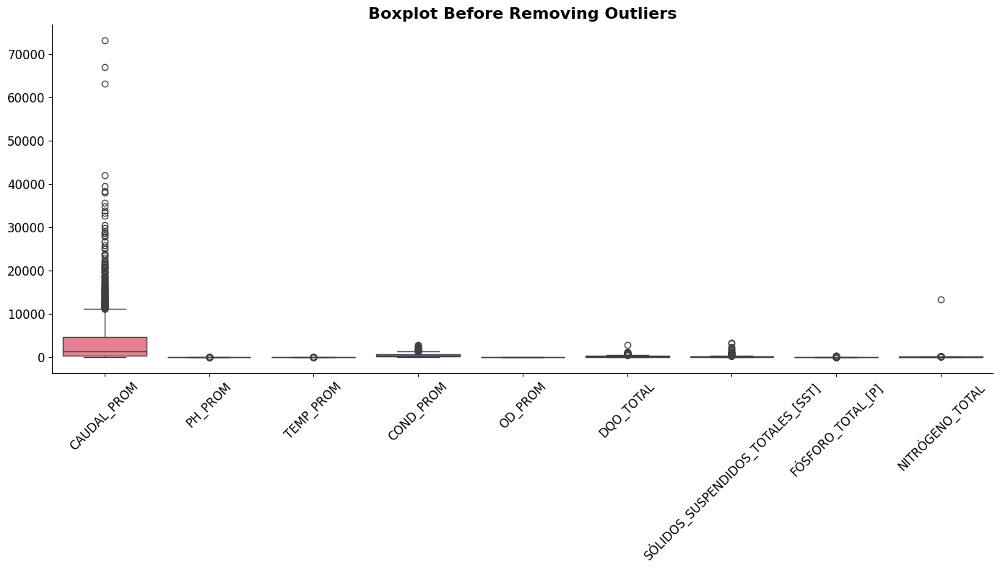

<Figure size 640x480 with 0 Axes>

In [217]:
# Columns for which to plot boxplots
box_plot_columns = [
    'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM',
    'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]',
    'FÓSFORO_TOTAL_[P]', 'NITRÓGENO_TOTAL'
]

# color palette
sns.set_palette("Set2")

# Creatin a new figure
plt.figure(figsize=(14, 8))

# Plot boxplot with rotated x-axis labels for better readability
sns.boxplot(data=df_values_filtered[box_plot_columns])

plt.title("Boxplot Before Removing Outliers", fontsize=16, weight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Remove unnecessary gridlines
sns.despine()

# Display
plt.tight_layout()
plt.show()
plt.savefig(output_path+'/boxplot_before_removing_outliers.png')


In [218]:
# Check for NULLs in each numeric column and how many NULLs
null_counts = df_values_filtered.isnull().sum()

# Display the NULL counts
null_counts

,0
CODIGO,0
ESTACIONID,0
RIOID,0
FECHA,0
HORA_INICIAL,0
HORA_FINAL,2
ALTURA,140
CAUDAL_PROM,0
PH_PROM,0
TEMP_PROM,0


In [219]:
#remove nulls
df_no_nulls = df_values_filtered.dropna()

In [220]:
#remove outliers

numeric_df = df_no_nulls.select_dtypes(include='number')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df_no_nulls[
    ~((numeric_df < (Q1 - 1.5 * IQR)) |
      (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)
]


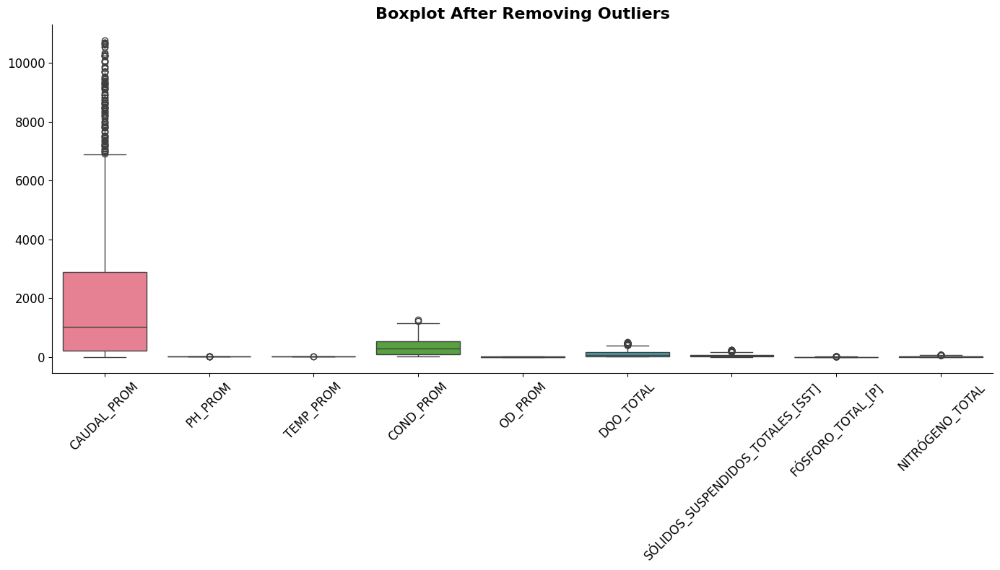

<Figure size 640x480 with 0 Axes>

In [221]:

# Columns for which to plot boxplots
box_plot_columns = [
    'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM',
    'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]',
    'FÓSFORO_TOTAL_[P]', 'NITRÓGENO_TOTAL'
]

sns.set_palette("Set2")


plt.figure(figsize=(14, 8))
sns.boxplot(data=df_clean[box_plot_columns])
plt.title("Boxplot After Removing Outliers", fontsize=16, weight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()
plt.savefig(output_path+'/boxplot_after_removing_outliers.png')

In [222]:
print(df_clean.columns)


Index(['CODIGO', 'ESTACIONID', 'RIOID', 'FECHA', 'HORA_INICIAL', 'HORA_FINAL',
       'ALTURA', 'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM',
       'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]', 'FÓSFORO_TOTAL_[P]',
       'NITRÓGENO_TOTAL', 'MONTH'],
      dtype='object')


In [223]:

df_stations.columns = df_stations.columns.str.strip()

# Clean join keys
df_clean["ESTACIONID"] = df_clean["ESTACIONID"].astype(str).str.strip()
df_stations["ESTACIONID"] = df_stations["ESTACIONID"].astype(str).str.strip()

# Keep only needed columns
df_stations_small = df_stations[["ESTACIONID", "Latitud", "Longitud"]].drop_duplicates()

# Merge CLEAN data with stations
df_joined = df_clean.merge(
    df_stations_small,
    on="ESTACIONID",
    how="left"
)
print(df_joined.shape)
df_joined.head()


(1607, 19)


,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,COND_PROM,OD_PROM,DQO_TOTAL,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],FÓSFORO_TOTAL_[P],NITRÓGENO_TOTAL,MONTH,Latitud,Longitud
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,33.44,7.036,10.8,4.0,0.060,0.677,2,4.401330,-74.142153
1,1902WI03,TU-UAN,TU-T1,2019-02-19,16:00:00,18:00:00,0.520,100.92,7.080,18.66,117.00,6.112,26.7,4.0,0.203,3.619,2,4.491791,-74.122038
2,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,739.00,0.444,418.0,180.0,6.451,54.110,2,4.684657,-74.075427
3,2102HA01,SA-CL53,SA-T2,2019-02-21,08:00:00,10:00:00,0.078,17.90,8.022,15.58,151.40,7.782,26.2,9.0,0.414,4.196,2,4.638753,-74.077998
4,2202WI01,FU-Delirio,FU-T1,2019-02-22,06:00:00,08:00:00,0.390,64.80,7.132,10.86,66.62,7.686,10.0,4.0,0.060,0.877,2,4.555917,-74.060277


In [224]:

# GeoDataFrame from the cleaned data using the correct column names ('Latitud' and 'Longitud')
gdf = gpd.GeoDataFrame(df_joined,
                       geometry=gpd.GeoSeries.from_xy(df_joined['Longitud'], df_joined['Latitud']),
                       crs="EPSG:4326")  # Assuming the original CRS is WGS84
print(gdf.shape)
gdf.head()

(1607, 20)


,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,COND_PROM,OD_PROM,DQO_TOTAL,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],FÓSFORO_TOTAL_[P],NITRÓGENO_TOTAL,MONTH,Latitud,Longitud,geometry
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,33.44,7.036,10.8,4.0,0.060,0.677,2,4.401330,-74.142153,POINT (-74.14215 4.40133)
1,1902WI03,TU-UAN,TU-T1,2019-02-19,16:00:00,18:00:00,0.520,100.92,7.080,18.66,117.00,6.112,26.7,4.0,0.203,3.619,2,4.491791,-74.122038,POINT (-74.12204 4.49179)
2,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,739.00,0.444,418.0,180.0,6.451,54.110,2,4.684657,-74.075427,POINT (-74.07543 4.68466)
3,2102HA01,SA-CL53,SA-T2,2019-02-21,08:00:00,10:00:00,0.078,17.90,8.022,15.58,151.40,7.782,26.2,9.0,0.414,4.196,2,4.638753,-74.077998,POINT (-74.078 4.63875)
4,2202WI01,FU-Delirio,FU-T1,2019-02-22,06:00:00,08:00:00,0.390,64.80,7.132,10.86,66.62,7.686,10.0,4.0,0.060,0.877,2,4.555917,-74.060277,POINT (-74.06028 4.55592)


In [225]:
# Reproject to EPSG:4326
gdf = gdf.to_crs(epsg=4326)

gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [226]:
import folium

gdf = gdf.dropna(subset=["Latitud", "Longitud"])

m = folium.Map(
    location=[gdf["Latitud"].mean(), gdf["Longitud"].mean()],
    zoom_start=10,
    tiles=None   # no default layer
)

# Street-style basemap (CARTO, no key)
folium.TileLayer(
    tiles="https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png",
    attr="&copy; OpenStreetMap contributors &copy; CARTO",
    name="CartoDB Positron",
    subdomains="abcd",
).add_to(m)

# Satellite basemap (Esri, no key)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri",
    name="Esri Satellite",
).add_to(m)

for _, row in gdf.iterrows():
    folium.Marker([row["Latitud"], row["Longitud"]], popup=str(row["ESTACIONID"])).add_to(m)

folium.LayerControl().add_to(m)   # lets you switch between the two basemaps
m

In [227]:
# Save the cleaned DataFrame for 'CONSOLIDADO' as CSV with a file name
df_joined.to_csv(output_path+'/processed_measures_clean_consolidado.csv', index=False)

# Save the GeoDataFrame to a shapefile for 'CONSOLIDADO' stations
gdf.to_file(output_path+'/stations_measures_consolidado.shp')

### Preparation CLC data

In [228]:
#Reading Corine Land Cover Data
clc_path = dir+"/CLC_2022_AOI.shp"
gdf_clc = gpd.read_file(clc_path)
gdf_clc.columns

Index(['codigo', 'leyenda', 'insumo', 'apoyo', 'confiabili', 'cambio',
       'nivel_1', 'nivel_2', 'nivel_3', 'nivel_4', 'nivel_5', 'nivel_6',
       'area_ha', 'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')

In [229]:
# Normalize strings
nivel2_col = 'nivel_2'
gdf_clc[nivel2_col] = gdf_clc[nivel2_col].astype(str).str.strip()

nivel2_to_class = {
    # Urban
    "11": "Urban",
    "12": "Industrial",
    "13": "Mining",
    "14": "Vegetation",

    # Agriculture / Cultivos
    "21": "Crops",
    "22": "Crops",
    "23": "Vegetation",
    "24": "Crops",

    # Forest / Natural vegetation / Soils
    "31": "Vegetation",
    "32": "Vegetation",
    "33": "Soils",

    # Wetlands
    "41": "Wetlands",
    "42": "Wetlands",

    # Water
    "51": "Water",
    "52": "Water",
}

# Create new column with aggregated class
gdf_clc["CLC_CLASS"] = gdf_clc[nivel2_col].map(nivel2_to_class)
gdf_clc["CLC_CLASS"] = gdf_clc["CLC_CLASS"].fillna("Other")
gdf_clc.head()

,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,nivel_4,nivel_5,nivel_6,area_ha,Shape_Leng,Shape_Area,geometry,CLC_CLASS
0,231,231,Landsat_2022_mediana_09032023,GoogleMaps,SI,2,2,23,231,None,None,None,29851.398805,10.970414,0.024378,"MULTIPOLYGON Z (((-73.97122 4.81788 0, -73.971...",Vegetation
1,3222,3222,Landsat_2022_mediana_09032023,None,SI,1,3,32,322,3222,None,None,51.159703,0.055674,0.000042,"POLYGON Z ((-74.07653 4.34227 0, -74.07654 4.3...",Vegetation
2,231,231,Landsat_2022_mediana_09032023,None,SI,1,2,23,231,None,None,None,26.876228,0.048568,0.000022,"POLYGON Z ((-74.0734 4.37712 0, -74.07321 4.37...",Vegetation
3,3222,3222,Landsat_2022_mediana_09032023,None,SI,2,3,32,322,3222,None,None,687.505077,0.484883,0.000561,"POLYGON Z ((-74.03559 4.5084 0, -74.03589 4.50...",Vegetation
4,231,231,Landsat_2022_mediana_09032023,None,SI,1,2,23,231,None,None,None,58.284951,0.045085,0.000048,"POLYGON Z ((-74.03239 4.30466 0, -74.03263 4.3...",Vegetation


In [230]:
obs_per_class = gdf_clc.groupby('CLC_CLASS').size()
obs_per_class

,0
CLC_CLASS,
Crops,445
Industrial,106
Mining,34
Soils,2
Urban,137
Vegetation,621
Water,13
Wetlands,15


+init=epsg:3116 +type=crs


,CLC_CLASS,Total Area (km²)
0,Crops,858.911499
1,Industrial,71.971772
2,Mining,27.889455
3,Soils,0.538098
4,Urban,386.451830
5,Vegetation,1200.556225
6,Water,18.838065
7,Wetlands,13.360918


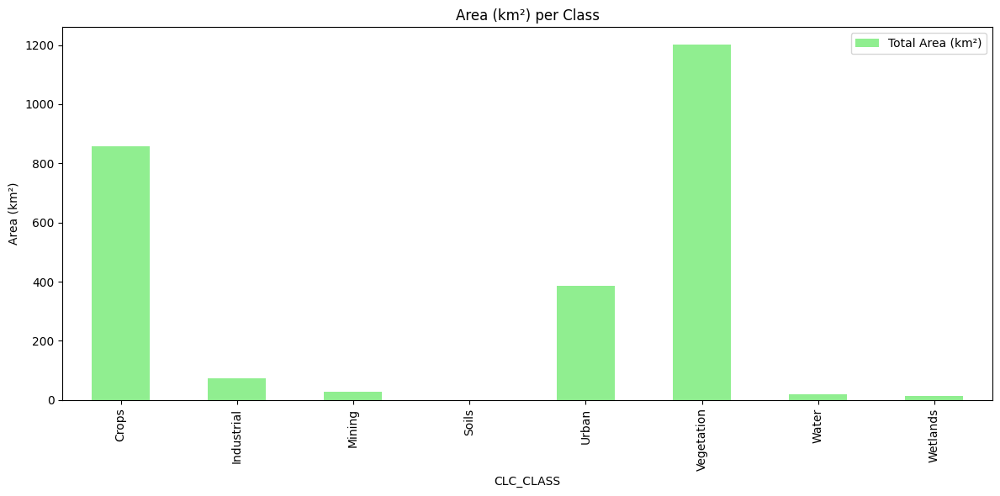

In [231]:
gdf_clcar = gdf_clc.copy()
gdf_clcar= gdf_clcar.to_crs({'init': 'epsg:3116'})
print(gdf_clcar.crs)
gdf_clcar.head(2)
#Calculate area
gdf_clcar["area"] = gdf_clcar['geometry'].area/ 10**6
gdf_clcar.head(2)
area_per_class_table = gdf_clcar.groupby('CLC_CLASS')['area'].sum().reset_index()
area_per_class_table.rename(columns={'area': 'Total Area (km²)'}, inplace=True)
display(area_per_class_table)

# Plot area per class
area_per_class_table.set_index('CLC_CLASS').plot(kind='bar', figsize=(12, 6), color='lightgreen')
plt.title('Area (km²) per Class')
plt.xlabel('CLC_CLASS')
plt.ylabel('Area (km²)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



### Process Google Earth Engine
Collect the images Sentinel-2 for AOI and period 2019-2025

In [ ]:
# Log in with your own Google account (Earth Engine must be enabled for your project)
# Replace with YOUR Google Cloud project ID that has Earth Engine enabled
EE_PROJECT = "your-project-id"
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)

In [233]:
# function to establish format of date in image
def func_ssn(img):
  return img.set('Date', ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'));#FORMAT DATES

# CLOUD_PROB_THRESH = 80
NDWI_WATER_THRESH = 0.0 # tune 0.0–0.1 depending on turbidity/shadows
def mask_clouds_shadows(image, CLOUD_PROB_THRESH):
    """
    Mask clouds using s2cloudless probability, and remove shadows/cirrus/snow using SCL.
    Keep reflectance scaled to [0,1].
    """
    prob = ee.Image(image.get("cloud_mask")).select("probability")
    cloud_mask = prob.lt(CLOUD_PROB_THRESH)

    scl = image.select("SCL")
    # Remove problematic SCL classes: cloud shadow (3), clouds (7,8,9), cirrus (10), snow/ice (11), no data (0), saturated (1)
    scl_mask = (scl.neq(0)
                .And(scl.neq(1))
                .And(scl.neq(3))
                .And(scl.neq(7))
                .And(scl.neq(8))
                .And(scl.neq(9))
                .And(scl.neq(10))
                .And(scl.neq(11)))

    # Apply masks + scale reflectance
    img = (image.updateMask(cloud_mask)
                 .updateMask(scl_mask)
                 .divide(10000)
                 .copyProperties(image, ["system:time_start"]))

    return img

def add_indices(image):
    B2  = image.select("B2")
    B3  = image.select("B3")
    B4  = image.select("B4")
    B5  = image.select("B5")
    B6  = image.select("B6")
    B8  = image.select("B8")
    B8A = image.select("B8A")
    B11 = image.select("B11")
    B12 = image.select("B12")

    # Water indices
    ndwi  = image.normalizedDifference(["B3", "B8"]).rename("NDWI")
    mndwi = image.normalizedDifference(["B3", "B11"]).rename("MNDWI")

    # Turbidity/SST proxies
    ndti = image.normalizedDifference(["B4", "B3"]).rename("NDTI")
    rg_ratio = B4.divide(B3).rename("RG_ratio")

    # Paper indices (Peng et al., 2024)
    ndci = (B5.subtract(B4)).divide(B5.add(B4)).rename("NDCI")
    tpindex = B2.divide(B3.add(B4).add(B12)).rename("TPindex")
    tnindex = (B11.subtract(B12)).divide(B5.add(B8A)).rename("TNindex")
    codindex = (B6.add(B8A)).divide(B4.subtract(B12)).rename("CODindex")

    return image.addBands([
        ndwi, mndwi,
        ndti, rg_ratio,
        ndci, tpindex, tnindex, codindex
    ])

def mask_to_water(image):
    return image.updateMask(image.select("NDWI").gt(NDWI_WATER_THRESH))

def maskClouds1(img):
  MAX_CLOUD_PROBABILITY = 70
  clouds = ee.Image(img.get('cloud_mask')).select('probability');
  isNotCloud = clouds.lt(MAX_CLOUD_PROBABILITY)
  return img.updateMask(isNotCloud)

def maskS2clouds(image):
  qa = image.select('QA60')
  #scl = image.select('SCL')

  # Bits 10 and 11 are clouds and cirrus, respectively.
  cloudBitMask = 1 << 10
  cirrusBitMask = 1 << 11

  # Both flags should be set to zero, indicating clear conditions.
  mask = qa.bitwiseAnd(cloudBitMask).eq(0) \
      .And(qa.bitwiseAnd(cirrusBitMask).eq(0))
      #.And(scl.eq(9))

  return image.updateMask(mask).divide(10000).copyProperties(image,['system:time_start'])

# function to generate satelite image of Sentinel-2
def gimagest(aoi,fecha1, fecha2,MAX_CLOUD_PROBABILITY,op):
    if(op==1):
        imagest = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterDate(ee.Date(fecha1), ee.Date(fecha2)).filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',MAX_CLOUD_PROBABILITY)).filterBounds(aoi).map(maskS2clouds)
        datasets2s2 = imagest.map(func_ssn)
        s2Clouds = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        criteria = ee.Filter.And(ee.Filter.bounds(aoi), ee.Filter.date(fecha1, fecha2))
        s2Clouds = s2Clouds.filter(criteria)
        s2SrWithCloudMask = ee.Join.saveFirst('cloud_mask').apply(**{
          'primary': datasets2s2,
          'secondary': s2Clouds,
          'condition': ee.Filter.equals(**{'leftField': 'system:index', 'rightField': 'system:index'})
        })
        s2_clean = ee.ImageCollection(s2SrWithCloudMask).map(maskClouds1).select('B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12')
        print("Number images: "+str(s2_clean.size().getInfo()))
        # imagest = s2CloudMasked.median().select('B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12').clip(aoi)
    elif(op==2):
        imagest = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterDate(ee.Date(fecha1), ee.Date(fecha2)).filterBounds(aoi)
        datasets2s2 = imagest.map(func_ssn)
        s2Clouds = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        criteria = ee.Filter.And(ee.Filter.bounds(aoi), ee.Filter.date(fecha1, fecha2))
        s2Clouds = s2Clouds.filter(criteria)

        s2SrWithCloudMask = ee.Join.saveFirst('cloud_mask').apply(**{
          'primary': datasets2s2,
          'secondary': s2Clouds,
          'condition': ee.Filter.equals(**{'leftField': 'system:index', 'rightField': 'system:index'})
        })

        s2_clean = ee.ImageCollection(s2SrWithCloudMask).map(lambda m: mask_clouds_shadows(m,MAX_CLOUD_PROBABILITY)).select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12'])
        print("Number images: "+str(s2_clean.size().getInfo()))
    s2_idx = s2_clean.map(add_indices)

    return s2_idx

#Composite Monthly
def monthly_composite(imagen_zb, year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    comp = (imagen_zb.filterDate(start, end)
                    .median()
                    .set("year", year)
                    .set("month", month)
                    .set("system:time_start", start.millis()))
    return comp

# -----------------------------
# Monthly composites for fallback (very fast)
# -----------------------------
def composite(date_obj, months=1):
    date = ee.Date.parse("YYYY-MM-dd", date_obj)
    month_start = ee.Date.parse("YYYY-MM-dd", date.format("YYYY-MM-01"))
    month_end = month_start.advance(months, "month")
    img = imagen_zb.filterDate(month_start, month_end).median().select(BANDS_TO_SAMPLE)
    return img.set({"system:time_start": month_start.millis(),"S2_DATE_USED": month_start.format("YYYY-MM-dd"),"FALLBACK_MONTHLY": True})


In [234]:
#Collecting Image Collection Sentinel-2
fecha1 = '2019-01-01'
fecha2 = '2025-12-31'
raoi = dir+"/AOI_DS.shp"
df_aoi= gpd.read_file(raoi)
rutasc = df_aoi['geometry']
areasc = geemap.gdf_to_ee(df_aoi)
imagen_zb = gimagest(areasc, fecha1, fecha2, 80,1)

Number images: 1065


In [235]:
#Reading Stations
gdf_sst = gpd.GeoDataFrame(
    df_stations,
    geometry=gpd.points_from_xy(
        df_stations["Longitud"],
        df_stations["Latitud"]
    ),
    crs="EPSG:4326"
)
#Read Areas Water Body Bogota
bw_bta = dir+"/BodyWater_BTA.shp"
bw_bta = gpd.read_file(bw_bta)
#Clip by AOI
bw_btacl = bw_bta.clip(df_aoi).to_crs(4326)

# Visualization
Map = geemap.Map(center=[4.65, -74.1], zoom=11, basemap="HYBRID")
TrueColorVis = {'min': 0, 'max': 0.6, 'bands': ['B11', 'B8', 'B2']}
Map.addLayer(imagen_zb.median().clip(areasc),TrueColorVis, "Mosaico")
Map.add_gdf(bw_btacl, "WaterBody_BTA")
vis_ndti = {"min": -0.7, "max": 0.3, "palette": ["red", "white", "blue"]}
Map.addLayer(imagen_zb.median().clip(areasc).select("NDWI"), vis_ndti, "NDWI")
Map.add_gdf(gdf_sst, "Stations")
Map

Map(center=[4.65, -74.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

#### Filtering Stations

In [236]:
stations = ['FU-Americas','FU-Delirio','FU-KR7','SA-Arzobis','SA-CL53','SA-ParqNal','TO-BosqueP','TO-CL161','TO-Jardpaz']
gdf_sst_filtered = gdf_sst.drop(gdf_sst[gdf_sst['ESTACIONID'].isin(stations)].index)

print(f"Original number of stations: {len(gdf_sst)}")
print(f"Number of stations to exclude: {len(stations)}")
print(f"Number of stations after exclusion: {len(gdf_sst_filtered)}")

gdf_sst_filtered.head()

Original number of stations: 30
Number of stations to exclude: 9
Number of stations after exclusion: 21


,ESTACIONID,Estación,Río,Tramo,RIOID,Abscisado,Fotografia,Fotografia 2,Pais,Latitud,Longitud,"Latitud, Longitud",geometry
0,BO-Cierre,Cierre,Bogotá,NaN,Río Bogotá,77.400,https://drive.google.com/uc?export=view&id=1vL...,https://drive.google.com/uc?export=view&id=16o...,Colombia,4.632012,-74.229653,"4,632012, -74,229653",POINT (-74.22965 4.63201)
1,BO-PComun,Puente Común,Bogotá,NaN,Río Bogotá,0.000,https://drive.google.com/uc?export=view&id=1tp...,https://drive.google.com/uc?export=view&id=1Xk...,Colombia,4.861869,-74.030414,"4,861869, -74,030414",POINT (-74.03041 4.86187)
2,FU-Alameda,Fucha con Alameda,Fucha,4.0,FU-T4,17.933,https://drive.google.com/uc?export=view&id=1Cm...,https://drive.google.com/uc?export=view&id=1Nw...,Colombia,4.662606,-74.152148,"4,662606, -74,152148",POINT (-74.15215 4.66261)
4,FU-Boyaca,Fucha Avenida Boyacá,Fucha,3.0,FU-T3,14.435,https://drive.google.com/uc?export=view&id=1Fo...,https://drive.google.com/uc?export=view&id=1_D...,Colombia,4.643252,-74.124876,"4,643252, -74,124876",POINT (-74.12488 4.64325)
6,FU-Ferroca,Avenida Ferrocarril,Fucha,2.0,FU-T2,10.206,https://drive.google.com/uc?export=view&id=1B3...,https://drive.google.com/uc?export=view&id=13h...,Colombia,4.611653,-74.121974,"4,611653, -74,121974",POINT (-74.12197 4.61165)


In [237]:
# Station usability: ensure sampled pixels are water (avoid mixed land pixels)
# ============================================================
# Compute "water_fraction" within a buffer for each station using NDWI-based water mask
# and then flag stations as usable if water_fraction >= threshold and enough valid pixels.

#Check duplicates
gdf_stations = gdf_sst_filtered[["ESTACIONID", "geometry"]].drop_duplicates("ESTACIONID").to_crs(4326).copy()
#Convert gpd to ee
stations_fc = geemap.geopandas_to_ee(gdf_stations, geodesic=False)
#Parameters
BUFFER_M = 40  # increase buffer to capture enough water pixels in narrow rivers
WATER_FRAC_THRESH = 0 #threshold fraction water
MIN_VALID_PIXELS = 2
SCALE = 10
NDWI_WATER_THRESH = 0 #value greatest than in NDWI

def buffer_feature(feat):
    return feat.buffer(BUFFER_M)

stations_buf_fc = stations_fc.map(buffer_feature)

def per_image_station_stats(image):
    """
    For one monthly composite:
    - water_mask = NDWI > NDWI_WATER_THRESH
    - water_fraction = mean(water_mask) inside buffer
    - n_valid_pixels = count(water_mask) inside buffer
    """
    water_mask = image.select("NDWI").gt(NDWI_WATER_THRESH).rename("water_mask")

    def stats_for_feat(feat):
        stats = water_mask.reduceRegion(
            reducer=ee.Reducer.mean().combine(ee.Reducer.count(), sharedInputs=True),
            geometry=feat.geometry(),
            scale=SCALE,
            maxPixels=1e9
        )
        return feat.set({
            "year": image.get("year"),
            "month": image.get("month"),
            "water_fraction": stats.get("water_mask_mean"),
            "n_valid_pixels": stats.get("water_mask_count")
        })

    return stations_buf_fc.map(stats_for_feat)

#Create mosaics monthly
years = ee.List.sequence(2019, 2025)
months = ee.List.sequence(1, 12)
subset_ic = ee.ImageCollection(
    years.map(lambda y: months.map(lambda m: monthly_composite(imagen_zb, y, m))).flatten()
)

station_stats_fc = ee.FeatureCollection(subset_ic.map(per_image_station_stats).flatten())
print(station_stats_fc.first().getInfo())

def add_station_flags(feat):
    sid = feat.get("ESTACIONID")
    f = station_stats_fc.filter(ee.Filter.eq("ESTACIONID", sid))
    water_med = f.aggregate_mean("water_fraction")
    pix_med = f.aggregate_count("n_valid_pixels")
    usable = ee.Number(water_med).gt(WATER_FRAC_THRESH).And(ee.Number(pix_med).gte(MIN_VALID_PIXELS))
    return feat.set({
        "water_fraction_median": water_med,
        "n_valid_pixels_median": pix_med,
        "usable_for_s2": usable
    })

stations_flagged = stations_fc.map(add_station_flags)
stations_flags_df = geemap.ee_to_df(stations_flagged)

print(stations_flags_df["usable_for_s2"].value_counts(dropna=False))

stations_flags_df.to_csv(output_path+"/stations_s2_usability.csv", index=False)
stations_flags_df.sort_values("water_fraction_median")

{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-74.229653, 4.6323719546380655], [-74.22975386964188, 4.632357628436323], [-74.2298467100488, 4.632315790198418], [-74.2299241311165, 4.6322497702525505], [-74.22997997012612, 4.632164823792292], [-74.23000978229729, 4.632067712561327], [-74.23001119459104, 4.631966166616976], [-74.22998409460077, 4.631868269016567], [-74.2299306394959, 4.6317818124060475], [-74.22985508430818, 4.631713678726298], [-74.22976344322933, 4.631669291412311], [-74.22966301088188, 4.631652183689601], [-74.22956178166942, 4.631663717330921], [-74.22946781342561, 4.631702974259766], [-74.22938858601432, 4.631766829628839], [-74.22933040593499, 4.6318502005565785], [-74.22929790432607, 4.6319464507227135], [-74.22929366832514, 4.632047918617614], [-74.22931803512978, 4.632146527397345], [-74.22936906515288, 4.632234427800274], [-74.2294426964106, 4.632304622949171], [-74.22953306785426, 4.632351525304242], [-74.22963298591009, 4.6323714014331

,ESTACIONID,n_valid_pixels_median,usable_for_s2,water_fraction_median
10,TO-Ssimon,84,0,0.000000
19,TU-UAN,84,0,0.000000
20,TU-Yomasa,84,0,0.000000
11,TU-DJuana,84,1,0.000316
12,TU-IslaPon,84,1,0.003053
13,TU-MakroS,84,1,0.004768
15,TU-PteInde,84,1,0.004781
17,TU-SBenito,84,1,0.005518
6,FU-ZFranca,84,1,0.011688
5,FU-VisionC,84,1,0.014301


In [238]:
df_stcleaned = pd.merge(stations_flags_df.query('usable_for_s2>0'), df_stations, how='left', on='ESTACIONID')
print(df_stcleaned.columns)
# Check the result of the join
df_stcleaned.head()

gdf_sst_cl = gpd.GeoDataFrame(
    df_stcleaned,
    geometry=gpd.points_from_xy(
        df_stcleaned["Longitud"],
        df_stcleaned["Latitud"]
    ),
    crs="EPSG:4326"
)
Map = geemap.Map(center=[4.65, -74.1], zoom=11, basemap="HYBRID")
TrueColorVis = {'min': 0, 'max': 0.6, 'bands': ['B11', 'B8', 'B2']}
Map.addLayer(imagen_zb.median().clip(areasc),TrueColorVis, "Mosaico")
Map.add_gdf(bw_btacl, "WaterBody_BTA")
vis_ndti = {"min": -0.7, "max": 0.3, "palette": ["red", "white", "blue"]}
Map.addLayer(imagen_zb.median().clip(areasc).select("NDWI"), vis_ndti, "NDWI")
Map.add_gdf(gdf_sst, "Stations")
Map.add_gdf(gdf_sst_cl, "Stations_Clean")
Map

Index(['ESTACIONID', 'n_valid_pixels_median', 'usable_for_s2',
       'water_fraction_median', 'Estación', 'Río', 'Tramo', 'RIOID',
       'Abscisado', 'Fotografia', 'Fotografia 2', 'Pais', 'Latitud',
       'Longitud', 'Latitud, Longitud'],
      dtype='object')


Map(center=[4.65, -74.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

#### Matchups data in-situ / Sentinel-2
**Process**
![](images/matchups_process.png)

In [239]:
FIELD_CSV = output_path+"/processed_measures_clean_consolidado.csv"
FLAGS_CSV = output_path+"/stations_s2_usability.csv"

stations_flags_df
usable_ids = stations_flags_df.loc[stations_flags_df["usable_for_s2"] == 1, "ESTACIONID"].unique()

print(f"Usable stations found: {len(usable_ids)}")

Usable stations found: 18


In [240]:
df = pd.read_csv(FIELD_CSV)
print("Measures before filtering:", df.shape)
df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")
df = df[df["ESTACIONID"].isin(usable_ids)].copy()
print("Measures after filtering:", df.shape)
df


Measures before filtering: (1607, 19)
Measures after filtering: (816, 19)


,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,COND_PROM,OD_PROM,DQO_TOTAL,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],FÓSFORO_TOTAL_[P],NITRÓGENO_TOTAL,MONTH,Latitud,Longitud
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,33.44,7.036,10.8,4.00,0.060,0.677,2,4.401330,-74.142153
2,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,739.00,0.444,418.0,180.00,6.451,54.110,2,4.684657,-74.075427
11,1903HA04,SA-Alameda,SA-T4,2019-03-19,16:00:00,18:00:00,1.140,2400.80,7.224,19.36,676.60,0.546,426.0,130.00,4.719,42.432,3,4.736962,-74.126628
14,2603AN01,FU-Boyaca,FU-T3,2019-03-26,08:00:00,10:00:00,0.336,591.38,8.030,18.00,279.00,4.618,68.0,36.67,1.145,10.990,3,4.643252,-74.124876
15,2603AN02,FU-ZFranca,FU-T4,2019-03-26,12:00:00,14:00:00,1.990,5618.60,8.034,21.04,920.40,0.666,437.0,146.00,7.005,66.044,3,4.662291,-74.143063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1601,020925AP01,FU-VisionC,FU-T4,2025-09-02,06:00:00,08:00:00,0.510,3238.00,7.654,15.46,478.60,2.244,237.0,15.30,2.790,1.107,9,4.651222,-74.133120
1602,030925FM01,TU-DJuana,TU-T2,2025-09-03,08:00:00,10:00:00,0.770,5399.00,8.744,11.80,207.40,2.638,68.8,5.00,0.202,26.107,9,4.522396,-74.127489
1603,030925FM02,TU-Mexico,TU-T3,2025-09-03,12:00:00,14:00:00,1.390,6041.00,7.984,14.20,333.60,0.736,78.4,5.19,0.180,17.507,9,4.558652,-74.134185
1604,040925AP01,SA-Carrefo,SA-T3,2025-09-04,06:00:00,08:00:00,1.110,1936.00,7.506,15.88,156.00,0.864,60.4,5.00,0.601,13.009,9,4.684657,-74.075427


In [241]:
# This process takes around 40 minutes
# Build station FeatureCollection (only usable stations)

st = df[["ESTACIONID","Longitud","Latitud"]].drop_duplicates("ESTACIONID").copy()
gdf_st = gpd.GeoDataFrame(
    st,
    geometry=gpd.points_from_xy(st["Longitud"], st["Latitud"]),
    crs="EPSG:4326"
)
stations_fc_all = geemap.geopandas_to_ee(gdf_st, geodesic=False)

def annual_mosaic(year_int):
    start = ee.Date.fromYMD(year_int, 1, 1)
    end = start.advance(1, "year")
    img = imagen_zb.filterDate(start, end).median().select(BANDS_TO_SAMPLE)
    return img.set({"system:time_start": start.millis()})

#Bands to use
BANDS_TO_SAMPLE = imagen_zb.first().bandNames().getInfo()

# Matchups by unique field date
#Parameters
WINDOW_DAYS = 9
SCALE = 10
TOPK = 3
MIN_VALID_FRAC = 0.3
months = 9
results = []

# unique dates
unique_dates = sorted(df["FECHA"].dt.strftime("%Y-%m-%d").unique())
print("Unique field dates to process:", len(unique_dates))

# enough stations have non-null TEST_BAND when sampled at points
def pick_valid_image(ic, stations_fc, field_date_str, months):
    n = ic.size().getInfo()
    # print(n)
    if n == 0:
        return annual_mosaic(int(pd.to_datetime(field_date_str).year)), True

    ic_sorted = ic.sort("CLOUDY_PIXEL_PERCENTAGE")
    k = min(TOPK, n)
    ic_list = ic_sorted.toList(k)

    # Try up to TOPK images
    for i in range(k):
        img_i = ee.Image(ic_list.get(i))

        #sample only one band
        test_fc = img_i.select(['B3']).sampleRegions(
            collection=stations_fc,
            scale=SCALE,
            geometries=False
        )

        test_df = geemap.ee_to_df(test_fc)
        # print(test_df)

        if test_df is None or test_df.empty:
            continue
        if 'B3' not in test_df.columns:
            continue

        valid_count = pd.to_numeric(test_df['B3'], errors="coerce").notna().sum()
        valid_frac = valid_count / max(len(test_df), 1)

        if valid_frac >= MIN_VALID_FRAC:
            return img_i, False

    # If none of TOPK images worked, fallback monthly
    return annual_mosaic(int(pd.to_datetime(field_date_str).year)), True

for d in unique_dates:
    print(d)
    day = pd.to_datetime(d)
    start = (day - pd.Timedelta(days=WINDOW_DAYS)).strftime("%Y-%m-%d")
    end   = (day + pd.Timedelta(days=WINDOW_DAYS+1)).strftime("%Y-%m-%d")

    # stations measured on this date
    df_day = df[df["FECHA"].dt.strftime("%Y-%m-%d") == d].copy()
    st_day = df_day[["ESTACIONID","Longitud","Latitud"]].drop_duplicates("ESTACIONID")
    gdf_day_st = gpd.GeoDataFrame(
        st_day,
        geometry=gpd.points_from_xy(st_day["Longitud"], st_day["Latitud"]),
        crs="EPSG:4326"
    )
    stations_fc = geemap.geopandas_to_ee(gdf_day_st, geodesic=False)
    # stations_fc = stations_fc.map(lambda f: f.buffer(BUFFER_M))
    # print(len(gdf_day_st))

    # Candidate images in window
    ic = imagen_zb.filterDate(start, end).filterBounds(areasc)

    img, fallback = pick_valid_image(ic, stations_fc, d, months)

    # Satellite date actually used (from image timestamp)
    s2_date_used = ee.Date(img.get("system:time_start")).format("YYYY-MM-dd")

    # IMPORTANT: returns feature per input feature (station buffer)
    sampled_fc = img.select(BANDS_TO_SAMPLE).sampleRegions(
        collection=stations_fc,
        scale=SCALE,
        geometries=False
    )
    # Attach metadata
    sampled_fc = sampled_fc.map(lambda f: f.set({
        "FIELD_DATE": d,
        "S2_DATE_USED": s2_date_used,
        "FALLBACK_MONTHLY": fallback
    }))

    sampled_df  = geemap.ee_to_df(sampled_fc)
    results.append(sampled_df)
# Combine satellite samples for all field dates
sat_df = pd.concat(results, ignore_index=True)
sat_df

print("sat_df rows:", len(sat_df))

# Save satellite table (by station-date)
outcsv = output_path +"/sat_df_filled_station_date.csv"
sat_df.to_csv(outcsv, index=False)
print("Saved: "+outcsv)


Unique field dates to process: 450
2019-02-19
2019-02-21
2019-03-19
2019-03-26
2019-04-01
2019-04-02
2019-04-03
2019-04-04
2019-04-09
2019-04-11
2019-04-12
2019-04-15
2019-04-16
2019-04-22
2019-04-25
2019-04-29
2019-04-30
2019-05-02
2019-05-07
2019-05-14
2019-05-20
2019-05-23
2019-05-24
2019-05-27
2019-05-28
2019-06-04
2019-06-05
2019-06-10
2019-06-17
2019-07-23
2019-07-25
2019-07-30
2019-08-05
2019-08-13
2019-08-20
2019-08-26
2019-08-27
2019-09-03
2019-09-10
2019-09-11
2019-09-16
2019-09-17
2019-09-25
2019-09-30
2019-10-02
2019-10-07
2019-10-08
2019-10-15
2019-10-22
2019-10-29
2019-12-03
2019-12-04
2019-12-09
2019-12-23
2019-12-26
2020-01-07
2020-01-08
2020-01-13
2020-01-20
2020-01-21
2020-01-28
2020-01-29
2020-01-30
2020-02-03
2020-02-06
2020-02-07
2020-02-10
2020-02-11
2020-02-12
2020-02-13
2020-06-16
2020-06-18
2020-06-19
2020-06-25
2020-06-26
2020-06-30
2020-07-01
2020-07-03
2020-07-06
2020-07-07
2020-07-08
2020-08-26
2020-08-27
2020-08-31
2020-09-07
2020-09-09
2020-09-10
2020-09-

2023-03-31
2023-04-03
2023-04-04
2023-04-14
2023-04-21
2023-04-24
2023-05-02
2023-05-04
2023-05-05
2023-05-09
2023-05-15
2023-06-06
2023-06-07
2023-06-15
2023-06-16
2023-06-20
2023-06-24
2023-06-26
2023-06-27
2023-06-28
2023-06-29
2023-06-30
2023-07-04
2023-07-06
2023-07-10
2023-07-11
2023-07-13
2023-07-19
2023-07-21
2023-07-25
2023-07-26
2023-07-28
2023-07-31
2023-08-01
2023-08-03
2023-08-04
2023-08-08
2023-08-09
2023-08-15
2023-08-16
2023-08-17
2023-08-18
2023-08-23
2023-08-24
2023-08-28
2023-08-29
2023-08-31
2023-09-04
2023-09-05
2023-09-06
2023-09-07
2023-09-11
2023-09-12
2023-09-18
2023-09-20
2023-09-25
2023-10-18
2023-10-25
2023-11-03
2023-11-08
2023-11-10
2023-11-15
2023-11-17
2023-11-20
2023-11-21
2023-11-28
2023-11-29
2023-11-30
2023-12-01
2023-12-05
2023-12-06
2024-02-21
2024-02-22
2024-02-23
2024-02-27
2024-02-28
2024-02-29
2024-03-05
2024-03-06
2024-03-07
2024-03-11
2024-03-12
2024-03-14
2024-03-15
2024-04-01
2024-04-02
2024-04-03
2024-04-05
2024-04-09
2024-04-12
2024-04-15

In [242]:
sat_df = pd.read_csv(output_path +"/sat_df_filled_station_date.csv")

In [243]:
print(sat_df)
# Join back to field events: (ESTACIONID + FIELD_DATE)
df["FIELD_DATE"] = df["FECHA"].dt.strftime("%Y-%m-%d")
out = df.merge(sat_df, on=["ESTACIONID","FIELD_DATE"], how="right")

# Save
OUT_CSV   = output_path+"/matchups_field_sentinel2_filled.csv"
out.to_csv(OUT_CSV, index=False)
print("Output rows (should equal field events):", out.shape[0])
out

         B11     B12       B2      B3       B4       B5       B6       B7  \
0    0.03010  0.0275  0.02680  0.0384  0.03260  0.03710  0.02470  0.02450   
1    0.14170  0.1158  0.06260  0.0839  0.09160  0.11510  0.15110  0.15310   
2    0.05960  0.0414  0.05330  0.0598  0.05390  0.06160  0.09020  0.08990   
3    0.10330  0.0759  0.04130  0.0609  0.06270  0.08730  0.10800  0.12010   
4    0.11140  0.0685  0.04460  0.0622  0.05790  0.08560  0.13770  0.18420   
..       ...     ...      ...     ...      ...      ...      ...      ...   
688  0.02410  0.0219  0.05080  0.0572  0.05070  0.04755  0.02120  0.01835   
689  0.10250  0.0812  0.06360  0.0750  0.08480  0.10330  0.11740  0.13200   
690  0.18030  0.1508  0.16260  0.1598  0.15680  0.19650  0.22400  0.22850   
691  0.13735  0.1021  0.05965  0.0749  0.07485  0.10135  0.13825  0.16685   
692  0.13735  0.1021  0.05965  0.0749  0.07485  0.10135  0.13825  0.16685   

         B8      B8A  ...   Latitud   Longitud     MNDWI      NDCI      NDT

,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,...,Latitud_y,Longitud_y,MNDWI,NDCI,NDTI,NDWI,RG_ratio,S2_DATE_USED,TNindex,TPindex
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,...,4.401330,-74.142153,0.121168,0.064562,-0.081690,0.292929,0.848958,2019-02-13,0.046346,0.272081
1,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,...,4.684657,-74.075427,-0.256206,0.113691,0.043875,-0.168071,1.091776,2019-02-13,0.092335,0.214899
2,1903HA04,SA-Alameda,SA-T4,2019-03-19,16:00:00,18:00:00,1.140,2400.80,7.224,19.36,...,4.736962,-74.126628,0.071855,0.046995,-0.064400,0.040950,0.878993,2019-01-01,0.133333,0.317271
3,2603AN01,FU-Boyaca,FU-T3,2019-03-26,08:00:00,10:00:00,0.336,591.38,8.030,18.00,...,4.643252,-74.124876,-0.266028,0.144530,0.053073,-0.114182,1.112094,2019-01-01,0.110232,0.216941
4,2603AN02,FU-ZFranca,FU-T4,2019-03-26,12:00:00,14:00:00,1.990,5618.60,8.034,21.04,...,4.662291,-74.143063,-0.162838,0.124294,-0.023278,-0.415015,0.954502,2019-01-01,0.153285,0.264218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,300725HA01,TU-Regader,TU-T1,2025-07-30,10:00:00,12:00:00,0.770,4907.00,8.200,12.84,...,4.401330,-74.142153,0.293184,0.017019,-0.058067,0.467361,0.890244,2025-01-01,0.040410,0.362297
689,020925AP01,FU-VisionC,FU-T4,2025-09-02,06:00:00,08:00:00,0.510,3238.00,7.654,15.46,...,4.651222,-74.133120,-0.166580,0.095841,0.025400,-0.128414,1.052124,2025-01-01,0.101615,0.286652
690,030925FM02,TU-Mexico,TU-T3,2025-09-03,12:00:00,14:00:00,1.390,6041.00,7.984,14.20,...,4.558652,-74.134185,-0.060276,0.112369,-0.009476,-0.081609,0.981227,2025-08-30,0.071119,0.347882
691,040925AP01,SA-Carrefo,SA-T3,2025-09-04,06:00:00,08:00:00,1.110,1936.00,7.506,15.88,...,4.684657,-74.075427,-0.269700,0.137932,0.012807,-0.172492,1.026000,2025-01-01,0.117583,0.254793


#### Preparation New Table Stations

In [244]:
df_full = pd.read_csv(output_path+"/matchups_field_sentinel2_filled.csv")
df_full.head()
# Check for NULLs in each numeric column and how many NULLs
null_counts = df_full.isnull().sum()
# Display the NULL counts
print(null_counts)
print(f"Original shape of 'out' DataFrame: {df_full.shape}")

df_full = df_full.dropna(subset=['NITRÓGENO_TOTAL'])

print(f"New shape of 'out' DataFrame after removing nulls in 'NITRÓGENO_TOTAL': {df_full.shape}")
df_full.head()

CODIGO                               0
ESTACIONID                           0
RIOID                                0
FECHA                                0
HORA_INICIAL                         0
HORA_FINAL                           0
ALTURA                               0
CAUDAL_PROM                          0
PH_PROM                              0
TEMP_PROM                            0
COND_PROM                            0
OD_PROM                              0
DQO_TOTAL                            0
SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]    0
FÓSFORO_TOTAL_[P]                    0
NITRÓGENO_TOTAL                      0
MONTH                                0
Latitud_x                            0
Longitud_x                           0
FIELD_DATE                           0
B11                                  0
B12                                  0
B2                                   0
B3                                   0
B4                                   0
B5                       

,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,ALTURA,CAUDAL_PROM,PH_PROM,TEMP_PROM,...,Latitud_y,Longitud_y,MNDWI,NDCI,NDTI,NDWI,RG_ratio,S2_DATE_USED,TNindex,TPindex
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,0.450,7.18,6.794,17.72,...,4.401330,-74.142153,0.121168,0.064562,-0.081690,0.292929,0.848958,2019-02-13,0.046346,0.272081
1,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,0.780,1007.40,8.004,22.50,...,4.684657,-74.075427,-0.256206,0.113691,0.043875,-0.168071,1.091776,2019-02-13,0.092335,0.214899
2,1903HA04,SA-Alameda,SA-T4,2019-03-19,16:00:00,18:00:00,1.140,2400.80,7.224,19.36,...,4.736962,-74.126628,0.071855,0.046995,-0.064400,0.040950,0.878993,2019-01-01,0.133333,0.317271
3,2603AN01,FU-Boyaca,FU-T3,2019-03-26,08:00:00,10:00:00,0.336,591.38,8.030,18.00,...,4.643252,-74.124876,-0.266028,0.144530,0.053073,-0.114182,1.112094,2019-01-01,0.110232,0.216941
4,2603AN02,FU-ZFranca,FU-T4,2019-03-26,12:00:00,14:00:00,1.990,5618.60,8.034,21.04,...,4.662291,-74.143063,-0.162838,0.124294,-0.023278,-0.415015,0.954502,2019-01-01,0.153285,0.264218


In [245]:
all_desired_columns = ['CODIGO', 'ESTACIONID', 'RIOID', 'FECHA', 'HORA_INICIAL', 'HORA_FINAL',
       'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM',
       'DQO_TOTAL', 'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]', 'FÓSFORO_TOTAL_[P]',
       'NITRÓGENO_TOTAL', 'MONTH', 'Latitud_x', 'Longitud_x',
       'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
       'CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex',
       'TPindex']

# Filter the dataframe to use only the necessary columns
df_full_filtered = df_full[all_desired_columns]
df_full_filtered

,CODIGO,ESTACIONID,RIOID,FECHA,HORA_INICIAL,HORA_FINAL,CAUDAL_PROM,PH_PROM,TEMP_PROM,COND_PROM,...,B8,B8A,CODindex,MNDWI,NDCI,NDTI,NDWI,RG_ratio,TNindex,TPindex
0,1902WI02,TU-Regader,TU-T1,2019-02-19,12:00:00,14:00:00,7.18,6.794,17.72,33.44,...,0.0210,0.01900,8.568626,0.121168,0.064562,-0.081690,0.292929,0.848958,0.046346,0.272081
1,2102HA02,SA-Carrefo,SA-T3,2019-02-21,12:00:00,14:00:00,1007.40,8.004,22.50,739.00,...,0.1178,0.16540,-13.078512,-0.256206,0.113691,0.043875,-0.168071,1.091776,0.092335,0.214899
2,1903HA04,SA-Alameda,SA-T4,2019-03-19,16:00:00,18:00:00,2400.80,7.224,19.36,676.60,...,0.0808,0.08970,4.006173,0.071855,0.046995,-0.064400,0.040950,0.878993,0.133333,0.317271
3,2603AN01,FU-Boyaca,FU-T3,2019-03-26,08:00:00,10:00:00,591.38,8.030,18.00,279.00,...,0.0766,0.12050,-9.169141,-0.266028,0.144530,0.053073,-0.114182,1.112094,0.110232,0.216941
4,2603AN02,FU-ZFranca,FU-T4,2019-03-26,12:00:00,14:00:00,5618.60,8.034,21.04,920.40,...,0.1776,0.18370,-14.702966,-0.162838,0.124294,-0.023278,-0.415015,0.954502,0.153285,0.264218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688,300725HA01,TU-Regader,TU-T1,2025-07-30,10:00:00,12:00:00,4907.00,8.200,12.84,25.20,...,0.0173,0.01515,1.850011,0.293184,0.017019,-0.058067,0.467361,0.890244,0.040410,0.362297
689,020925AP01,FU-VisionC,FU-T4,2025-09-02,06:00:00,08:00:00,3238.00,7.654,15.46,478.60,...,0.1010,0.13780,-4.893733,-0.166580,0.095841,0.025400,-0.128414,1.052124,0.101615,0.286652
690,030925FM02,TU-Mexico,TU-T3,2025-09-03,12:00:00,14:00:00,6041.00,7.984,14.20,333.60,...,0.1882,0.21830,73.716698,-0.060276,0.112369,-0.009476,-0.081609,0.981227,0.071119,0.347882
691,040925AP01,SA-Carrefo,SA-T3,2025-09-04,06:00:00,08:00:00,1936.00,7.506,15.88,156.00,...,0.1079,0.15740,-12.157140,-0.269700,0.137932,0.012807,-0.172492,1.026000,0.117583,0.254793


---
## **4. DATA ANALYSIS & VISUALISATION**
---

Typical spatial and non-spatial operations may be the calculation of statistics, the creation of final graphs, maps or other types of informative visualizations. In general, these analytical operations lead the user to a better understanding of the problem or exploratory question at hand.

Organise this section into subsections if necessary.


### Analysis Number of observations

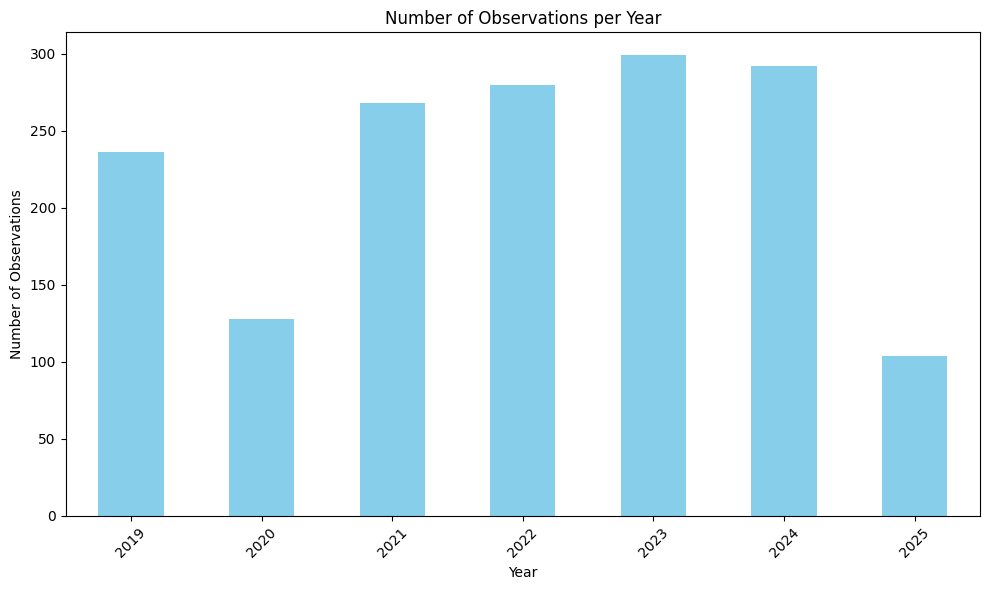

,0
YEAR,
2019,236
2020,128
2021,268
2022,280
2023,299
2024,292
2025,104


<Figure size 640x480 with 0 Axes>

In [246]:
# Group by year and count the number of observations
df_joined['YEAR'] = df_joined['FECHA'].dt.year

# Number of observations per year
observations_per_year = df_joined.groupby('YEAR').size()

# Plot the number of observations per year
observations_per_year.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/observations_per_year.png")
observations_per_year



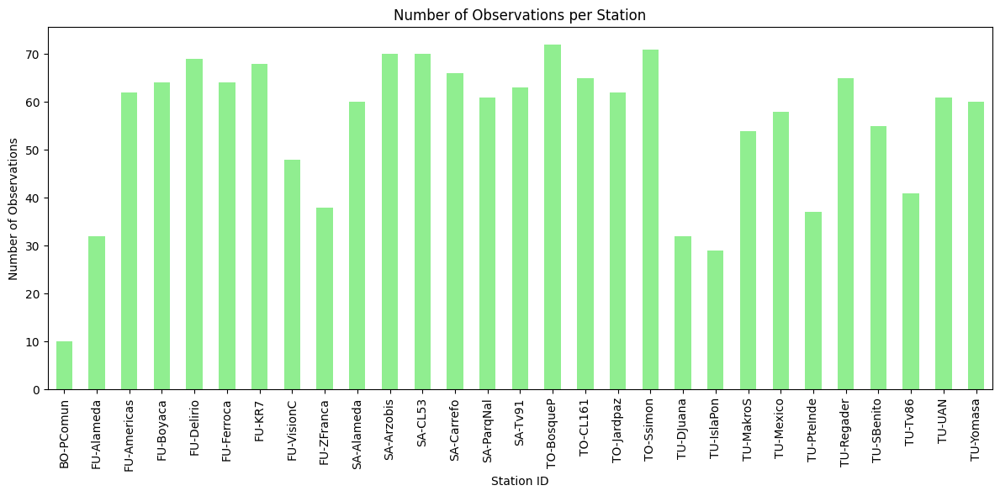

,0
ESTACIONID,
BO-PComun,10
FU-Alameda,32
FU-Americas,62
FU-Boyaca,64
FU-Delirio,69
FU-Ferroca,64
FU-KR7,68
FU-VisionC,48
FU-ZFranca,38


<Figure size 640x480 with 0 Axes>

In [247]:
# Number of observations per station
observations_per_station = df_joined.groupby('ESTACIONID').size()

# Plot number of observations per station
observations_per_station.plot(kind='bar', figsize=(12, 6), color='lightgreen')
plt.title('Number of Observations per Station')
plt.xlabel('Station ID')
plt.ylabel('Number of Observations')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/observations_per_station.png")
observations_per_station

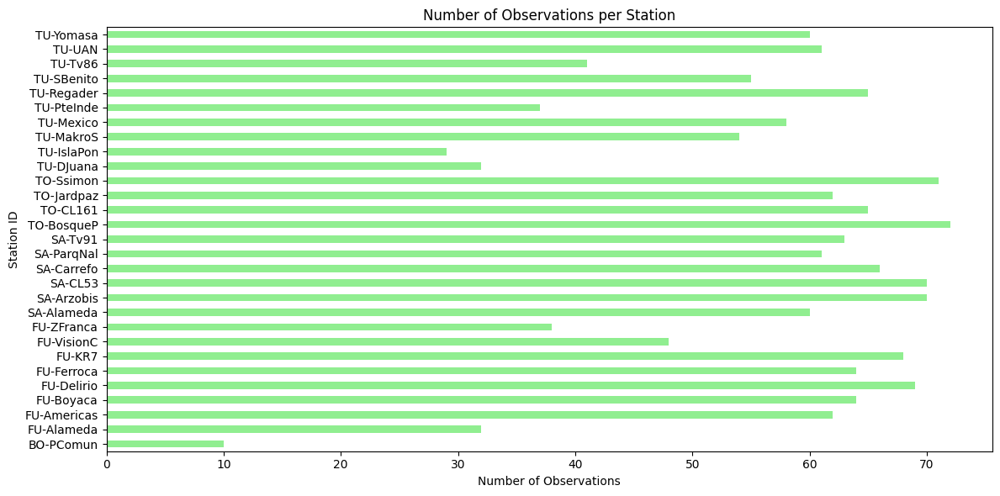

<Figure size 640x480 with 0 Axes>

In [248]:
# Number of observations per station
observations_per_station = df_joined.groupby('ESTACIONID').size()

# Plot number of observations per station
observations_per_station.plot(kind='barh', figsize=(12, 6), color='lightgreen')

# Add chart title and labels
plt.title('Number of Observations per Station')
plt.xlabel('Number of Observations')
plt.ylabel('Station ID')

# Display the plot
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/observations_per_station_h.png")


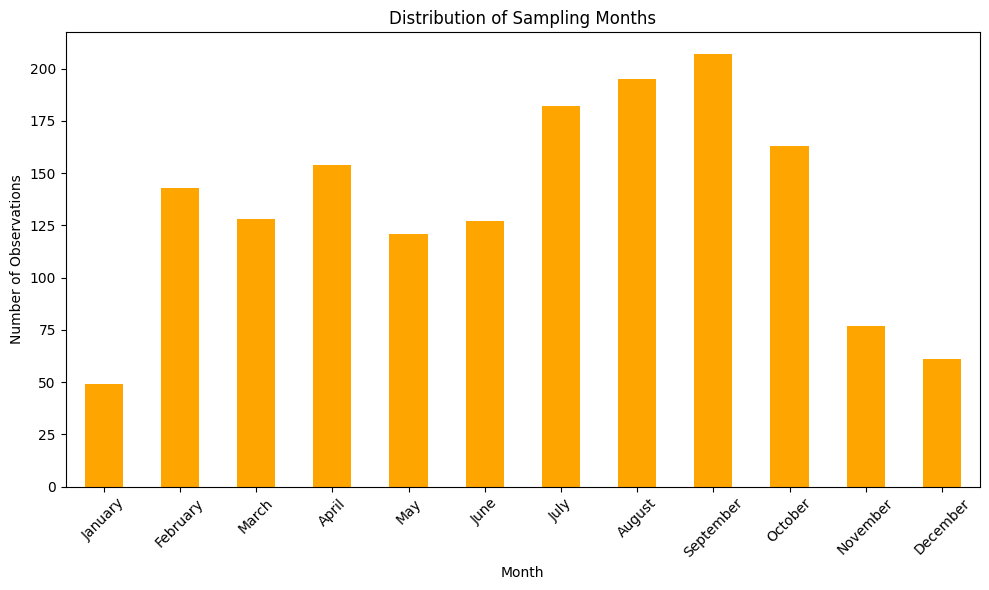

<Figure size 640x480 with 0 Axes>

In [249]:
# Plot distribution of sampling months
import calendar

# Get month counts
month_counts = df_joined['MONTH'].value_counts().sort_index()

# Convert index (month nr) to month names
month_counts.index = [calendar.month_name[int(m)] for m in month_counts.index]

# Plot
month_counts.plot(kind='bar', figsize=(10, 6), color='orange')

plt.title('Distribution of Sampling Months')
plt.xlabel('Month')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/observations_per_month.png")

YEAR         2019  2020  2021  2022  2023  2024  2025
ESTACIONID                                           
BO-PComun       2     1     2     1     1     2     1
FU-Alameda      4     1     5     7     9     6     0
FU-Americas    10     4    11    12    12    10     3
FU-Boyaca      11     5    12    11    10    10     5
FU-Delirio     12     5    12    11    11    13     5


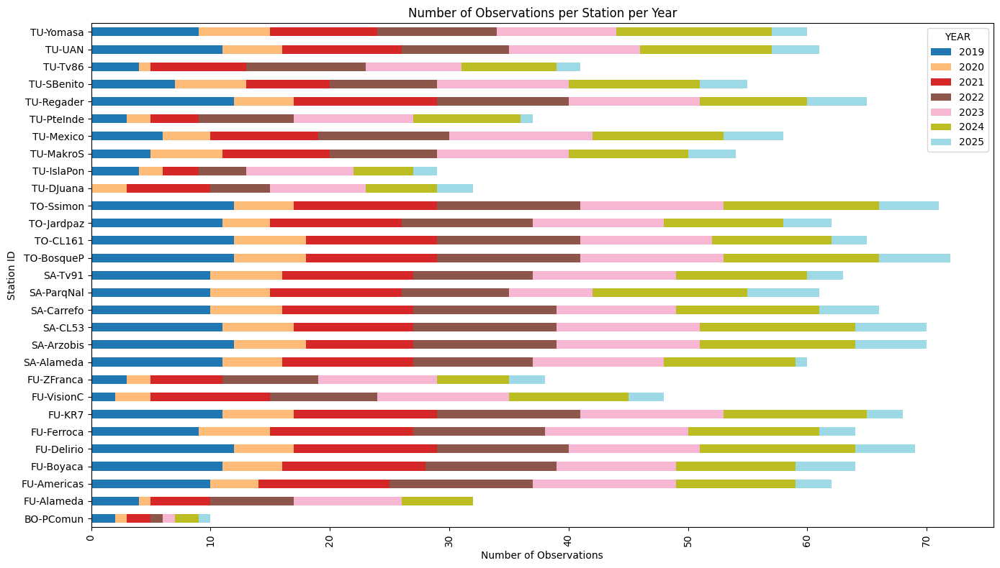

<Figure size 640x480 with 0 Axes>

In [250]:

#df_joined['YEAR'] = df_joined['FECHA'].dt.year

# Group by 'ESTACIONID' and 'YEAR' to count observations per station per year
observations_per_station_per_year = df_joined.groupby(['ESTACIONID', 'YEAR']).size().unstack(fill_value=0)

print(observations_per_station_per_year.head())

# Plot the number of observations per station per year (stacked bar chart)
observations_per_station_per_year.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='tab20')

# Add chart title and labels
plt.title('Number of Observations per Station per Year')
plt.xlabel('Number of Observations')
plt.ylabel('Station ID')
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/observations_per_station_per_year.png")

### Statistical Distribution observations in-situ

       SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]  NITRÓGENO_TOTAL  FÓSFORO_TOTAL_[P]  \
count                        1607.000000      1607.000000        1607.000000   
mean                           51.428015        17.168987           1.744934   
std                            49.930136        16.813539           1.854577   
min                             4.000000         0.477000           0.046000   
25%                            12.000000         3.295500           0.261500   
50%                            34.000000        11.630000           0.940000   
75%                            77.000000        24.907000           2.782500   
max                           235.000000        69.310000           7.560000   

         DQO_TOTAL  
count  1607.000000  
mean    108.731346  
std     113.621760  
min       5.000000  
25%      21.000000  
50%      58.000000  
75%     171.000000  
max     497.000000  


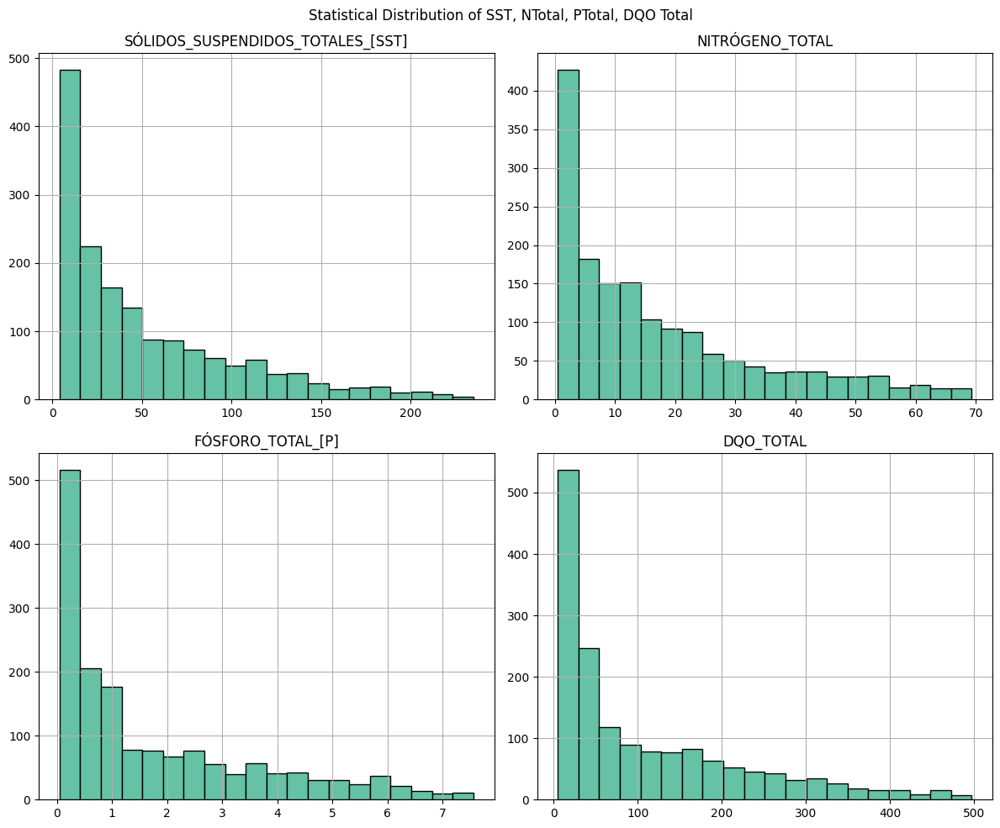

<Figure size 640x480 with 0 Axes>

In [251]:
# List of columns for which we want the statistical distribution
columns_of_interest = [
    'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]',
    'NITRÓGENO_TOTAL',
    'FÓSFORO_TOTAL_[P]',
    'DQO_TOTAL'
]

# Get descriptive statistics
stats = df_joined[columns_of_interest].describe()

print(stats)

# Visualize the distribution of each of the columns
df_joined[columns_of_interest].hist(figsize=(12, 10), bins=20 ,edgecolor='black')
plt.suptitle('Statistical Distribution of SST, NTotal, PTotal, DQO Total')
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/statistical_distribution_of_variables.png")



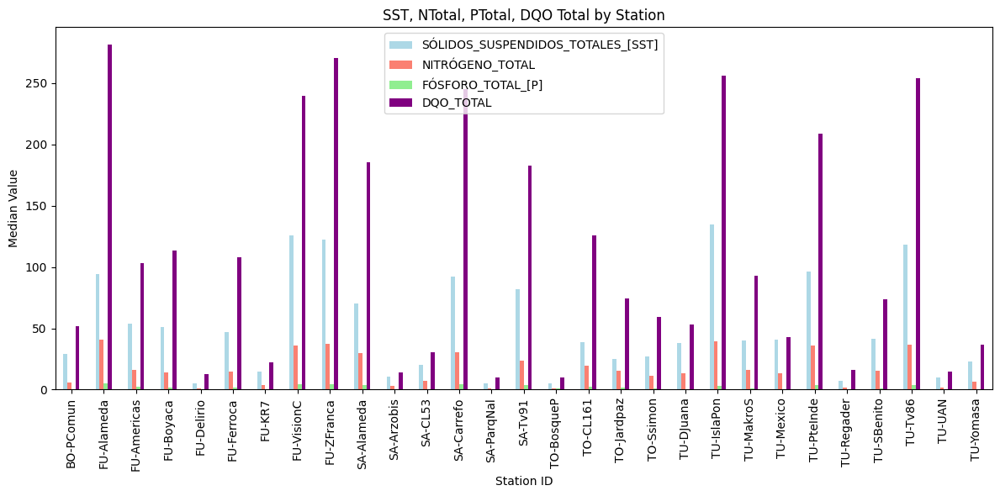

,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],NITRÓGENO_TOTAL,FÓSFORO_TOTAL_[P],DQO_TOTAL
ESTACIONID,,,,
BO-PComun,29.00,6.1420,0.4550,51.50
FU-Alameda,94.00,40.7290,5.2450,281.50
FU-Americas,54.00,16.3070,2.0740,103.00
FU-Boyaca,51.00,13.7630,1.6910,113.50
FU-Delirio,5.00,1.2070,0.0500,13.00
FU-Ferroca,47.00,14.7070,1.5250,108.00
FU-KR7,15.00,3.6910,0.4300,22.00
FU-VisionC,126.00,35.8070,4.4250,239.50
FU-ZFranca,122.50,37.0070,4.2700,270.50


<Figure size 640x480 with 0 Axes>

In [252]:
# Group by station and calculate median for each measurement
df_station_stats = df_joined.groupby('ESTACIONID')[columns_of_interest].median()

# Plotting each variable by station
df_station_stats.plot(kind='bar', figsize=(12, 6), color=['lightblue', 'salmon', 'lightgreen', 'purple'])
plt.title('SST, NTotal, PTotal, DQO Total by Station')
plt.xlabel('Station ID')
plt.ylabel('Median Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/statistical_distribution_of_variables_by_station.png")
df_station_stats



How are these variables correlated?


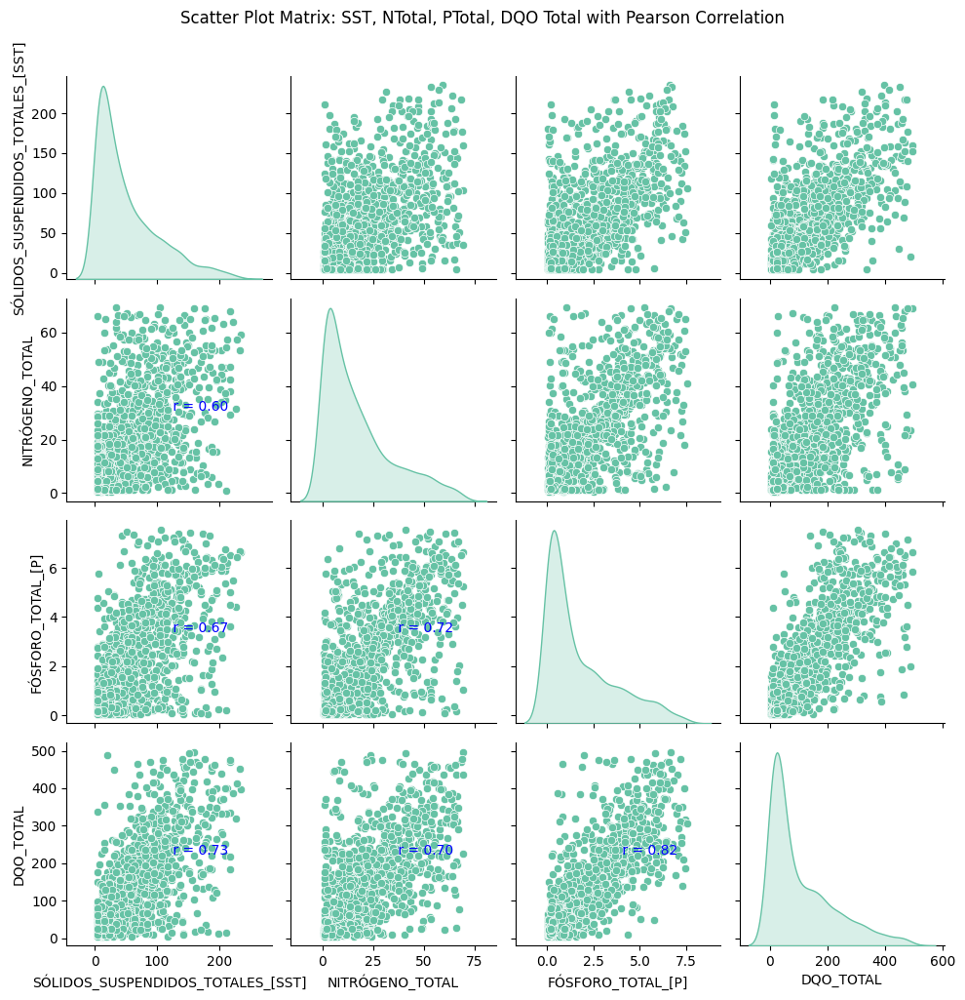

<Figure size 640x480 with 0 Axes>

In [253]:
# List of columns to plot
columns_of_interest = [
    'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]',
    'NITRÓGENO_TOTAL',
    'FÓSFORO_TOTAL_[P]',
    'DQO_TOTAL'
]

# Create the scatter plot matrix (pairplot) using seaborn
pairplot = sns.pairplot(df_joined[columns_of_interest], kind='scatter', markers='o', diag_kind='kde', height=2.5)

# Calculate the Pearson correlation matrix for the selected columns
corr_matrix = df_joined[columns_of_interest].corr()
corr_matrix
# Loop through each scatter plot in the pairplot and add the coefficient
for i, j in zip(*np.tril_indices_from(corr_matrix, -1)):
    ax = pairplot.axes[i, j]
    corr_value = corr_matrix.iloc[i, j]

    # Add Pearson correlation coefficient in each scatter plot
    ax.annotate(f' r = {corr_value:.2f}',
                (0.5, 0.5), textcoords='axes fraction', ha='left', va='top', fontsize=10, color='blue')


plt.suptitle('Scatter Plot Matrix: SST, NTotal, PTotal, DQO Total with Pearson Correlation', y=1.02)

#the plot
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/scatter_plot_matrix_with_correlation.png")


###MAPS of the variable levels on the river stations

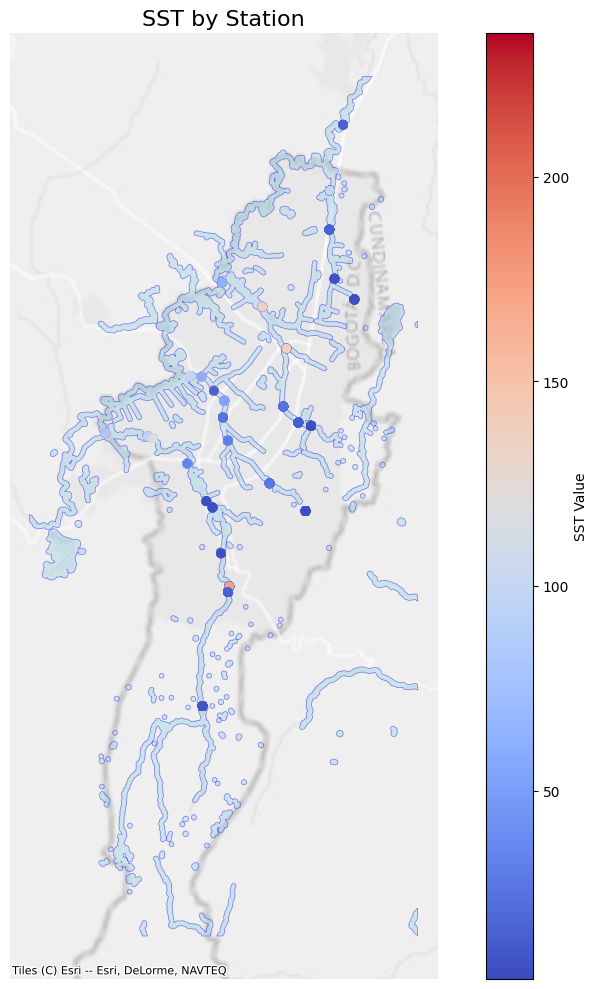

<Figure size 640x480 with 0 Axes>

In [254]:

#shapefile of river

raoi=dir+"/AOI_DS.shp"
df_aoi=gpd.read_file(raoi)
bw_bta=dir+"/BodyWater_BTA.shp"
bw_bta=gpd.read_file(bw_bta)
#clip by aoi
bw_btacl=bw_bta.clip(df_aoi)

if bw_btacl.crs != gdf.crs:
 bw_btacl = bw_btacl.to_crs(gdf.crs)

# Plotting the GeoDataFrame with the selected variable (SST)
fig, ax = plt.subplots(figsize=(10, 10))
bw_btacl.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', linewidth=0.5)
# Plot stations with color based on SST values
gdf.plot(column="SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]",
         ax=ax,
         legend=True,
         cmap="coolwarm",
         legend_kwds={'label': "SST Value",
                     'orientation': "vertical"})




# Add basemap
cx.add_basemap(ax,
               crs=bw_btacl.crs,
               source=cx.providers.Esri.WorldGrayCanvas)

# Remove axis labels and ticks
ax.set_axis_off()

# Title
ax.set_title("SST by Station", fontsize=16)

# Display the plot with the basemap and color scale
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/map_sst_by_station.png")

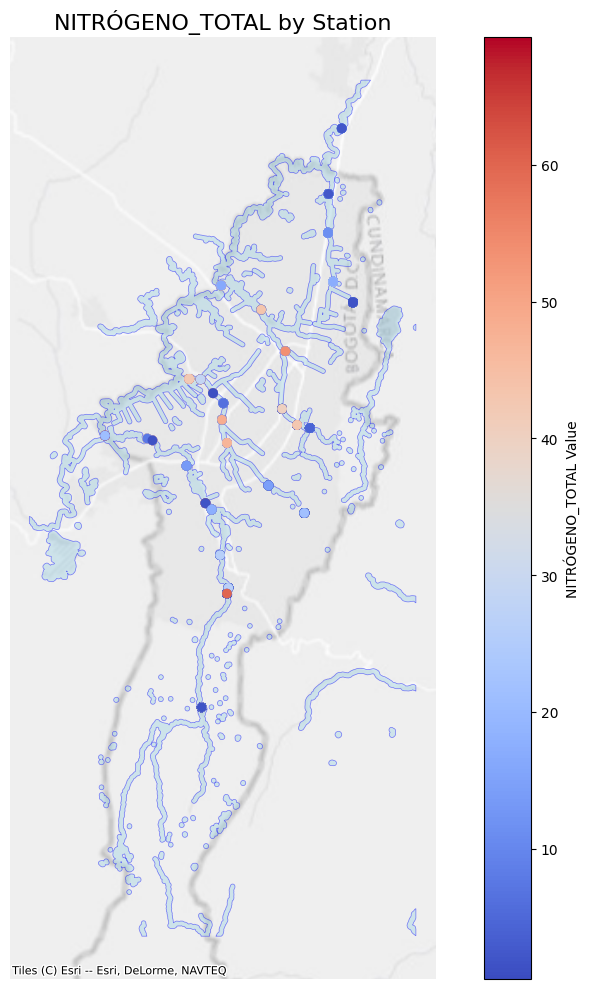

<Figure size 640x480 with 0 Axes>

In [255]:
# Plotting the GeoDataFrame with the selected variable (NITRÓGENO_TOTAL)
fig, ax = plt.subplots(figsize=(10, 10))

#shapefile
bw_btacl.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', linewidth=0.5)

# Plot stations with color based on NITRÓGENO_TOTAL values
gdf.plot(column="NITRÓGENO_TOTAL",
         ax=ax,
         legend=True,
         cmap="coolwarm",
         legend_kwds={'label': "NITRÓGENO_TOTAL Value",
                      'orientation': "vertical"})

# Add basemap
cx.add_basemap(ax,
               crs=bw_btacl.crs,
               source=cx.providers.Esri.WorldGrayCanvas)

# Remove axis labels and ticks
ax.set_axis_off()

# Add title
ax.set_title("NITRÓGENO_TOTAL by Station", fontsize=16)

# Display the plot with the basemap and color scale
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/map_nitr_by_station.png")

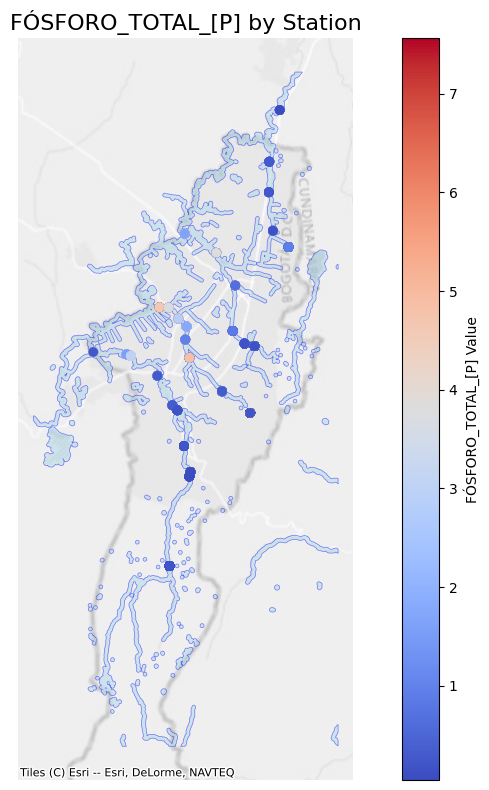

<Figure size 640x480 with 0 Axes>

In [256]:
# Plotting the GeoDataFrame with the selected variable (FÓSFORO_TOTAL_[P])
fig, ax = plt.subplots(figsize=(10, 8))

#shapefile
bw_btacl.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', linewidth=0.5)

# Plot stations with color based on FÓSFORO_TOTAL_[P] values
gdf.plot(column="FÓSFORO_TOTAL_[P]",
         ax=ax,
         legend=True,
         cmap="coolwarm",
         legend_kwds={'label': "FÓSFORO_TOTAL_[P] Value",
                      'orientation': "vertical"})

# Add basemap
cx.add_basemap(ax,
               crs=bw_btacl.crs,
               source=cx.providers.Esri.WorldGrayCanvas)


ax.set_axis_off()

ax.set_title("FÓSFORO_TOTAL_[P] by Station", fontsize=16)

plt.tight_layout()
plt.show()
plt.savefig(output_path+"/map_fosforo_by_station.png")

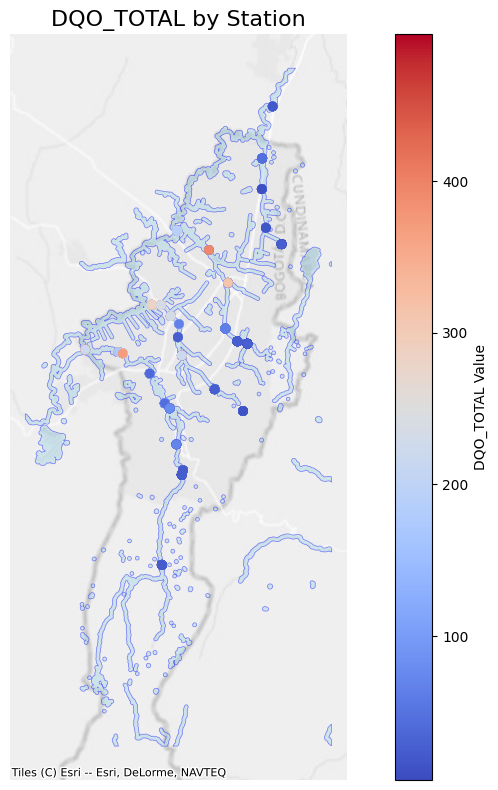

<Figure size 640x480 with 0 Axes>

In [257]:
# Plotting the GeoDataFrame with the selected variable (DQO_TOTAL)
fig, ax = plt.subplots(figsize=(10, 8))

#shapefile
bw_btacl.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', linewidth=0.5)

# Plot stations with color based on DQO_TOTAL values
gdf.plot(column="DQO_TOTAL",
         ax=ax,
         legend=True,
         cmap="coolwarm",
         legend_kwds={'label': "DQO_TOTAL Value",
                      'orientation': "vertical"})

# Add basemap
cx.add_basemap(ax,
               crs=bw_btacl.crs,
               source=cx.providers.Esri.WorldGrayCanvas)


ax.set_axis_off()

ax.set_title("DQO_TOTAL by Station", fontsize=16)

plt.tight_layout()
plt.show()
plt.savefig(output_path+"/map_dqo_by_station.png")

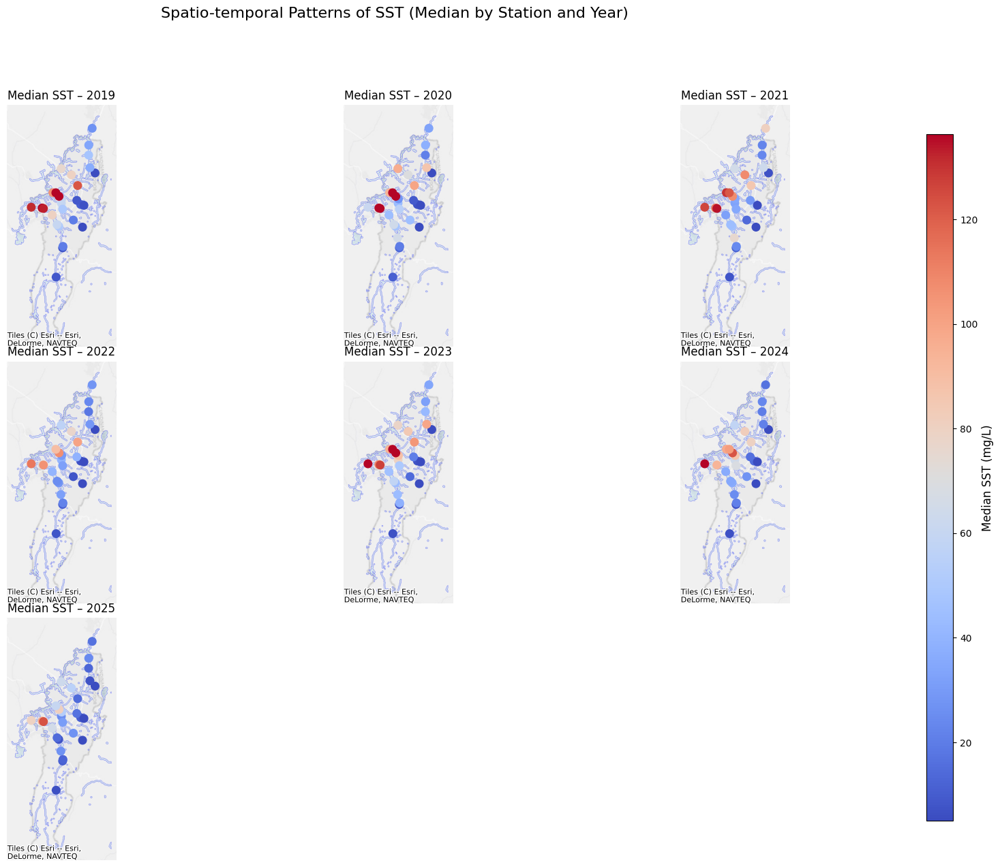

<Figure size 640x480 with 0 Axes>

In [258]:

SST_COL = "SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]"
YEAR_COL = "YEAR"
gdf[YEAR_COL] = pd.to_datetime(gdf['FECHA']).dt.year
years = sorted(gdf[YEAR_COL].dropna().unique())  # Get unique years
years = [int(y) for y in years]

nrows, ncols = 3, 3
max_panels = nrows * ncols
years = years[:max_panels]


# Compute median SST per station per year
gdf_year = (
    gdf.dropna(subset=[SST_COL])
       .groupby(["ESTACIONID", YEAR_COL], as_index=False)[SST_COL]
       .median()  # Using median instead of mean
)

stations_geom = gdf[["ESTACIONID", "geometry"]].drop_duplicates("ESTACIONID")

gdf_year = gdf_year.merge(stations_geom, on="ESTACIONID", how="left")
gdf_year = gdf_year.set_geometry("geometry", crs=gdf.crs)

vmin = gdf_year[SST_COL].quantile(0.05)
vmax = gdf_year[SST_COL].quantile(0.95)


# Create subplots
fig_w = 6.5 * ncols
fig_h = 4.8 * nrows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))
axes = axes.flatten()

cmap = plt.cm.coolwarm
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Loop through each year and create a map for each year
for i, year in enumerate(years):
    ax = axes[i]

    # Base polygon for the river/water bodies (Body Water BTA layer)
    bw_btacl.plot(ax=ax, color='lightblue', alpha=0.35, edgecolor='blue', linewidth=0.5)

    # Filter the data for that year
    sub = gdf_year[gdf_year[YEAR_COL] == year]

    # Plot stations with median SST for each year
    sub.plot(
        column=SST_COL,
        ax=ax,
        cmap=cmap,
        norm=norm,
        markersize=70,
        legend=False,
        zorder=3
    )

    # Add basemap
    cx.add_basemap(ax, crs=gdf.crs, source=cx.providers.Esri.WorldGrayCanvas, alpha=0.9, zorder=0)
    ax.set_title(f"Median SST – {year}", fontsize=12)
    ax.set_axis_off()  # Remove axis labels and ticks

# Hide unused panels if there are fewer than 12 years
for j in range(i + 1, max_panels):
  axes[j].set_visible(False)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Leave space at right for colorbar
fig.subplots_adjust(right=0.88, wspace=0.02, hspace=0.06)

cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Median SST (mg/L)", fontsize=12)

# Optional overall title
fig.suptitle("Spatio-temporal Patterns of SST (Median by Station and Year)", fontsize=16, y=0.98)

plt.show()

plt.savefig(output_path+"/map_sst_by_station_year.png")

Generating maps for: SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]


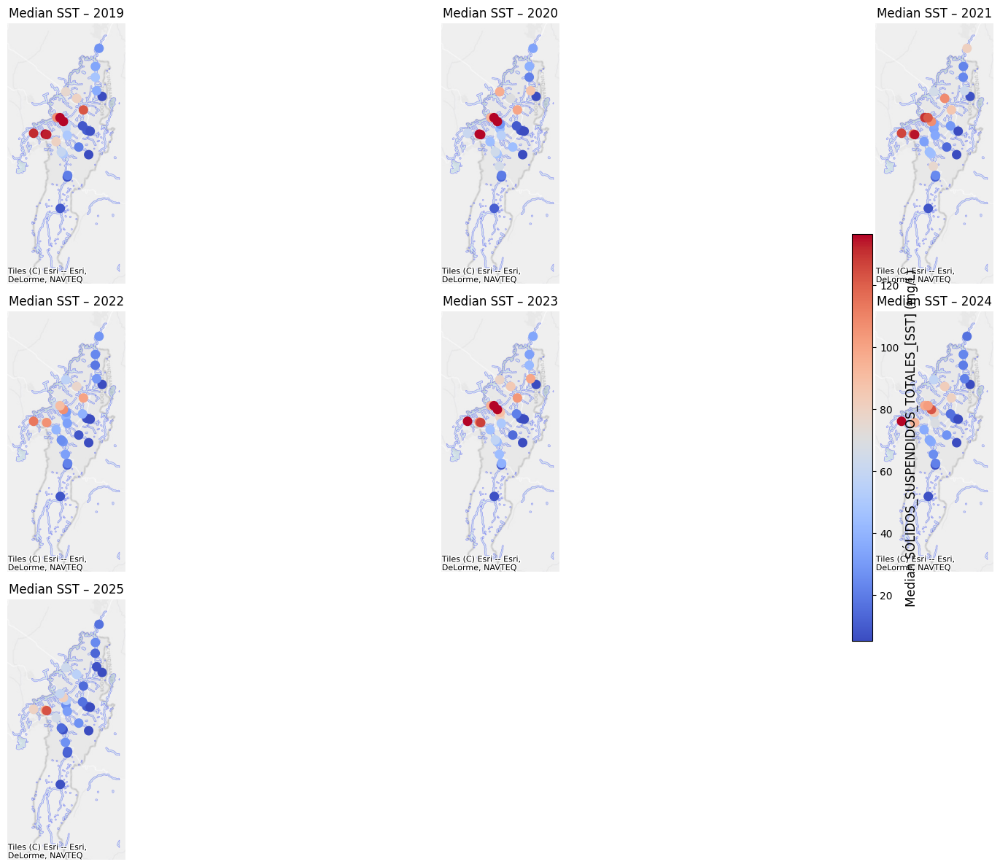

Generating maps for: NITRÓGENO_TOTAL


<Figure size 640x480 with 0 Axes>

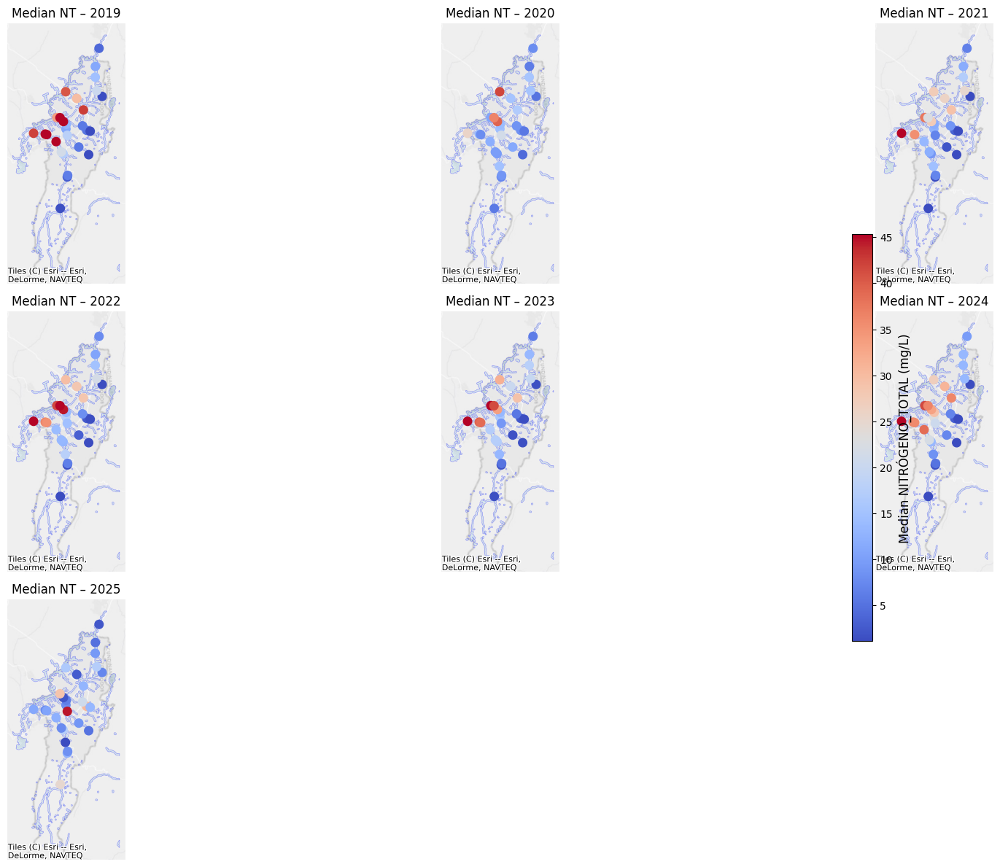

Generating maps for: FÓSFORO_TOTAL_[P]


<Figure size 640x480 with 0 Axes>

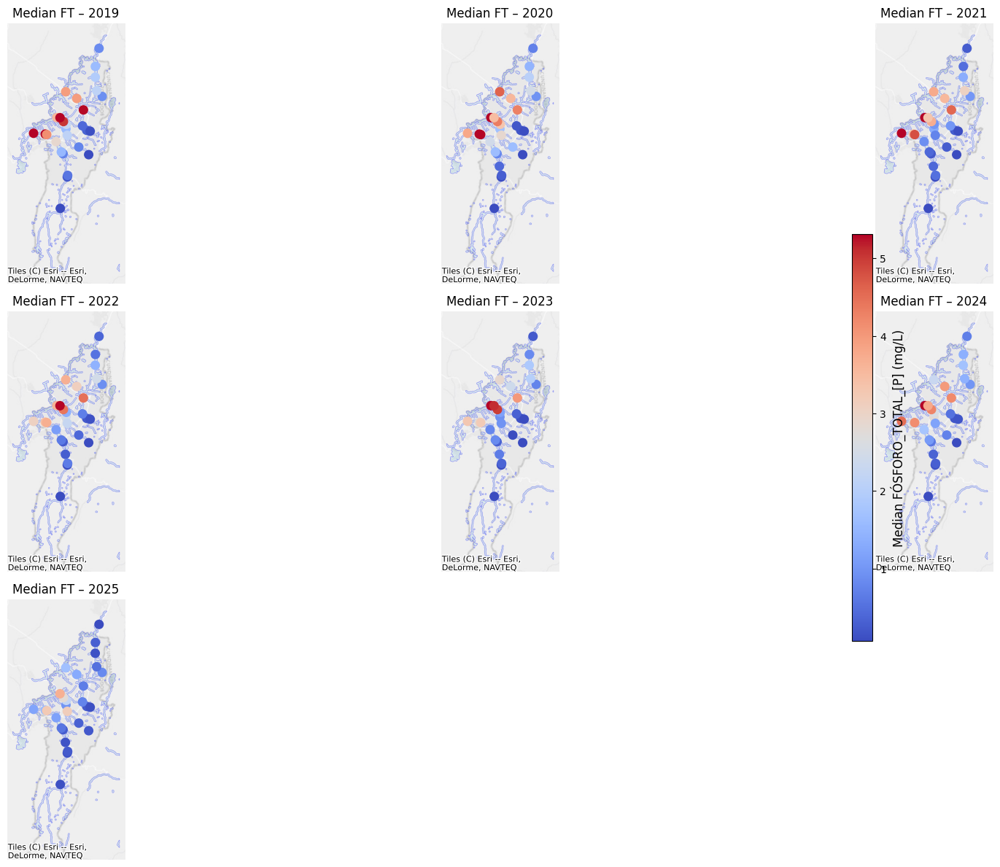

Generating maps for: DQO_TOTAL


<Figure size 640x480 with 0 Axes>

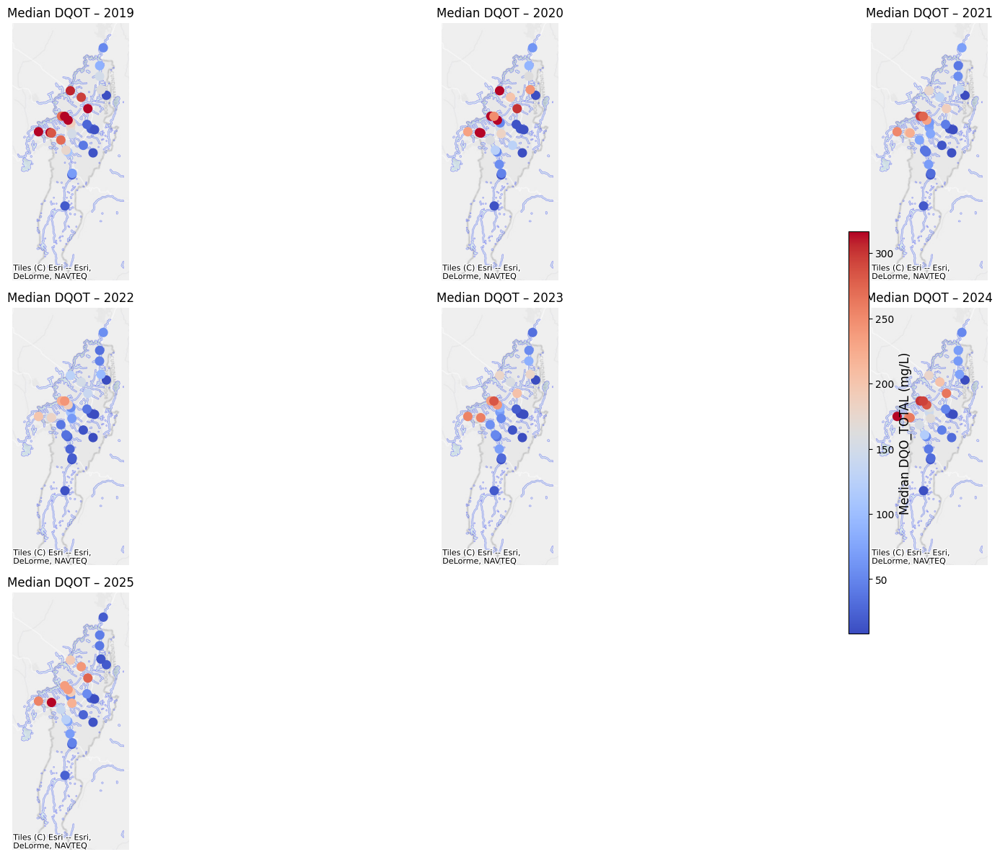

<Figure size 640x480 with 0 Axes>

In [259]:
# List of variables to plot
variables_of_interest = [
    "SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]",
    "NITRÓGENO_TOTAL",
    "FÓSFORO_TOTAL_[P]",
    "DQO_TOTAL"
]
targetrm = {'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]':'SST', 'NITRÓGENO_TOTAL':'NT', 'FÓSFORO_TOTAL_[P]':'FT','DQO_TOTAL':'DQOT'}
# Loop through each variable and create maps
for var in variables_of_interest:
    print(f"Generating maps for: {var}")

    # Compute median per station per year for the current variable

    gdf_year = (
        gdf.dropna(subset=[var])
           .groupby(["ESTACIONID", "YEAR"], as_index=False)[var]
           .median()  # Using median instead of mean
    )

    # Bring geometry back (one geometry per station)
    stations_geom = gdf[["ESTACIONID", "geometry"]].drop_duplicates("ESTACIONID")
    gdf_year = gdf_year.merge(stations_geom, on="ESTACIONID", how="left")
    gdf_year = gdf_year.set_geometry("geometry", crs=gdf.crs)

    # Use a common color scale across all years

    vmin = gdf_year[var].quantile(0.05)  # 5th percentile for lower bound
    vmax = gdf_year[var].quantile(0.95)  # 95th percentile for upper bound

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 12))
    axes = axes.flatten()

    # Loop through each year and create a map for each year
    for i, year in enumerate(years):
        ax = axes[i]

        # Base polygon for the river/water bodies (Body Water BTA layer)
        bw_btacl.plot(ax=ax, color='lightblue', alpha=0.35, edgecolor='blue', linewidth=0.5)

        # Filter the data for that year
        sub = gdf_year[gdf_year["YEAR"] == year]

        # Plot stations with median values for the selected variable
        sm = sub.plot(
            column=var,
            ax=ax,
            cmap="coolwarm",  # Color map
            vmin=vmin,
            vmax=vmax,
            markersize=70,
            legend=False  # We will add a shared colorbar later
        )

        # Add basemap
        cx.add_basemap(ax, crs=gdf.crs, source=cx.providers.Esri.WorldGrayCanvas)

        ax.set_axis_off()  # Remove axis labels and ticks
        ax.set_title(f"Median {targetrm[var]} – {year}", fontsize=12)

    # Hide unused panels if there are fewer than 12 years
    for j in range(i + 1, max_panels):
        axes[j].set_visible(False)

    # Add a shared colorbar for all maps
    smappable = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    smappable.set_array([])  # Set an empty array for colorbar mapping
    cbar = fig.colorbar(smappable, ax=axes, orientation="vertical", fraction=0.02, pad=0.01)
    cbar.set_label(f"Median {var} (mg/L)", fontsize=12)

    # Adjust the layout to avoid overlap
    plt.tight_layout()
    plt.show()
    plt.savefig(output_path+"/map_sst_by_station_year_"+targetrm[var]+".png")


Which stations are suitable for trend analysis?

In [260]:
# Filter stations with more than 10 observations
valid_stations = observations_per_station[observations_per_station > 10].index

# Filter dataset to only include those stations
df_valid_stations = df_joined[df_joined['ESTACIONID'].isin(valid_stations)]

# Group by station and check if we have enough variation in data (e.g., standard deviation > threshold)
df_valid_station_trends = df_valid_stations.groupby('ESTACIONID')[columns_of_interest].std()
df_valid_station_trends = df_valid_station_trends[df_valid_station_trends > 5]  # arbitrary threshold

# List of stations suitable for trend analysis
valid_stations_for_trend = df_valid_station_trends.index

# Show the suitable stations for trend analysis
print("Stations suitable for trend analysis:", valid_stations_for_trend)


Stations suitable for trend analysis: Index(['FU-Alameda', 'FU-Americas', 'FU-Boyaca', 'FU-Delirio', 'FU-Ferroca',
       'FU-KR7', 'FU-VisionC', 'FU-ZFranca', 'SA-Alameda', 'SA-Arzobis',
       'SA-CL53', 'SA-Carrefo', 'SA-ParqNal', 'SA-Tv91', 'TO-BosqueP',
       'TO-CL161', 'TO-Jardpaz', 'TO-Ssimon', 'TU-DJuana', 'TU-IslaPon',
       'TU-MakroS', 'TU-Mexico', 'TU-PteInde', 'TU-Regader', 'TU-SBenito',
       'TU-Tv86', 'TU-UAN', 'TU-Yomasa'],
      dtype='object', name='ESTACIONID')


###Stations' time series (SST)

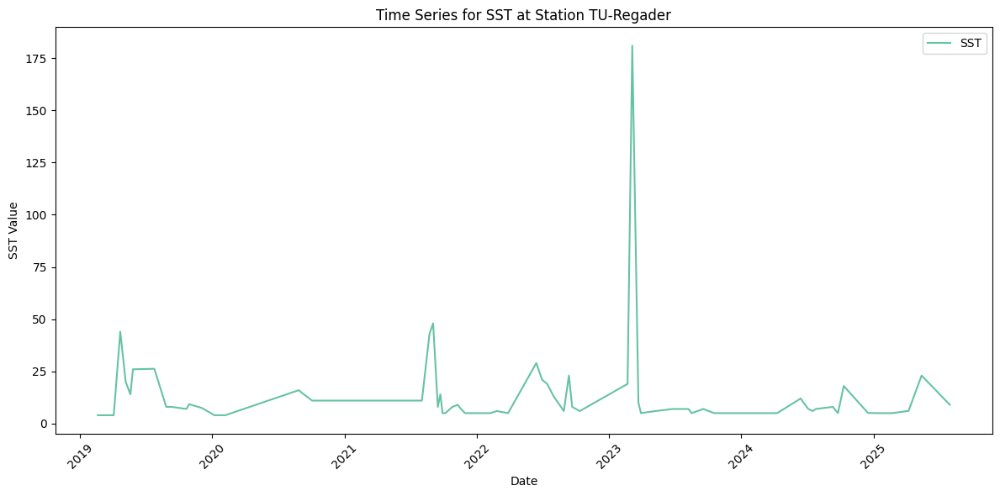

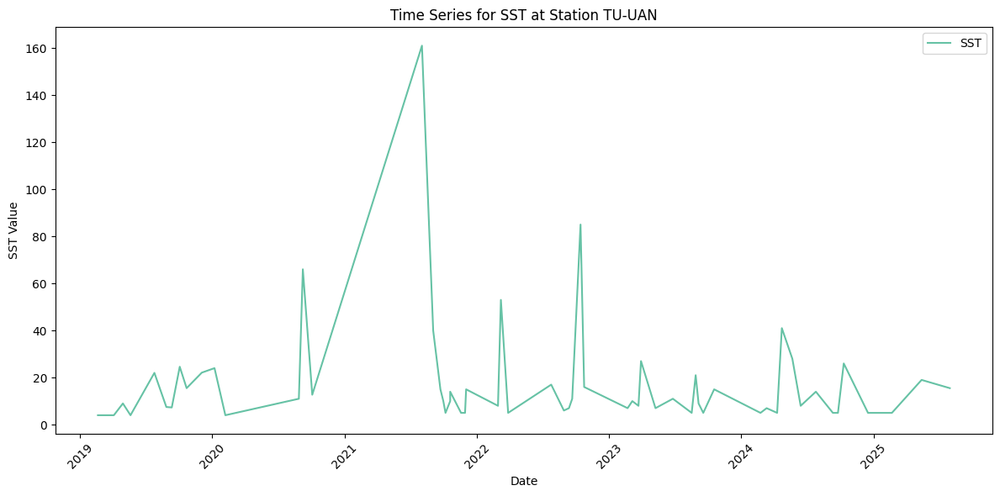

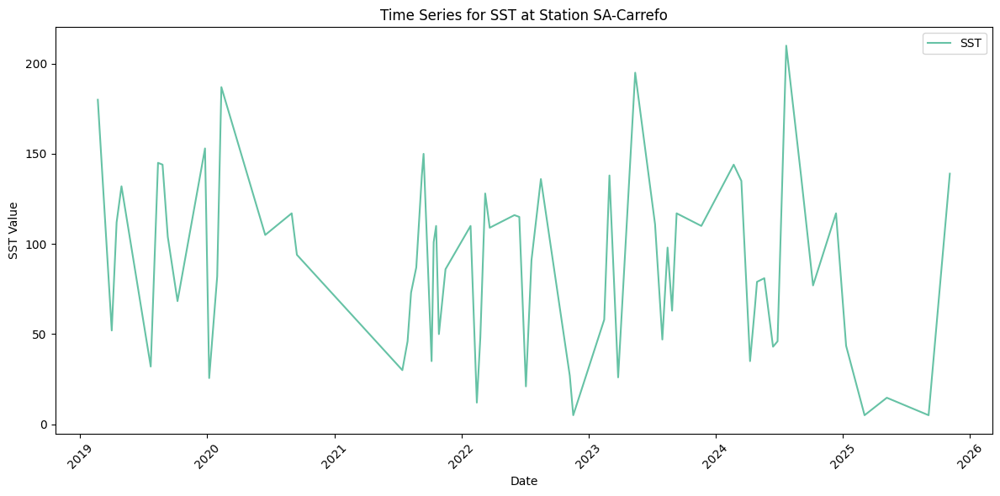

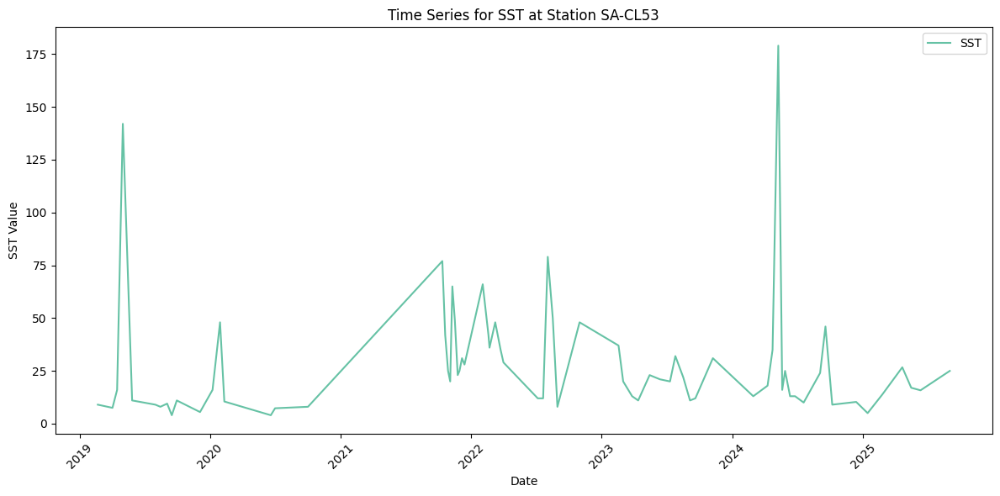

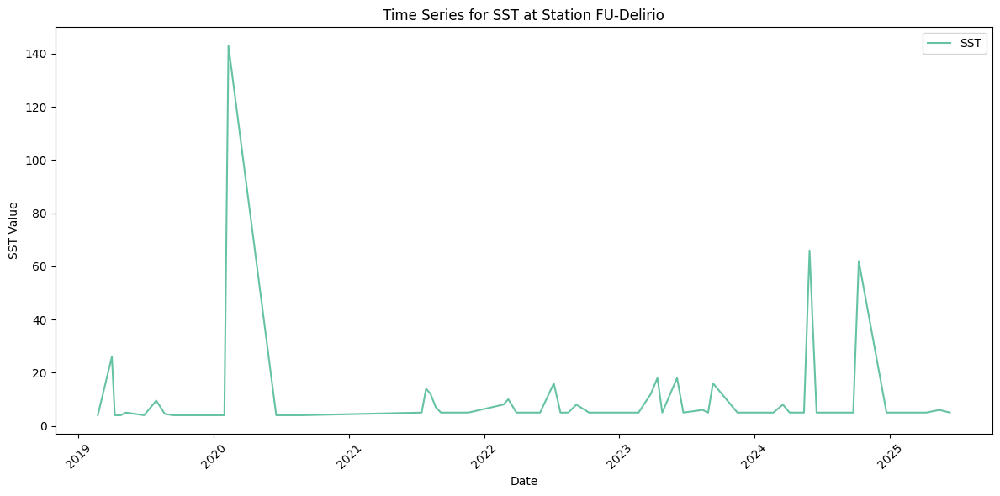

...

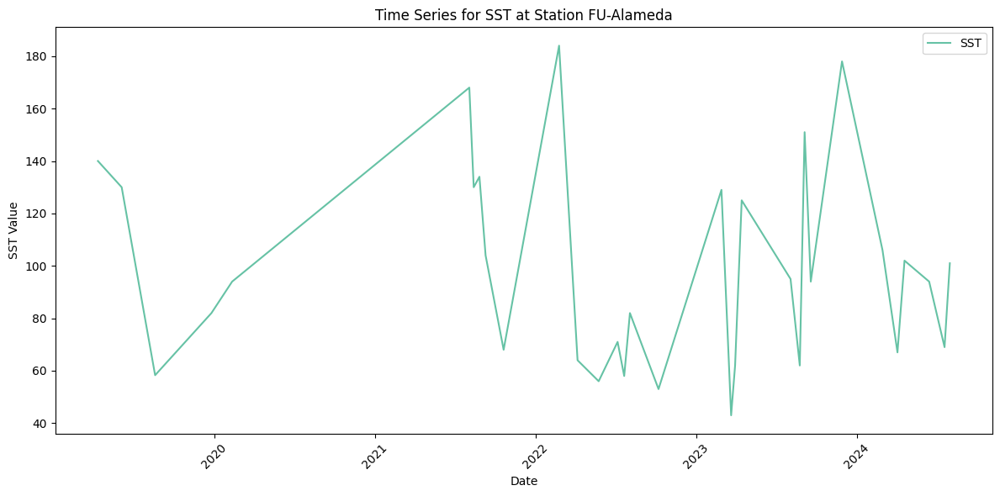

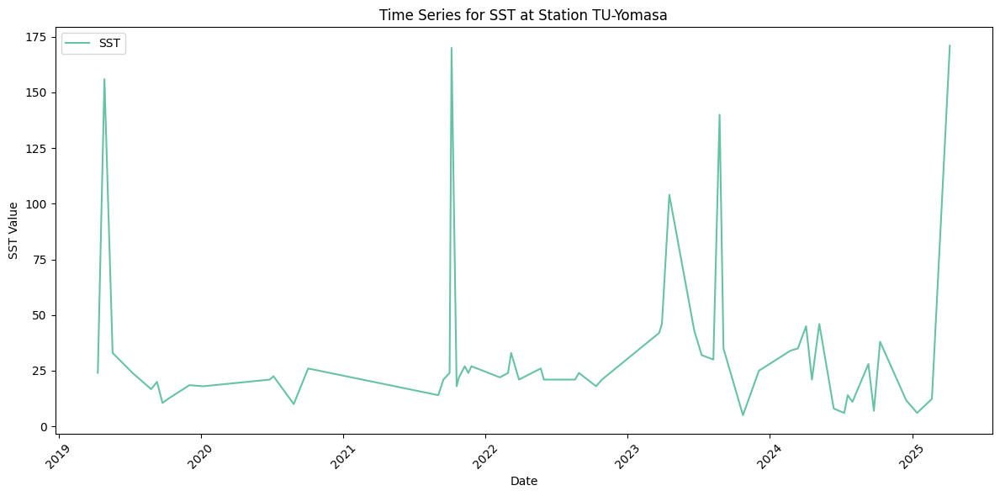

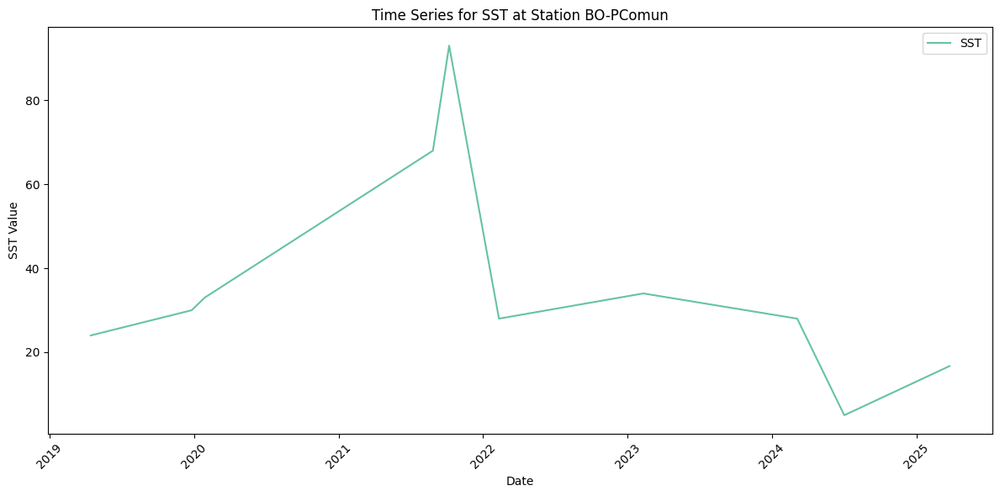

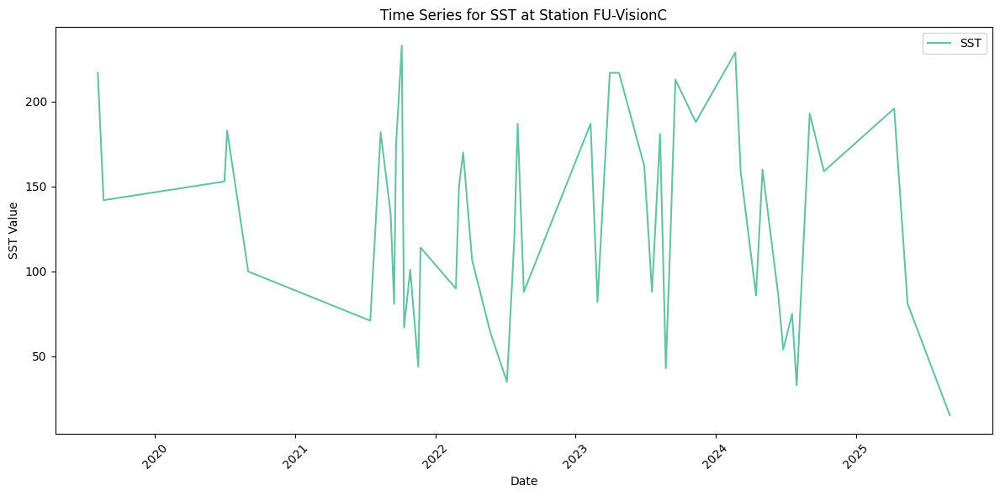

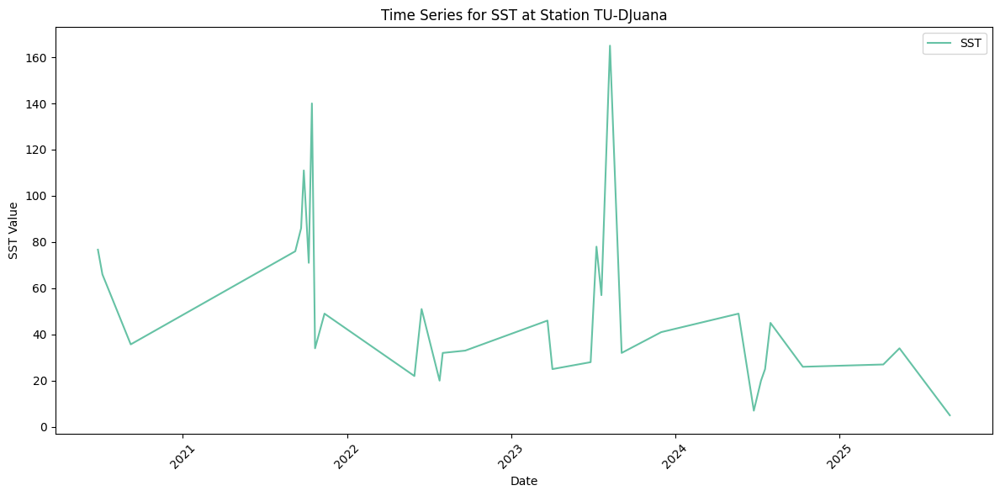

In [261]:
from IPython.display import display, clear_output
import time

# List of unique station IDs
station_ids = df_joined['ESTACIONID'].unique()

# Iterate over each station and plot the time series
for station_id in station_ids:
    # Filter the data for the current station
    df_station_time_series = df_joined[df_joined['ESTACIONID'] == station_id]

    # Create the time series plot for SST at the given station
    plt.figure(figsize=(12, 6))
    plt.plot(df_station_time_series['FECHA'], df_station_time_series['SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]'], label='SST')
    plt.title(f"Time Series for SST at Station {station_id}")
    plt.xlabel('Date')
    plt.ylabel('SST Value')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    # Display the plot as a slide
    display(plt.gcf())


    time.sleep(5)

    # Clear the output before displaying the next station's plot
    clear_output(wait=True)


### Analysis Bar Chart, Histograms, Scatterplot Data Insitu-Images

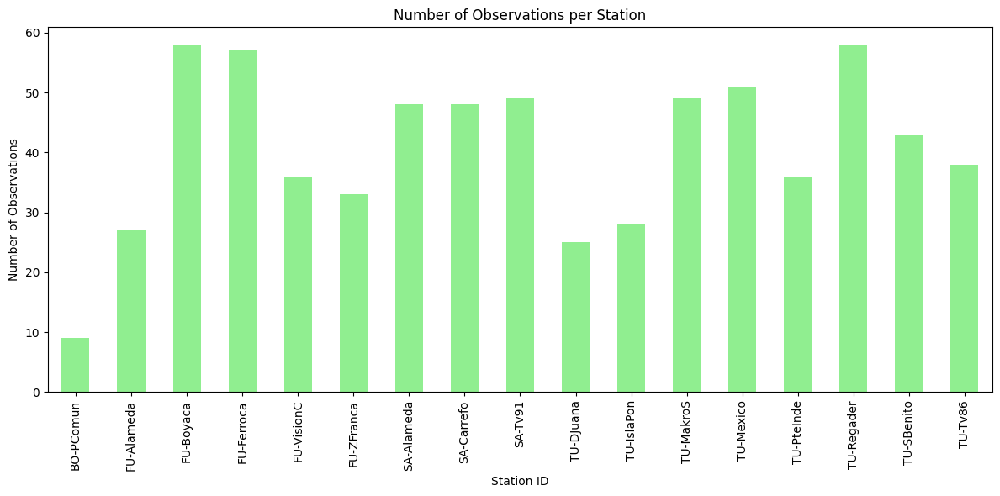

,0
ESTACIONID,
BO-PComun,9
FU-Alameda,27
FU-Boyaca,58
FU-Ferroca,57
FU-VisionC,36
FU-ZFranca,33
SA-Alameda,48
SA-Carrefo,48
SA-Tv91,49


<Figure size 640x480 with 0 Axes>

In [262]:
# Number of observations per station
observations_per_station = df_full_filtered.groupby('ESTACIONID').size()

# Plot number of observations per station
observations_per_station.plot(kind='bar', figsize=(12, 6), color='lightgreen')
plt.title('Number of Observations per Station')
plt.xlabel('Station ID')
plt.ylabel('Number of Observations')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/number_of_observations_per_station_fil.png")
observations_per_station

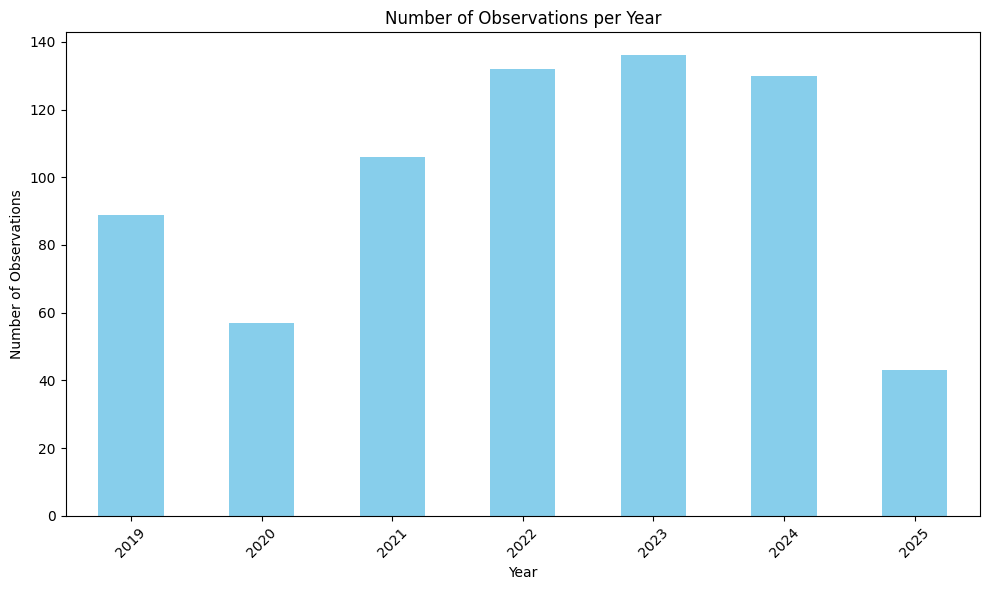

,0
YEAR,
2019,89
2020,57
2021,106
2022,132
2023,136
2024,130
2025,43


<Figure size 640x480 with 0 Axes>

In [263]:
# Group by year and count the number of observations
# Convert 'FECHA' to datetime explicitly
df_full_filtered['FECHA'] = pd.to_datetime(df_full_filtered['FECHA'])
df_full_filtered['YEAR'] = df_full_filtered['FECHA'].dt.year

# Number of observations per year
observations_per_year = df_full_filtered.groupby('YEAR').size()

# Plot the number of observations per year
observations_per_year.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/number_of_observations_per_year_fil.png")
observations_per_year

YEAR         2019  2020  2021  2022  2023  2024  2025
ESTACIONID                                           
BO-PComun       2     1     2     1     1     2     1
FU-Alameda      4     1     5     7     9     6     0
FU-Americas    10     4    11    12    12    10     3
FU-Boyaca      11     5    12    11    10    10     5
FU-Delirio     12     5    12    11    11    13     5


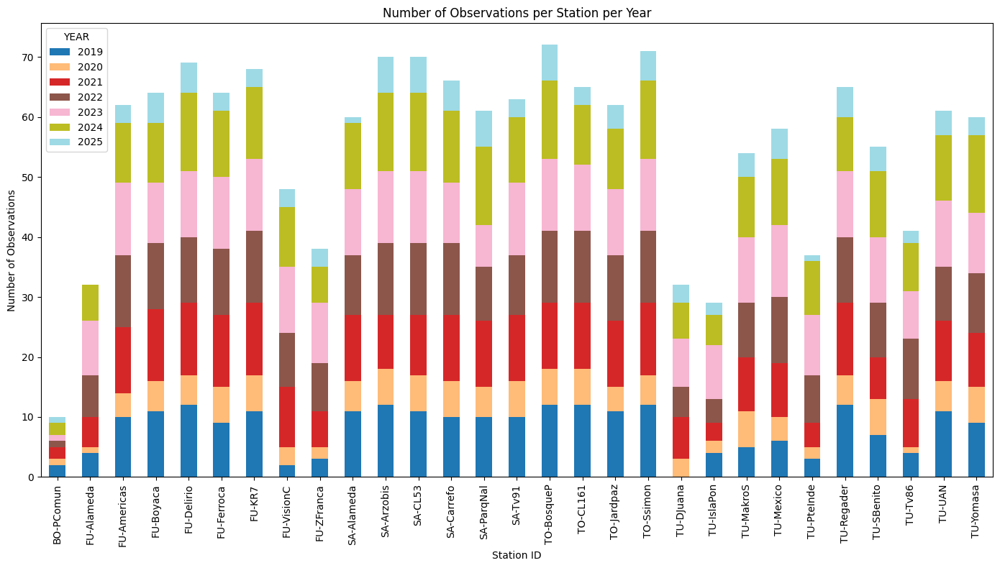

In [264]:
#for each station the number of obs per year
# Extract the year from 'FECHA' column if not already done
df_joined['YEAR'] = df_joined['FECHA'].dt.year

# Group by 'ESTACIONID' and 'YEAR' to count observations per station per year
observations_per_station_per_year = df_joined.groupby(['ESTACIONID', 'YEAR']).size().unstack(fill_value=0)

# Check the first few rows to ensure the data is correct
print(observations_per_station_per_year.head())

# Plot the number of observations per station per year (stacked bar chart)
observations_per_station_per_year.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

# Add chart title and labels
plt.title('Number of Observations per Station per Year')
plt.xlabel('Station ID')
plt.ylabel('Number of Observations')
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()


YEAR        2019  2020  2021  2022  2023  2024  2025
ESTACIONID                                          
BO-PComun      1     1     2     1     1     2     1
FU-Alameda     3     0     5     7     6     6     0
FU-Boyaca     11     4     9    10     9    10     5
FU-Ferroca     8     6    12    10    10     8     3
FU-VisionC     2     3     7     7     8     7     2
FU-ZFranca     3     2     5     7     8     6     2
SA-Alameda    10     5     8     9     6     9     1
SA-Carrefo     6     6     4    10     7    10     5
SA-Tv91        7     6     9     8     8     9     2
TU-DJuana      0     3     2     5     7     6     2
TU-IslaPon     4     2     2     4     9     5     2
TU-MakroS      5     5     7     9    10    10     3
TU-Mexico      6     4     9    10    10     8     4
TU-PteInde     3     2     4     7    10     9     1
TU-Regader    11     3    11    10    11     7     5
TU-SBenito     6     4     2     8     9    11     3
TU-Tv86        3     1     8    10     7     7

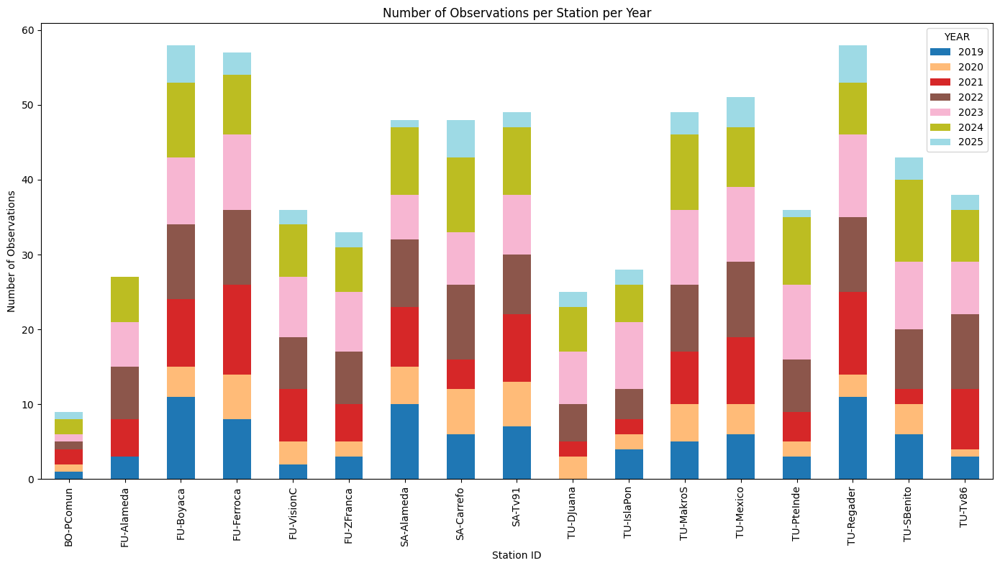

<Figure size 640x480 with 0 Axes>

In [265]:
# Group by 'ESTACIONID' and 'YEAR' to count observations per station per year
observations_per_station_per_year = df_full_filtered.groupby(['ESTACIONID', 'YEAR']).size().unstack(fill_value=0)

# Check the first few rows to ensure the data is correct
print(observations_per_station_per_year)

# Plot the number of observations per station per year (stacked bar chart)
observations_per_station_per_year.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab20')

# Add chart title and labels
plt.title('Number of Observations per Station per Year')
plt.xlabel('Station ID')
plt.ylabel('Number of Observations')
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/number_of_observations_per_station_per_year_fil.png")

              B11         B12          B2          B3          B4          B5  \
count  693.000000  693.000000  693.000000  693.000000  693.000000  693.000000   
mean     0.105504    0.075352    0.056525    0.067470    0.064410    0.087030   
std      0.047782    0.038256    0.035318    0.034756    0.035965    0.037231   
min      0.002200    0.002400    0.000000    0.000000    0.000000    0.000000   
25%      0.073500    0.052000    0.038600    0.049200    0.044200    0.065400   
50%      0.110900    0.073900    0.049600    0.061500    0.060100    0.084500   
75%      0.135400    0.097800    0.062050    0.076000    0.074850    0.098700   
max      0.321700    0.337700    0.360400    0.348800    0.355600    0.392500   

               B6          B7          B8         B8A  ...        NDTI  \
count  693.000000  693.000000  693.000000  693.000000  ...  693.000000   
mean     0.123908    0.139614    0.112427    0.143338  ...   -0.033812   
std      0.055565    0.063736    0.058289    0.0

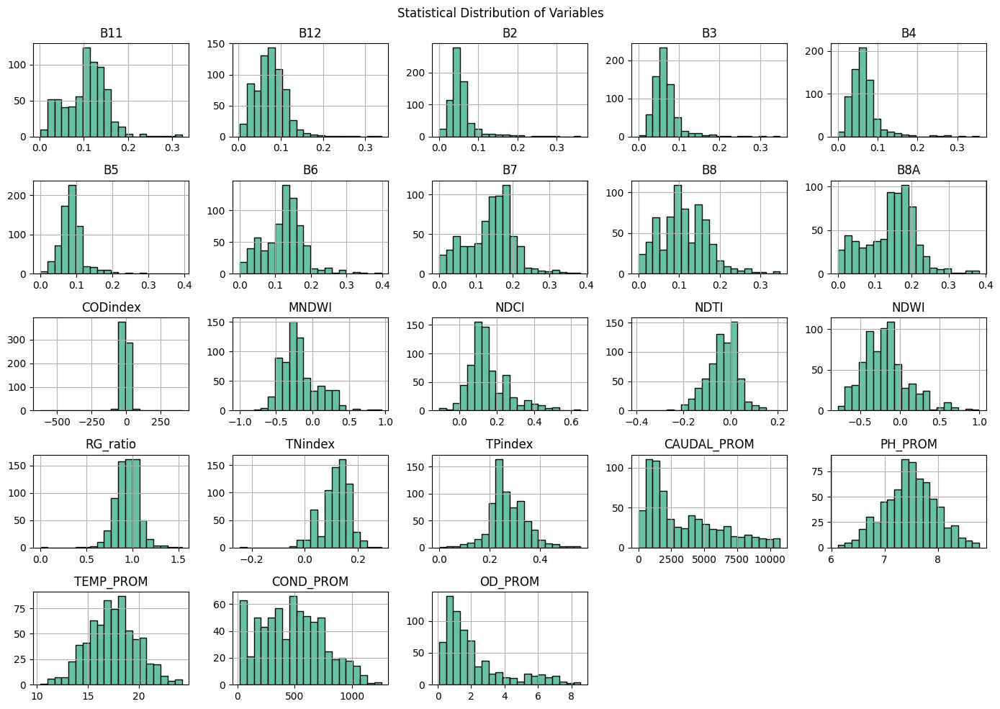

<Figure size 640x480 with 0 Axes>

In [266]:
# List of columns for which we want the statistical distribution
columns_of_interest = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
       'CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex','TPindex','CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM']

# Get descriptive statistics
stats = df_full_filtered[columns_of_interest].describe()

# Print the statistical distribution
print(stats)

# Visualize the distribution of each of the columns
df_full_filtered[columns_of_interest].hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.suptitle('Statistical Distribution of Variables')
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/statistical_distribution_variables_fil.png")

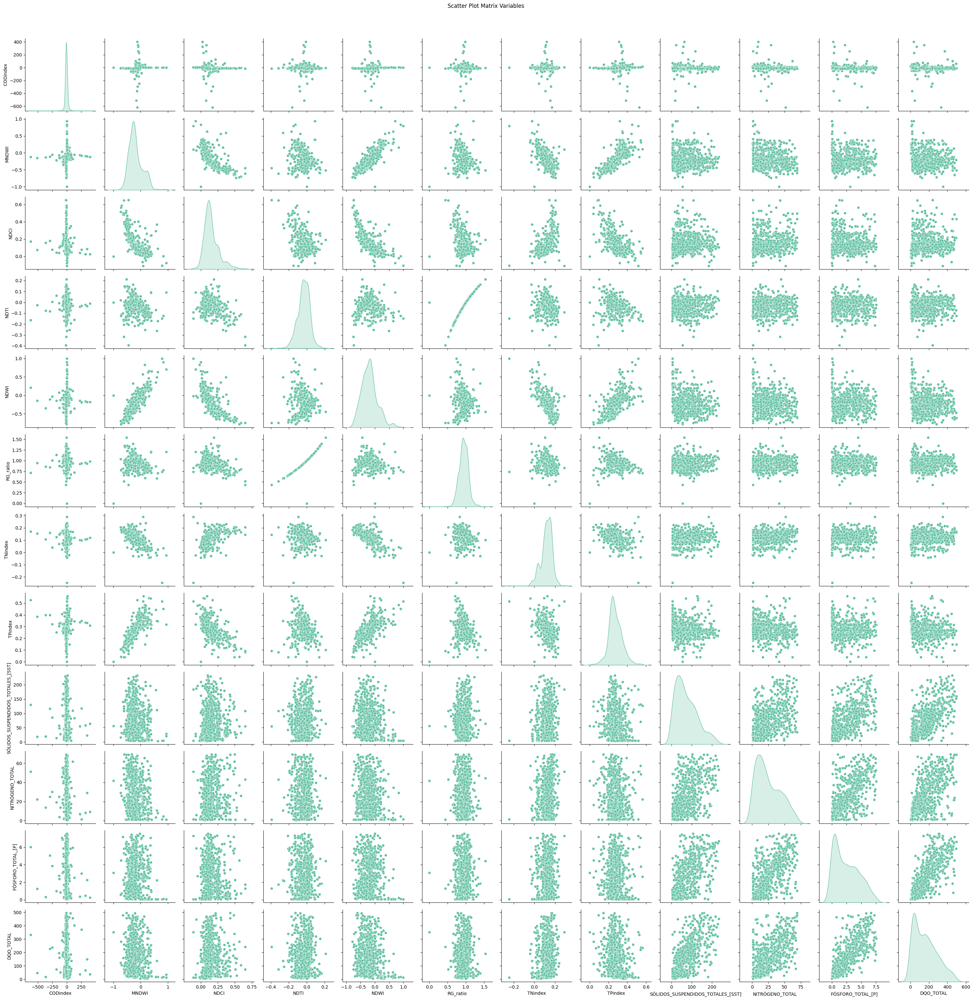

<Figure size 640x480 with 0 Axes>

In [267]:
# List of columns to plot
columns_of_interest = ['CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex','TPindex',
    'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]','NITRÓGENO_TOTAL', 'FÓSFORO_TOTAL_[P]','DQO_TOTAL']
#'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
# Scatter plot matrix (pair plot) to see the relationships between the variables
sns.pairplot(df_full_filtered[columns_of_interest], kind='scatter', markers='o', diag_kind='kde', height=2.5)

# Set plot title
plt.suptitle('Scatter Plot Matrix Variables', y=1.02)

# Display the plot
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/scatter_plot_matrix_variables_fil.png")

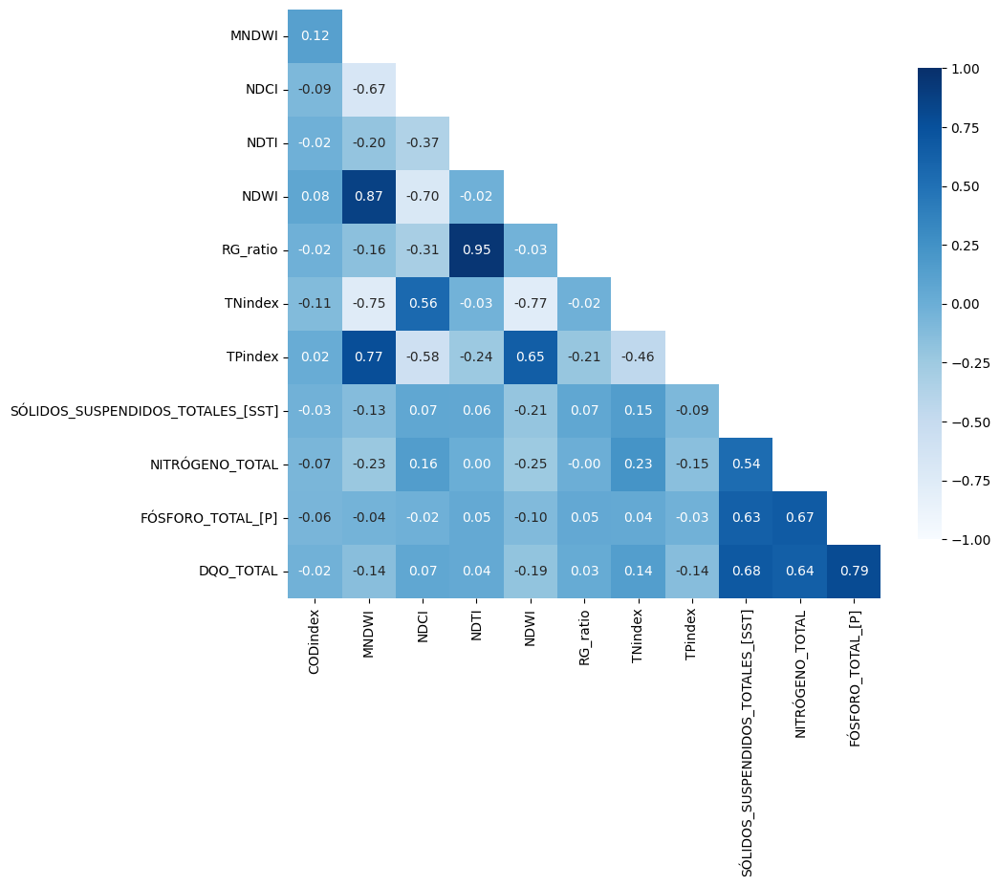

<Figure size 640x480 with 0 Axes>

In [268]:
# get correlations
columns_of_interest = ['CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex','TPindex',
    'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]','NITRÓGENO_TOTAL', 'FÓSFORO_TOTAL_[P]','DQO_TOTAL']
#'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
df_corr = df_full_filtered[columns_of_interest].corr()

fig, ax = plt.subplots(figsize=(10, 8))
# mask
mask = np.triu(np.ones_like(df_corr, dtype=np.bool))
# adjust mask and df
mask = mask[1:, :-1]
corr = df_corr.iloc[1:,:-1].copy()
# plot heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='Blues',
           vmin=-1, vmax=1, cbar_kws={"shrink": .8})
# yticks
plt.yticks(rotation=0)
plt.show()
plt.savefig(output_path+"/correlation_matrix_variables_fil.png")

In [269]:
sat_vars = ["NDWI","NDTI","NDCI","RG_ratio","TPindex","TNindex"]
insitu_vars = ["SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]","DQO_TOTAL"]
corr_results = []

for y in insitu_vars:
    for x in sat_vars:
        subset = df_full_filtered[[x,y]].dropna()
        if len(subset) < 10:
            continue

        corr_results.append({
            "Target": y,
            "Index": x,
            "Pearson": subset.corr(method="pearson").iloc[0,1],
            "Spearman": subset.corr(method="spearman").iloc[0,1]
        })

corr_df = pd.DataFrame(corr_results).sort_values("Pearson", ascending=False)
corr_df


,Target,Index,Pearson,Spearman
5,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],TNindex,0.152110,0.134075
11,DQO_TOTAL,TNindex,0.141688,0.121879
3,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],RG_ratio,0.069274,0.084304
2,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],NDCI,0.068457,0.162315
8,DQO_TOTAL,NDCI,0.068042,0.158010
1,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],NDTI,0.059006,0.084275
7,DQO_TOTAL,NDTI,0.039381,0.088986
9,DQO_TOTAL,RG_ratio,0.027101,0.083964
4,SÓLIDOS_SUSPENDIDOS_TOTALES_[SST],TPindex,-0.089127,-0.121638
10,DQO_TOTAL,TPindex,-0.140163,-0.169869


### Visualizing Time Series Bands NDWI, NDTI, NDCI


In [270]:
def poi_mean(img):
    stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=poi, scale=30, bestEffort=True)
    return (img.set('date', img.date().format())
            .set('NDWI', stats.get('NDWI'))
            .set('NDTI', stats.get('NDTI'))
            .set('NDCI', stats.get('NDCI')))

import plotly.graph_objects as go
from plotly.subplots import make_subplots

stations = gdf_sst_cl["ESTACIONID"].unique()
n_stations = len(stations)

fig = make_subplots(
    rows=n_stations,
    cols=1,
    shared_xaxes=True,
    subplot_titles=[f"Station {s}" for s in stations]
)

row = 1

for station_id in stations:
    poi = geemap.geopandas_to_ee(
        gdf_sst_cl[gdf_sst_cl["ESTACIONID"] == station_id],
        geodesic=False
    )

    reduced_imgs = imagen_zb.map(poi_mean)

    data = reduced_imgs.reduceColumns(
        ee.Reducer.toList(4),
        ['date', 'NDWI', 'NDTI', 'NDCI']
    ).get('list')

    df = pd.DataFrame(
        data.getInfo(),
        columns=['date', 'NDWI', 'NDTI', 'NDCI']
    )

    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(how='all', subset=['NDWI','NDTI','NDCI'])
    df = df.sort_values('date')

    for idx in ['NDWI','NDTI','NDCI']:
        fig.add_trace(
            go.Scatter(
                x=df['date'],
                y=df[idx],
                mode='lines',
                name=idx,
                legendgroup=idx,
                showlegend=(row == 1)  # legend only once
            ),
            row=row,
            col=1
        )

    row += 1

fig.update_layout(
    height=300 * n_stations,
    title_text="NDWI, NDTI & NDCI time series for all stations",
    xaxis_title="Date",
    yaxis_title="Index value"
)

fig.show()

### Model Prediction

In [271]:
features = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
       'CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex','TPindex','CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM']
year = 2024
variable = ['SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]','NITRÓGENO_TOTAL', 'FÓSFORO_TOTAL_[P]','DQO_TOTAL']
for var in variable:
  print("Processing Model "+var+".....")
  df_ml = df_full_filtered[features + [var]].dropna()

  X = df_ml[features]
  y = df_ml[var]

  ##Split
  train = df_ml[df_full_filtered.loc[df_ml.index, "YEAR"] <= year]
  test  = df_ml[df_full_filtered.loc[df_ml.index, "YEAR"] > year]

  X_train, y_train = train[features], train[var]
  X_test, y_test   = test[features],  test[var]

  rf = RandomForestRegressor(
      n_estimators=300,
      max_depth=12,
      random_state=42
  )

  rf.fit(X_train, y_train)

  y_pred = rf.predict(X_test)

  print("R2 "+var+": ", r2_score(y_test, y_pred))
  print("RMSE "+var+": ", mean_squared_error(y_test, y_pred))
  print("MAE "+var+": ", mean_absolute_error(y_test, y_pred))
  print("-----"*20)


Processing Model SÓLIDOS_SUSPENDIDOS_TOTALES_[SST].....
R2 SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]:  0.12907760071625363
RMSE SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]:  1870.7859469978287
MAE SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]:  34.324708123368204
----------------------------------------------------------------------------------------------------
Processing Model NITRÓGENO_TOTAL.....
R2 NITRÓGENO_TOTAL:  -0.5247179672602325
RMSE NITRÓGENO_TOTAL:  438.79870251544725
MAE NITRÓGENO_TOTAL:  17.337795408121785
----------------------------------------------------------------------------------------------------
Processing Model FÓSFORO_TOTAL_[P].....
R2 FÓSFORO_TOTAL_[P]:  0.03460885760769783
RMSE FÓSFORO_TOTAL_[P]:  1.8623901846563276
MAE FÓSFORO_TOTAL_[P]:  0.9674063092504792
----------------------------------------------------------------------------------------------------
Processing Model DQO_TOTAL.....
R2 DQO_TOTAL:  0.4861827145446288
RMSE DQO_TOTAL:  5997.017974780583
MAE DQO_TOTAL:  56.42243320908

In [272]:
df_full_filtered["ESTACIONID"].unique()

array(['TU-Regader', 'SA-Carrefo', 'SA-Alameda', 'FU-Boyaca',
       'FU-ZFranca', 'FU-Ferroca', 'TU-MakroS', 'TU-Mexico', 'TU-SBenito',
       'TU-IslaPon', 'TU-PteInde', 'TU-Tv86', 'SA-Tv91', 'FU-Alameda',
       'BO-PComun', 'FU-VisionC', 'TU-DJuana'], dtype=object)

Processing Model SÓLIDOS_SUSPENDIDOS_TOTALES_[SST].....
Samples after log + outlier filter: 688
Stations used: 17
Samples used for model: 688
Train samples: 645
Test samples: 43

--- MODEL PERFORMANCE SÓLIDOS_SUSPENDIDOS_TOTALES_[SST] ---
R²    SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]: 0.079
RMSE SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]: 1979.34
MAE  SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]: 34.48
NRMSE SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]: 10.36


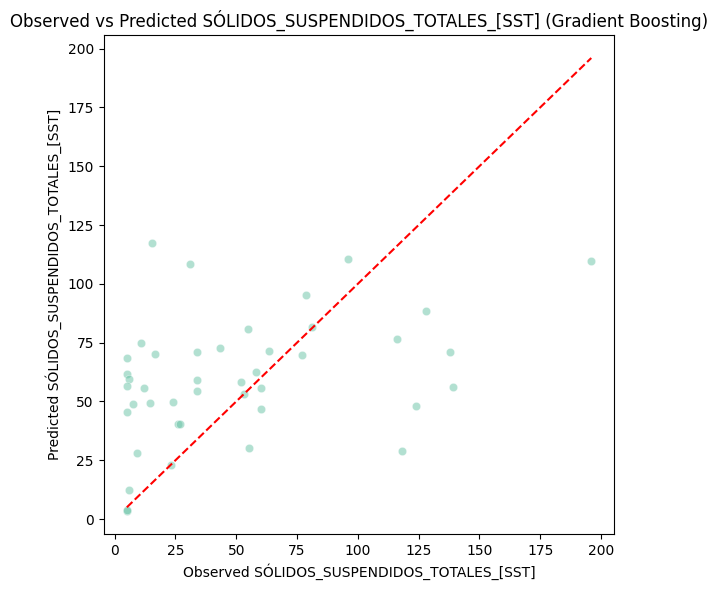

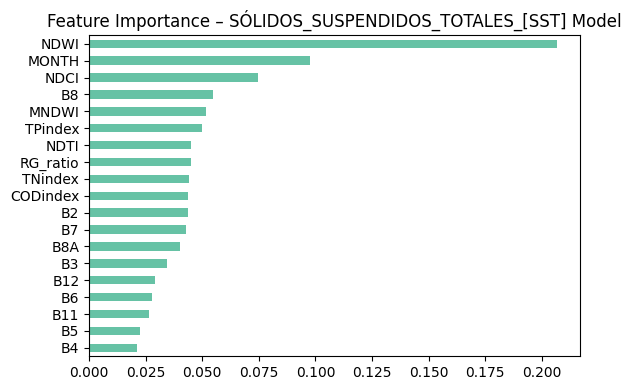

--------------------------------------------------------------------------------
Processing Model NITRÓGENO_TOTAL.....
Samples after log + outlier filter: 686
Stations used: 17
Samples used for model: 686
Train samples: 643
Test samples: 43

--- MODEL PERFORMANCE NITRÓGENO_TOTAL ---
R²    NITRÓGENO_TOTAL: -0.607
RMSE NITRÓGENO_TOTAL: 462.51
MAE  NITRÓGENO_TOTAL: 17.85
NRMSE NITRÓGENO_TOTAL: 8.24


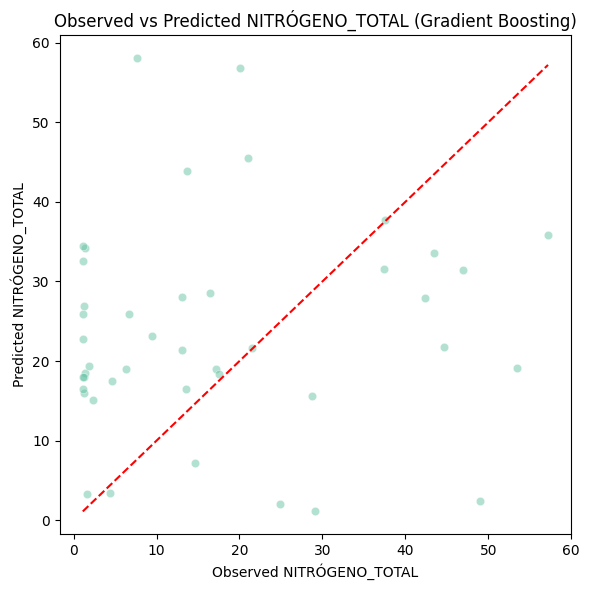

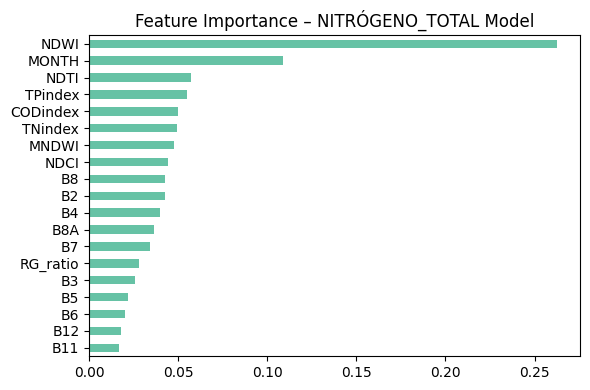

--------------------------------------------------------------------------------
Processing Model FÓSFORO_TOTAL_[P].....
Samples after log + outlier filter: 686
Stations used: 17
Samples used for model: 686
Train samples: 643
Test samples: 43

--- MODEL PERFORMANCE FÓSFORO_TOTAL_[P] ---
R²    FÓSFORO_TOTAL_[P]: -0.101
RMSE FÓSFORO_TOTAL_[P]: 2.12
MAE  FÓSFORO_TOTAL_[P]: 1.19
NRMSE FÓSFORO_TOTAL_[P]: 0.44


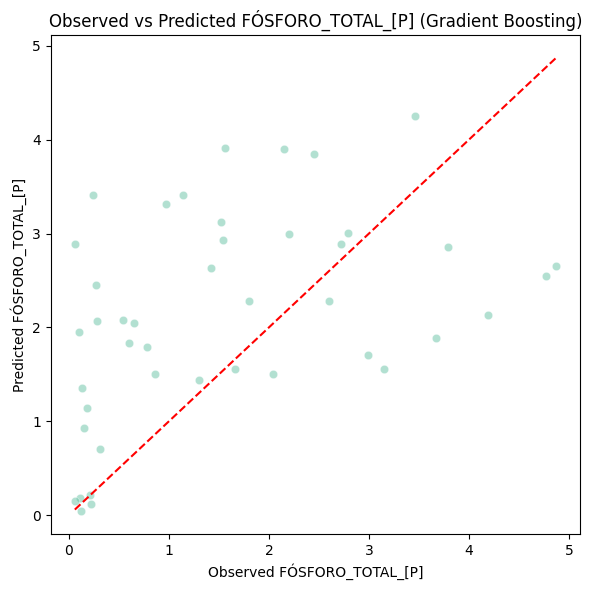

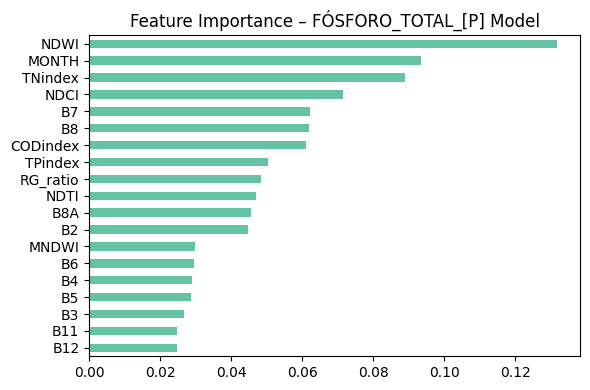

--------------------------------------------------------------------------------
Processing Model DQO_TOTAL.....
Samples after log + outlier filter: 688
Stations used: 17
Samples used for model: 688
Train samples: 645
Test samples: 43

--- MODEL PERFORMANCE DQO_TOTAL ---
R²    DQO_TOTAL: 0.169
RMSE DQO_TOTAL: 9696.97
MAE  DQO_TOTAL: 73.70
NRMSE DQO_TOTAL: 25.63


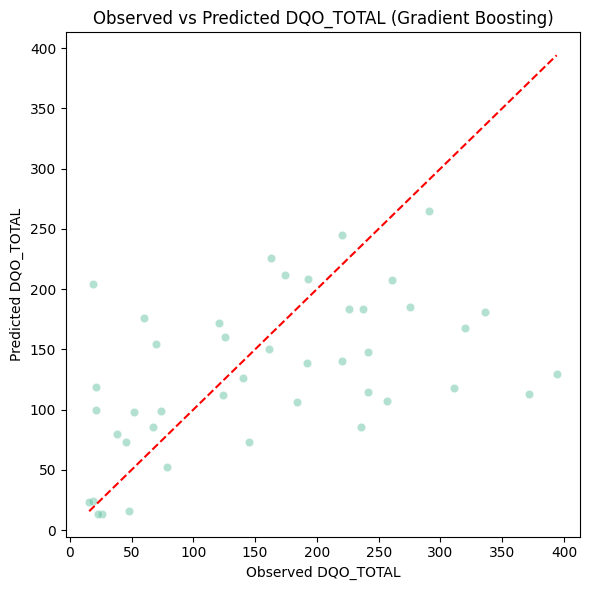

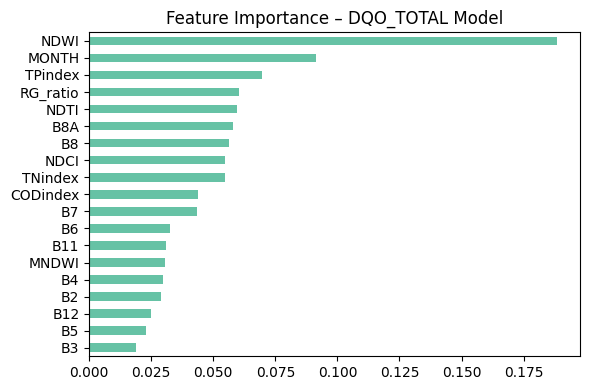

--------------------------------------------------------------------------------


In [273]:

TARGET = ['SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]','NITRÓGENO_TOTAL', 'FÓSFORO_TOTAL_[P]','DQO_TOTAL'] #'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]','NITRÓGENO_TOTAL', 'FÓSFORO_TOTAL_[P]','DQO_TOTAL'
targetrm = {'SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]':'SST', 'NITRÓGENO_TOTAL':'NT', 'FÓSFORO_TOTAL_[P]':'FT','DQO_TOTAL':'DQOT'}
features = [ 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
       'CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex','TPindex',"MONTH"] #,'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM'
year = 2024
df_full_filtered_pred = df_full_filtered.copy()
models = {}
for t in TARGET:
  print("Processing Model "+t+".....")
  # Remove invalid or zero SST values
  df = df_full_filtered_pred[df_full_filtered_pred[t] > 0].copy()
  varlog = t+"_log"
  df[varlog] = np.log1p(df[t])
  # Remove extreme hydrological events (top 1%)
  p99 = df[varlog].quantile(0.99)
  df = df[df[varlog] <= p99]
  print("Samples after log + outlier filter:", len(df))

  valid_stations = ['TU-Regader', 'SA-Carrefo', 'SA-Alameda', 'FU-Boyaca',
       'FU-ZFranca', 'FU-Ferroca', 'TU-MakroS', 'TU-Mexico', 'TU-SBenito',
       'TU-IslaPon', 'TU-PteInde', 'TU-Tv86', 'SA-Tv91', 'FU-Alameda',
       'BO-PComun', 'FU-VisionC', 'TU-DJuana']#['SA-Alameda','FU-Alameda','SA-Tv91','TU-Regader']
  df = df[df["ESTACIONID"].isin(valid_stations)]
  print("Stations used:", len(valid_stations))

  df_ml = df.dropna(subset=features + [varlog])
  print("Samples used for model:", len(df_ml))

  train = df_ml[df_ml["YEAR"] <= year]
  test  = df_ml[df_ml["YEAR"] > year]

  X_train = train[features]
  y_train = train[varlog]

  X_test = test[features]
  y_test_log = test[varlog]
  y_test_real = test[t]

  print("Train samples:", len(train))
  print("Test samples:", len(test))

  gbr = GradientBoostingRegressor(
      n_estimators=400,
      learning_rate=0.05,
      max_depth=4,
      subsample=0.8,
      random_state=42
  )

  gbr.fit(X_train, y_train)
  models[targetrm[t]] = gbr

  # Predict (log space)
  y_pred_log = gbr.predict(X_test)

  # Back-transform to real SST
  y_pred = np.expm1(y_pred_log)

  # 8. Model evaluation (real space)
  rmse = mean_squared_error(y_test_real, y_pred)
  mae  = mean_absolute_error(y_test_real, y_pred)
  r2   = r2_score(y_test_real, y_pred)

  nrmse = rmse / (y_test_real.max() - y_test_real.min())

  print("\n--- MODEL PERFORMANCE "+t+" ---")
  print(f"R²    {t}: {r2:.3f}")
  print(f"RMSE {t}: {rmse:.2f}")
  print(f"MAE  {t}: {mae:.2f}")
  print(f"NRMSE {t}: {nrmse:.2f}")

  #Diagnostic plot: Observed vs Predicted

  plt.figure(figsize=(6,6))
  sns.scatterplot(x=y_test_real, y=y_pred, alpha=0.5)
  plt.plot(
      [y_test_real.min(), y_test_real.max()],
      [y_test_real.min(), y_test_real.max()],
      'r--'
  )
  plt.xlabel("Observed "+t)
  plt.ylabel("Predicted "+t)
  plt.title("Observed vs Predicted "+t+" (Gradient Boosting)")
  plt.tight_layout()
  plt.show()

  #Var importancia
  importance = pd.Series(
      gbr.feature_importances_,
      index=features
  ).sort_values()

  importance.plot(kind="barh", figsize=(6,4))
  plt.title("Feature Importance – "+t+" Model")
  plt.tight_layout()
  plt.show()

  #Predict
  df_full_filtered_pred[targetrm[t]+"_PRED"] = np.nan
  mask_pred = df_full_filtered_pred[features].notna().all(axis=1)

  df_full_filtered_pred.loc[mask_pred, targetrm[t]+"_PRED"] = np.expm1(
      gbr.predict(df_full_filtered_pred.loc[mask_pred, features])
  )
  print("----"*20)




In [274]:
gdf = gpd.GeoDataFrame(
    df_full_filtered_pred,
    geometry=gpd.points_from_xy(df_full_filtered_pred["Longitud_x"], df_full_filtered_pred["Latitud_x"]),
    crs="EPSG:4326"
)

# Convert to EE FeatureCollection
fc = geemap.geopandas_to_ee(gdf, geodesic=False)
vars_to_map = {
    "SST_PRED": "Predicted SST",
    "NT_PRED": "Predicted Nitrogen",
    "FT_PRED": "Predicted Phosphorus",
    "DQOT_PRED": "Predicted COD"
}

palette = ["#2c7bb6", "#abd9e9", "#ffffbf", "#fdae61", "#d7191c"]

Map = geemap.Map(center=[4.65, -74.1], zoom=10 ,basemap="Esri.WorldGrayCanvas")
# Map.add_gdf(bw_btacl, "WaterBody_BTA")

for VAR, label in vars_to_map.items():
    vmin = np.nanpercentile(df_full_filtered_pred[VAR], 5)
    vmax = np.nanpercentile(df_full_filtered_pred[VAR], 95)

    def make_style(varname):
        def _style(f):
            val = ee.Number(f.get(varname))
            t = val.subtract(vmin).divide(vmax - vmin).clamp(0, 1)
            idx = t.multiply(len(palette)-1).round().toInt()
            color = ee.List(palette).get(idx)
            return f.set("style", {"color": color, "pointSize": 6})
        return _style

    fc_var = fc.map(make_style(VAR))

    Map.addLayer(
        fc_var.style(**{"styleProperty": "style"}),
        {},
        label
    )

    Map.add_colorbar(
        vis_params={"min": vmin, "max": vmax, "palette": palette},
        label=label,
        layer_name=f"{label} legend"
    )

Map.addLayerControl()
Map



Map(center=[4.65, -74.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

#### Predict Image

In [275]:
# -----------------------------
YEAR = 2025
start = ee.Date.fromYMD(YEAR, 1, 1)
end = start.advance(1, "year")

# Annual mosaic (median)
areawb = ee.FeatureCollection("users/maikolzaraza07/BodyWater_BTAC2")
img2025 = imagen_zb.filterDate(start, end).median().clip(areawb)
img2025 = img2025.addBands(ee.Image.constant(6).rename("MONTH"))

# Select only features needed by your model
features = [ 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A',
       'CODindex', 'MNDWI', 'NDCI', 'NDTI', 'NDWI', 'RG_ratio', 'TNindex','TPindex',"MONTH"] #,'CAUDAL_PROM', 'PH_PROM', 'TEMP_PROM', 'COND_PROM', 'OD_PROM'

imgX = img2025.select(features)

In [276]:
# Get numpy array: shape (rows, cols, bands)
arr = geemap.ee_to_numpy(imgX, region=areawb, scale=40)
# arr can be None if region too big or memory issue
print(arr.shape)

(773, 479, 19)


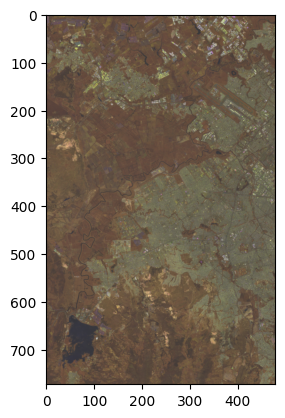

In [277]:
import matplotlib.pyplot as plt

rgb_img_test = (255 * ((arr[:, :, 0:3]) + 0.2)).astype("uint8")
plt.imshow(rgb_img_test)
plt.show()

In [278]:
import numpy as np
import geopandas as gpd
import shapely
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask

def mask_array_with_polygon(arr, outer_gdf, inner_gdf):
    """
    Masks arr (H,W,F) keeping only pixels inside inner polygon.
    Uses bounds of outer_gdf to build the pixel->geo transform.
    """
    H, W, F = arr.shape

    outer_gdf = outer_gdf.to_crs("EPSG:4326")
    inner_gdf = inner_gdf.to_crs("EPSG:4326")

    # Use bounds of OUTER polygon (the one used to request arr)
    minx, miny, maxx, maxy = outer_gdf.total_bounds
    transform = from_bounds(minx, miny, maxx, maxy, W, H)

    # Mask outside INNER polygon (True = outside)
    inner_geoms = [geom for geom in inner_gdf.geometry if geom is not None]
    mask_outside = geometry_mask(
        geometries=inner_geoms,
        out_shape=(H, W),
        transform=transform,
        invert=False   # False => True outside
    )

    arr_masked = arr.copy()
    arr_masked[mask_outside] = np.nan
    return arr_masked, transform

def predict_from_arr(arr_masked, model, log_target=True):
    """
    Predict per-pixel for masked array (NaN outside). Returns pred raster (H,W).
    """
    H, W, F = arr_masked.shape
    X = arr_masked.reshape(-1, F)
    valid = np.isfinite(X).all(axis=1)

    y = np.full((X.shape[0],), np.nan, dtype="float32")
    if valid.sum() == 0:
        return y.reshape(H, W)

    yhat = model.predict(X[valid])

    if log_target:
        yhat = np.expm1(yhat)

    y[valid] = yhat.astype("float32")
    return y.reshape(H, W)

areawbg = geemap.ee_to_gdf(areawb)
arr_masked, transform = mask_array_with_polygon(arr, outer_gdf=areawbg, inner_gdf=areawbg)

pred_sst = predict_from_arr(arr_masked, models['SST'], log_target=True)
pred_dqo = predict_from_arr(arr_masked, models['DQOT'], log_target=True)
pred_nt = predict_from_arr(arr_masked, models['NT'], log_target=True)
pred_pt = predict_from_arr(arr_masked, models['FT'], log_target=True)



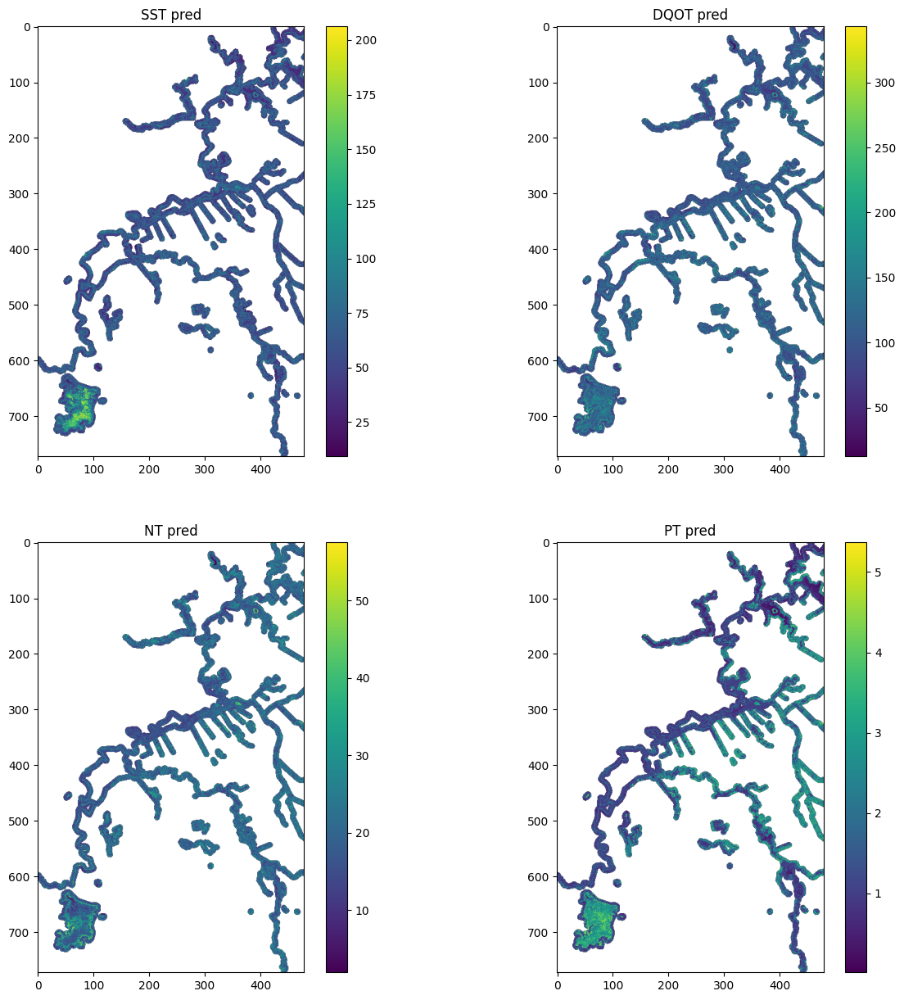

<Figure size 640x480 with 0 Axes>

In [279]:
plt.figure(figsize=(15,15));
plt.subplot(2,2,1)
plt.imshow(pred_sst);
plt.title("SST pred");
plt.colorbar();
plt.savefig(output_path+"/pred_sst_img.png")

plt.subplot(2,2,2)
plt.imshow(pred_dqo);
plt.title("DQOT pred");
plt.colorbar();
plt.savefig(output_path+"/pred_dqo_img.png")

plt.subplot(2,2,3)
plt.imshow(pred_nt);
plt.title("NT pred");
plt.colorbar();
plt.savefig(output_path+"/pred_nt_img.png")

plt.subplot(2,2,4)
plt.imshow(pred_pt);
plt.title("PT pred");
plt.colorbar(); plt.show()
plt.savefig(output_path+"/pred_pt_img.png")

### Analysis Hotspots


In [280]:


MATCHUPS_CSV = output_path+"/matchups_field_sentinel2_filled.csv"
BUFFER_M     = 1000

# -----------------------------
# OUTPUTS
# -----------------------------
OUT_LULC_PROPS = output_path+"/outputs_station_lulc_props.csv"
OUT_RANK       = output_path+"/hotspot_ranking_final_observed.csv"
OUT_HOTS       = output_path+"/hotspot_stations_observed.csv"


df = pd.read_csv(MATCHUPS_CSV)
df["YEAR"] = pd.to_datetime(df["FECHA"]).dt.year
df["t_num"] = pd.to_datetime(df["FECHA"]).map(pd.Timestamp.toordinal)

# Observed variables
OBS_VARS = {
    "SST": "SÓLIDOS_SUSPENDIDOS_TOTALES_[SST]",
    "DQO": "DQO_TOTAL",
    "NT":  "NITRÓGENO_TOTAL",
    "PT":  "FÓSFORO_TOTAL_[P]"
}

# Station points
stations_xy = (
    df[["ESTACIONID", "Latitud_x", "Longitud_x"]]
    .drop_duplicates("ESTACIONID")
    .dropna(subset=["Latitud_x", "Longitud_x"])
    .copy()
)

gdf_st = gpd.GeoDataFrame(
    stations_xy,
    geometry=gpd.points_from_xy(stations_xy["Longitud_x"], stations_xy["Latitud_x"]),
    crs="EPSG:4326"
)

clc = gdf_clcar
print("CLC columns:", list(clc.columns))

# Compute land-cover proportions within station buffers
#    - Project to metric CRS for buffers/areas (EPSG:3116 Colombia MAGNA-SIRGAS / Bogotá zone)
# Use a metric CRS suitable for Bogotá:
metric_crs = "EPSG:3116"

gdf_st_m = gdf_st.to_crs(metric_crs)
clc_m = clc.to_crs(metric_crs)

# Build buffers
gdf_buf = gdf_st_m.copy()
gdf_buf["geometry"] = gdf_buf.geometry.buffer(BUFFER_M)

# Overlay: intersection of buffers with CLC polygons
# Keep only relevant columns
clc_m2 = clc_m[["CLC_CLASS", "geometry"]].copy()

inter = gpd.overlay(
    gdf_buf[["ESTACIONID", "geometry"]],
    clc_m2,
    how="intersection"
)

# Compute areas
inter["area_m2"] = inter.geometry.area

# Total buffer area per station
tot_area = inter.groupby("ESTACIONID")["area_m2"].sum().rename("buffer_area_m2").reset_index()

# Area per class per station
area_class = (
    inter.groupby(["ESTACIONID", "CLC_CLASS"])["area_m2"]
         .sum()
         .reset_index()
)

# Convert to proportions
area_class = area_class.merge(tot_area, on="ESTACIONID", how="left")
area_class["prop"] = area_class["area_m2"] / area_class["buffer_area_m2"]

# Pivot to wide format: one row per station, columns = classes
lulc_props = area_class.pivot(index="ESTACIONID", columns="CLC_CLASS", values="prop").fillna(0).reset_index()

# Anthropogenic pressure
lulc_props["ANTHRO_PRESSURE"] = round((lulc_props["Urban"] + lulc_props["Industrial"] + lulc_props["Crops"] + lulc_props["Mining"])*100,2)

lulc_props.to_csv(OUT_LULC_PROPS, index=False)
print("\nSaved land-cover proportions:", OUT_LULC_PROPS)

CLC columns: ['codigo', 'leyenda', 'insumo', 'apoyo', 'confiabili', 'cambio', 'nivel_1', 'nivel_2', 'nivel_3', 'nivel_4', 'nivel_5', 'nivel_6', 'area_ha', 'Shape_Leng', 'Shape_Area', 'geometry', 'CLC_CLASS', 'area']

Saved land-cover proportions: /content/drive/MyDrive/G4/output/outputs_station_lulc_props.csv


In [281]:
df_joined_lulc = lulc_props.merge(
    df_stations,
    on="ESTACIONID",
    how="left"
)
df_joined_lulc
gdf_lulc = gpd.GeoDataFrame(df_joined_lulc,
                       geometry=gpd.GeoSeries.from_xy(df_joined_lulc['Longitud'], df_joined_lulc['Latitud']),
                       crs="EPSG:4326")

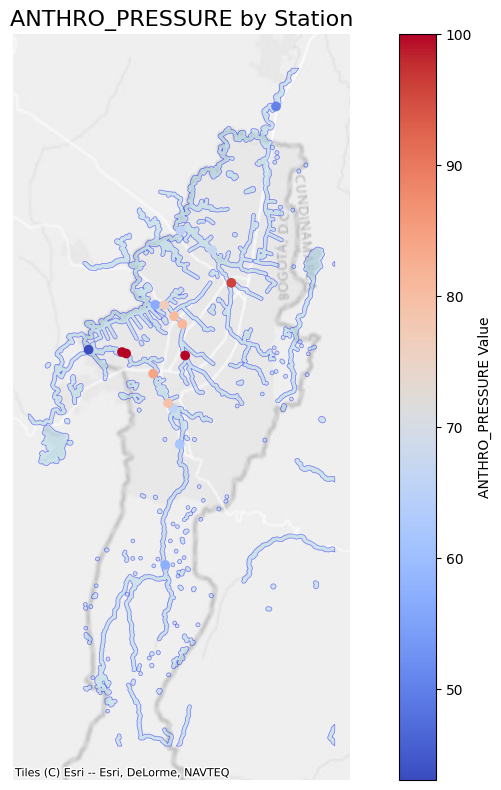

<Figure size 640x480 with 0 Axes>

In [282]:
lulc_props.sort_values("ANTHRO_PRESSURE", ascending=False)

# Plotting the GeoDataFrame with the selected variable (ANTHRO_PRESSURE)
fig, ax = plt.subplots(figsize=(10, 8))

#shapefile
bw_btacl.plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', linewidth=0.5)

# clc.to_crs('EPSG:4326').plot(ax=ax, color='lightblue', alpha=0.5, edgecolor='blue', linewidth=0.5)

# Plot stations with color based on ANTHRO_PRESSURE values
gdf_lulc.plot(column="ANTHRO_PRESSURE",
         ax=ax,
         legend=True,
         cmap="coolwarm",
         legend_kwds={'label': "ANTHRO_PRESSURE Value",
                      'orientation': "vertical"})

# Add basemap
cx.add_basemap(ax,
               crs=bw_btacl.crs,
               source=cx.providers.Esri.WorldGrayCanvas)

# Remove axis labels and ticks
ax.set_axis_off()

# Add title
ax.set_title("ANTHRO_PRESSURE by Station", fontsize=16)

# Display the plot with the basemap and color scale
plt.tight_layout()
plt.show()
plt.savefig(output_path+"/ANTHRO_PRESSURE_by_Station.png")

#### Calculate Index Hotspots

Process to Calculate Index Hotspots

![](images/hotspots_process.png)

In [283]:
# Station- levels (observed) - use median

pollution_station = (
    df.groupby("ESTACIONID")[list(OBS_VARS.values())]
      .median()
      .reset_index()
      .rename(columns={v: f"{k}_MED" for k, v in OBS_VARS.items()})
)

# Theil–Sen trends per station for each observed variable
#    - Worsening = slope > 0 (increasing concentrations)
MIN_POINTS = 5
trend_rows = []

for st, g in df.groupby("ESTACIONID"):
    row = {"ESTACIONID": st}

    for key, col in OBS_VARS.items():
        sub = g[["t_num", col]].dropna()
        if len(sub) < MIN_POINTS:
            row[f"{key}_SLOPE_TS"] = np.nan
            continue
        slope, intercept, lo, hi = theilslopes(sub[col].values, sub["t_num"].values)
        row[f"{key}_SLOPE_TS"] = slope

    trend_rows.append(row)

trend_station = pd.DataFrame(trend_rows)
for key in OBS_VARS.keys():
    trend_station[f"{key}_SLOPE_POS"] = trend_station[f"{key}_SLOPE_TS"].clip(lower=0)

#Merge into hotspot table
hot = (
    pollution_station
    .merge(trend_station, on="ESTACIONID", how="left")
    .merge(lulc_props[["ESTACIONID", "ANTHRO_PRESSURE"]], on="ESTACIONID", how="left")
)


# Robust normalization (percentile min-max)
def robust_minmax(s, pmin=5, pmax=95):
    s = s.astype(float)
    if s.dropna().empty:
        return s * np.nan
    lo, hi = np.nanpercentile(s, [pmin, pmax])
    if np.isclose(hi, lo):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return ((s - lo) / (hi - lo)).clip(0, 1)

# Normalize pollution medians and trend slopes
for key in OBS_VARS.keys():
    hot[f"{key}_MED_N"] = robust_minmax(hot[f"{key}_MED"])
    hot[f"{key}_TREND_N"] = robust_minmax(hot[f"{key}_SLOPE_POS"])

hot["POLLUTION_N"] = hot[[f"{k}_MED_N" for k in OBS_VARS.keys()]].mean(axis=1)
hot["TREND_N"]     = hot[[f"{k}_TREND_N" for k in OBS_VARS.keys()]].mean(axis=1)
hot["LULC_N"]      = robust_minmax(hot["ANTHRO_PRESSURE"])


# 9) Hotspot Index (weights)

W_POLL, W_TREND, W_LULC = 0.50, 0.30, 0.20

hot["HOTSPOT_INDEX"] = (
    W_POLL * hot["POLLUTION_N"] +
    W_TREND * hot["TREND_N"] +
    W_LULC * hot["LULC_N"]
)

hot["HOTSPOT_CLASS"] = pd.qcut(
    hot["HOTSPOT_INDEX"],
    q=[0, 0.6, 0.8, 1.0],
    labels=["Low", "Medium", "High"]
)

hot_rank = hot.sort_values("HOTSPOT_INDEX", ascending=False).reset_index(drop=True)
hot_rank.to_csv(OUT_RANK, index=False)
print("Saved hotspot ranking:", OUT_RANK)

gdf_hot = gdf_st.merge(
    hot_rank[["ESTACIONID", "HOTSPOT_INDEX", "HOTSPOT_CLASS", "POLLUTION_N", "TREND_N", "LULC_N"]],
    on="ESTACIONID",
    how="left"
)

gdf_hot.to_csv(OUT_HOTS, index=False)
print("Saved stations:", OUT_HOTS)

Saved hotspot ranking: /content/drive/MyDrive/G4/output/hotspot_ranking_final_observed.csv
Saved stations: /content/drive/MyDrive/G4/output/hotspot_stations_observed.csv


In [284]:
import shapely
from shapely.geometry import Polygon, MultiPolygon, shape, mapping
def to_2d(geom):
    if geom is None:
        return None
    try:
        return shapely.force_2d(geom)  # Shapely >= 2.0
    except Exception:
        # fallback for older shapely (should not happen in colab)
        return shape(mapping(geom))

clc["geometry"] = clc["geometry"].apply(to_2d)
clc.to_crs("EPSG:4326", inplace=True)

# Dissolve and simplify for faster plotting
clc_diss = clc.dissolve(by="CLC_CLASS", as_index=False)
SIMPLIFY_TOL = 0.0002   # adjust if needed
clc_diss["geometry"] = clc_diss["geometry"].simplify(SIMPLIFY_TOL, preserve_topology=True)

In [285]:

# Load hotspot stations output
# -----------------------------
gdf_hot = gdf_hot

# Convert to EE FeatureCollection
fc = geemap.geopandas_to_ee(gdf_hot, geodesic=False)

# Style by hotspot class
# -----------------------------
class_palette = {"Low": "#FFFFFF", "Medium": "#0000ff", "High": "#000000"}  # green, yellow, red

def style_by_class(f):
    cls = ee.String(f.get("HOTSPOT_CLASS"))
    color = ee.Dictionary(class_palette).get(cls, "#969696")  # gray default
    return f.set("style", {"color": color, "pointSize": 8, "width": 1})

fc_styled = fc.map(style_by_class)

fc_clc = geemap.geopandas_to_ee(clc_diss.to_crs('EPSG:4326'), geodesic=False)
clc_palette = {
    "Urban": "#d73027",
    "Industrial": "#7f0000",
    "Crops": "#fee08b",
    "Vegetation": "#1a9850",
    "Soils": "#d9a066",
    "Mining": "#8c510a",
    "Wetlands": "#66c2a5",
    "Water": "#4255fe",
    "Other": "#bdbdbd",
}

def style_clc(f):
    cls = ee.String(f.get("CLC_CLASS"))
    color = ee.Dictionary(clc_palette).get(cls, "#bdbdbd")
    return f.set("style", {"color": color, "fillColor": color, "width": 0.5, "fillOpacity": 0.45})

clc_styled = fc_clc.map(style_clc)

# -----------------------------
# Build interactive map
# -----------------------------
Map = geemap.Map(center=[4.65, -74.1], zoom=10,basemap="Esri.WorldImagery")
Map.addLayer(imagen_zb.median().clip(areasc),TrueColorVis, "Mosaico")
Map.addLayer(clc_styled.style(**{"styleProperty": "style"}), {}, "CLC 2022 (reclassified)")
Map.addLayer(fc_styled.style(**{"styleProperty": "style"}), {}, "Hotspots (Low/Medium/High)")


Map.add_legend(title="CLC class", legend_dict=clc_palette)
Map.add_legend(
    title="Hotspot class",
    legend_dict={
        "Low": class_palette["Low"],
        "Medium": class_palette["Medium"],
        "High": class_palette["High"]
    }
)

Map.addLayerControl()
Map

Map(center=[4.65, -74.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## **5. FINAL REFLECTIONS**
---


###**Summary of the results**
This project assessed Bogotá’s surface water quality (2019–2025) by integrating RCHB/OAB in-situ monitoring with Sentinel-2. The analysis focused on SST (TSS), DQO, Total N and Total P, mapping annual medians, evaluating trends (Theil–Sen), and identifying hotspots linked to land-use pressure.

Main findings:

*   Water quality shows strong spatial concentration of impacts: the Fucha River and Tunjuelo River corridors present the most recurrent high values (especially SST and DQO), while less urbanized zones tend to be more stable.

*   Spatial outputs (annual maps, hotspot maps) reveal localized clusters of degradation that are not obvious in citywide summaries.

*   Stations with higher urban/industrial land-cover influence generally exhibit higher median SST/DQO and stronger worsening trends, supporting the land-use pressure hypothesis.

###**Difficulties encountered (technical, data, etc)**
Several challenges were encountered throughout the project:

*   Irregular temporal sampling of the RCHB/OAB network complicated the generation of time-regular composites and trend analysis
*   Scale mismatch and mixed pixels (narrow rivers vs Sentinel-2 10–20 m pixels) reduced valid matchups and weakened satellite–field relationships, led to discrepancies in the correlation analysis, requiring careful data cleaning and interpolation

*   Strong filtering was needed: from 31 stations to 18 usable, and from ~5,395 measurements (2006–2025) to 693 (after outlier removal + valid Sentinel matchups).

ML models had low predictive accuracy, especially for nutrients (NT/PT), consistent with indirect optical sensitivity and mixed pixels: SST (R²≈0.12), DQO (R²≈0.21), NT/PT poor (negative/low R²).

###  **Take-away message**
For water-management stakeholders in Bogotá, the results provide clear, spatially explicit evidence of where land-use pressures (urbanization and industrial activity) are most strongly associated with water-quality degradation. The main value of the workflow is spatial prioritization: it identifies persistent and worsening hotspots, enabling more targeted monitoring, enforcement, and restoration actions aligned with SDG 6 and SDG 11.

This also demonstrates the practical benefit of integrating satellite and in-situ data to support more efficient policy decisions in urban water systems. At the same time, Sentinel-2 is most reliable for detecting relative patterns in optically active indicators (e.g., SST) rather than precise concentrations in narrow channels affected by mixed pixels. Strengthening field sampling frequency and positioning stations in wider, representative water pixels would substantially improve satellite integration and future predictive performance, supporting proactive, data-driven water-quality management and urban resilience.

---
## **6. REFERENCES**
---

- Peng, C., Xie, Z., & Jin, X. (2024). Using Ensemble Learning for Remote Sensing Inversion of Water Quality Parameters in Poyang Lake. Sustainability 2024, Vol. 16, Page 3355, 16(8), 3355. https://doi.org/10.3390/su16083355

- Yang, F., Feng, Q., Zhou, Y., Li, W., Zhang, X., & He, B. (2024). Monitoring Total Phosphorus Concentration in the Middle Reaches of the Yangtze River Using Sentinel-2 Satellites. Remote Sensing 2024, Vol. 16, Page 1491, 16(9), 1491. https://doi.org/10.3390/rs16091491

- Khan, R. M., Salehi, B., Mahdianpari, M., & Mohammadimanesh, F. (2021). WATER QUALITY MONITORING OVER FINGER LAKES REGION USING SENTINEL-2 IMAGERY ON GOOGLE EARTH ENGINE CLOUD COMPUTING PLATFORM. ISPRS Annals of the Photogrammetry, Remote Sensing and Spatial Information Sciences, V-3–2021(3), 279–283. https://doi.org/10.5194/isprs-annals-V-3-2021-279-2021

- RCHB: https://lookerstudio.google.com/embed/u/0/reporting/df8ca59f-ddfe-48cf-bf75-08688c7b365e/page/p_kfq0svv96c

- Sentinel-2 GEE: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED?hl=es-419